<a href="https://colab.research.google.com/github/dianakorka/statistical_capacity/blob/main/WTI_capacity_index_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import geopandas as gpd
import plotly.express as px
import re
!pip install adjustText
from adjustText import adjust_text

## Reading and transforming data

2 excel files needed:
* latest data (WTI availability), 3 sheets,
* and the country groupings from Household_data_availability.



In [2]:
file_path = '/content/WTI_availability_20260803.xlsx'
dfs = pd.read_excel(file_path, sheet_name=None)

for name, df in dfs.items():
    print(f"Sheet: {name}, Shape: {df.shape}")

Sheet: WTIData_2020-2025, Shape: (14376, 4)
Sheet: Codes, Shape: (15, 4)
Sheet: MaxYear_by_country-indicator, Shape: (196, 17)
Sheet: query, Shape: (0, 0)


In [3]:
file_path = '/content/WTI_availability_20260803.xlsx'

wti_codes = pd.read_excel(file_path, sheet_name='MaxYear_by_country-indicator', skiprows=[0])

# all we want from this data sheet is the ISO codes
wti_codes[['iso_code', 'short_name']].head()

,iso_code,short_name
0,AFG,Afghanistan
1,AGO,Angola
2,ALB,Albania
3,AND,Andorra
4,ARE,United Arab Emirates


In [4]:
# number of unique countries covered in this file
wti_codes.iso_code.nunique()

195

In [5]:
file_path = '/content/WTI_availability_20260803.xlsx'

wti = pd.read_excel(file_path, sheet_name='WTIData_2020-2025')

#wti = wti.iloc[:, :-2]


In [6]:
# this is the actual data we need for calculations

wti.head()

,region_name,short_name,code,data_year
0,Asia & Pacific,Afghanistan,i112,2020
1,Asia & Pacific,Afghanistan,i135tfb,2020
2,Asia & Pacific,Afghanistan,i136mwi,2020
3,Asia & Pacific,Afghanistan,i271,2020
4,Asia & Pacific,Afghanistan,i271G,2020


In [7]:
wti.shape

(14376, 4)

In [8]:
wti[(wti.short_name == 'Kuwait') & (wti.code == 'i135tfb')]

,region_name,short_name,code,data_year
6909,Arab States,Kuwait,i135tfb,2020
6924,Arab States,Kuwait,i135tfb,2021
6941,Arab States,Kuwait,i135tfb,2022
6958,Arab States,Kuwait,i135tfb,2023
6974,Arab States,Kuwait,i135tfb,2024
6975,Arab States,Kuwait,i135tfb,2024
7001,Arab States,Kuwait,i135tfb,2025
7002,Arab States,Kuwait,i135tfb,2025


In [9]:
# unfortunately this dataset contains duplicates, which we clean below
wti.drop_duplicates(inplace=True)

In [10]:
wti.shape

(14346, 4)

In [11]:
# list of unique countries covered by the data file
wti.short_name.nunique()

197

In [12]:
# list of indicators covered by the data file

wti.code.unique()

array(['i112', 'i135tfb', 'i136mwi', 'i271', 'i271G', 'i271GA', 'i271mw',
       'i271pop', 'i4213_256to2', 'i4213_2to10', 'i4213_G10', 'i4213tfbb',
       'i4214l', 'i4214u', 'i271G5_pop', 'i271mwa', 'i271mw_5G'],
      dtype=object)

Add in country groupings from a different excel file

In [13]:
file_path = '/content/Household_data_availability_Apr2025.xlsx'
wti_countries = pd.read_excel(file_path, sheet_name='Country definition')
wti_countries[['ShortName', 'LDC', 'LLDC', 'SIDS', 'WB_Income', 'OECD_member']].head()

,ShortName,LDC,LLDC,SIDS,WB_Income,OECD_member
0,Afghanistan,LDC,LLDC,NaN,Low income,NaN
1,Albania,NaN,NaN,NaN,Upper middle income,NaN
2,Algeria,NaN,NaN,NaN,Lower middle income,NaN
3,American Samoa,NaN,NaN,SIDS,Upper middle income,NaN
4,Andorra,NaN,NaN,NaN,High income,NaN


In [14]:
# regrouping of countries
def assign_group(row):
    if row['OECD_member'] == 1:
        return 'Developed-OECD'
    elif (row['SIDS'] == 'SIDS') or (row['LDC'] == 'LDC'):
    #or (row['lldc'] == 'LLDC'):
        return 'SIDS + LDC'
    else:
        return 'Other developing and transition'

wti_countries['new_group'] = wti_countries.apply(assign_group, axis=1)

wti_countries[['ShortName', 'LDC', 'LLDC', 'SIDS', 'WB_Income', 'OECD_member', 'new_group', 'CountryType']].head()

,ShortName,LDC,LLDC,SIDS,WB_Income,OECD_member,new_group,CountryType
0,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
1,Albania,NaN,NaN,NaN,Upper middle income,NaN,Other developing and transition,Developed
2,Algeria,NaN,NaN,NaN,Lower middle income,NaN,Other developing and transition,Developing
3,American Samoa,NaN,NaN,SIDS,Upper middle income,NaN,SIDS + LDC,Developing
4,Andorra,NaN,NaN,NaN,High income,NaN,Other developing and transition,Developed


In [15]:
# so we get an idea how many countries are counted in which group -- this is for country name, not for the available data
wti_countries.new_group.value_counts()

,count
new_group,
Other developing and transition,110
SIDS + LDC,88
Developed-OECD,38


In [16]:
wti_countries.CountryType.value_counts()

,count
CountryType,
Developing,172
Developed,60


In [17]:
wti_countries.WB_Income.value_counts()

,count
WB_Income,
High income,79
Upper middle income,54
Lower middle income,54
Low income,28


## Grouping for WTI indicators

The next part gives us WTI indicators, their names and we construct their categories

In [18]:
# get indicator definitions
file_path = '/content/WTI_availability_20260803.xlsx'
def_wti = pd.read_excel(file_path, sheet_name='Codes')
def_wti.dropna(subset=['Code'], inplace=True)

In [19]:
def_wti = def_wti.drop_duplicates(subset=['Code'])

In [20]:

def_wti.sort_values(by='Code', inplace=True)
def_wti.reset_index(drop=True, inplace=True)

In [21]:
def_wti.head()

,Code,CodeDesc,Definition,"""Core list"" number"
0,i112,Fixed-telephone subscriptions,Fixed-telephone subscriptions refers to the su...,A1
1,i135tfb,Fixed-broadband Internet traffic (exabytes),Fixed (wired)- broadband Internet traffic (exa...,NaN
2,i136mwi,Mobile-broadband Internet traffic (within the ...,Mobile-broadband Internet traffic (within the ...,NaN
3,i271,"Mobile-cellular telephone subscriptions, by po...",Mobile-cellular telephone subscriptions refers...,A2
4,i271G,Percentage of the population covered by at lea...,Percentage of the population covered by at lea...,A6


Here we define the WTI_group categories by data source which we will use later for more aggregate reporting

In [22]:
codes_A = ["i112", "i271", "i271mw", "i4213tfbb"]
codes_B = ["i271G", "i271G5_pop", "i271GA"]
codes_C = ["i135tfb", "i136mwi"]
codes_D = ["i4214l", "i4214u"]
codes_E = ["i4213_256to2", "i4213_2to10", "i4213_G10"]

def_wti["wti_group"] = np.select(
    [
        def_wti["Code"].isin(codes_A),
        def_wti["Code"].isin(codes_B),
        def_wti["Code"].isin(codes_C),
        def_wti["Code"].isin(codes_D),
        def_wti["Code"].isin(codes_E)
    ],
    [
        "A. Contracting_records",
        "B. Cell_tower_coverage",
        "C. Operator_traffic",
        "D. Operators_wholesale",
        "E. Contracting_fixed_broadband_speed"
    ],
    default="Other"
)

In [23]:
# here is the indicator grouping
def_wti[["Code", "CodeDesc", "wti_group"]].sort_values(by="wti_group").reset_index()

,index,Code,CodeDesc,wti_group
0,0,i112,Fixed-telephone subscriptions,A. Contracting_records
1,3,i271,"Mobile-cellular telephone subscriptions, by po...",A. Contracting_records
2,7,i271mw,Active mobile-broadband subscriptions,A. Contracting_records
3,12,i4213tfbb,Fixed-broadband subscriptions,A. Contracting_records
4,4,i271G,Percentage of the population covered by at lea...,B. Cell_tower_coverage
5,5,i271G5_pop,Percentage of the population covered by at lea...,B. Cell_tower_coverage
6,6,i271GA,Percentage of the population covered by at lea...,B. Cell_tower_coverage
7,1,i135tfb,Fixed-broadband Internet traffic (exabytes),C. Operator_traffic
8,2,i136mwi,Mobile-broadband Internet traffic (within the ...,C. Operator_traffic
9,13,i4214l,"Lit/equipped international bandwidth capacity,...",D. Operators_wholesale


In [24]:
# drop "Other"
def_wti.drop(def_wti[def_wti.wti_group == 'Other'].index, inplace=True)

In [25]:
# adding the new grouping to the existing data file
wti = wti.merge(def_wti[["Code", "CodeDesc", "wti_group"]], left_on="code", right_on="Code", how="left")

In [26]:
wti['data_year'] = wti['data_year'].astype('Int64')

In [27]:
wti.shape

(14346, 7)

In [28]:
# add the iso code
wti = wti.merge(wti_codes[['iso_code', 'short_name']], on="short_name", how="left")

In [29]:
wti.shape

(14346, 8)

In [30]:
# add other country groups
wti = wti.merge(wti_countries[['ShortName', 'LDC', 'LLDC', 'SIDS', 'WB_Income', 'OECD_member', 'new_group', 'CountryType']], left_on="short_name", right_on="ShortName", how="left")
wti.shape

(14346, 16)

In [31]:
wti.columns

Index(['region_name', 'short_name', 'code', 'data_year', 'Code', 'CodeDesc',
       'wti_group', 'iso_code', 'ShortName', 'LDC', 'LLDC', 'SIDS',
       'WB_Income', 'OECD_member', 'new_group', 'CountryType'],
      dtype='object')

In [32]:
# and cleaning up duplicate columns

wti = wti.drop(columns=['short_name', 'code'])

In [33]:
# and renaming some columns to match the code below

wti = wti.rename(columns={'region': 'region_name', 'data_year': 'DataYear', 'iso_code': 'IsoCode'})

In [34]:
# drop any lines of data that do not correspond to the list of indicatorsdefined above
wti.dropna(subset = ['Code'], inplace=True)

In [35]:
# Example of data by country
wti[wti.ShortName == 'Mali']

,region_name,DataYear,Code,CodeDesc,wti_group,IsoCode,ShortName,LDC,LLDC,SIDS,WB_Income,OECD_member,new_group,CountryType
8022,Africa,2020,i112,Fixed-telephone subscriptions,A. Contracting_records,MLI,Mali,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
8023,Africa,2020,i271,"Mobile-cellular telephone subscriptions, by po...",A. Contracting_records,MLI,Mali,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
8024,Africa,2020,i271G,Percentage of the population covered by at lea...,B. Cell_tower_coverage,MLI,Mali,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
8025,Africa,2020,i271G5_pop,Percentage of the population covered by at lea...,B. Cell_tower_coverage,MLI,Mali,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
8026,Africa,2020,i271GA,Percentage of the population covered by at lea...,B. Cell_tower_coverage,MLI,Mali,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
8027,Africa,2020,i271mw,Active mobile-broadband subscriptions,A. Contracting_records,MLI,Mali,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
8031,Africa,2020,i4213_256to2,"Fixed broadband, 256 kbit/s to less than 2 Mbi...",E. Contracting_fixed_broadband_speed,MLI,Mali,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
8032,Africa,2020,i4213_2to10,"Fixed broadband, 2 Mbit/s to less than 10 Mbit...",E. Contracting_fixed_broadband_speed,MLI,Mali,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
8033,Africa,2020,i4213_G10,"Fixed broadband, equal to or above 10 Mbit/s s...",E. Contracting_fixed_broadband_speed,MLI,Mali,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
8034,Africa,2020,i4213tfbb,Fixed-broadband subscriptions,A. Contracting_records,MLI,Mali,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing


In [36]:
wti.DataYear.describe()

,DataYear
count,12309.0
mean,2022.4136
std,1.673392
min,2020.0
25%,2021.0
50%,2022.0
75%,2024.0
max,2025.0


## Barcode plot for the country profile

Detailed plot for ONE COUNTRY ONLY: data points per year and indicator.

In [37]:
# prepping my data to draw a barcode plot

years = [2021, 2022, 2023, 2024, 2025]

codes = ['i112', 'i271', 'i271mw', 'i4213tfbb', 'i271G' , 'i271G5_pop', 'i271GA', 'i136mwi',  'i135tfb','i4214l',
       'i4214u', 'i4213_256to2', 'i4213_2to10', 'i4213_G10']

new_names = ['A.i112', 'A.i271', 'A.i271mw', 'A.i4213tfbb', 'B.i271G' , 'B.i271G5_pop', 'B.i271GA', 'C.i136mwi',  'C.i135tfb','D.i4214l',
       'D.i4214u', 'E.i4213_256to2', 'E.i4213_2to10', 'E.i4213_G10']

wti_country = wti[(wti.ShortName == 'Sierra Leone')].pivot(index='Code', columns='DataYear', values = 'ShortName').reindex(columns=years, index=codes).notna().astype(int).reset_index()

wti_country.Code=new_names

wti_country

DataYear,Code,2021,2022,2023,2024,2025
0,A.i112,1,0,0,0,0
1,A.i271,1,0,0,0,0
2,A.i271mw,1,0,0,0,0
3,A.i4213tfbb,1,0,0,0,0
4,B.i271G,1,0,0,0,0
5,B.i271G5_pop,1,0,0,0,0
6,B.i271GA,1,0,0,0,0
7,C.i136mwi,0,0,0,0,0
8,C.i135tfb,0,0,0,0,0
9,D.i4214l,1,0,0,0,0


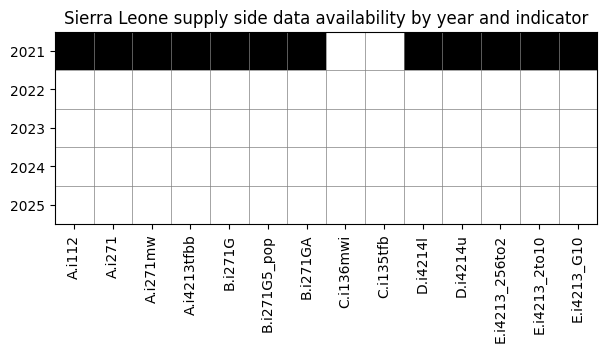

In [38]:
# Convert DataFrame to numpy array
code_array = wti_country.set_index( 'Code').T.to_numpy()

fig, ax = plt.subplots(figsize=(code_array.shape[1] * 0.5, code_array.shape[0] * 0.5))

# Show barcode
ax.imshow(code_array, cmap='binary', aspect='auto', interpolation='nearest')

# Set row labels (y-axis)
ax.set_yticks(np.arange(code_array.shape[0]))
ax.set_yticklabels(wti_country.set_index( 'Code').T.index)

# Set column labels (x-axis)
ax.set_xticks(np.arange(code_array.shape[1]))
ax.set_xticklabels(wti_country.set_index( 'Code').T.columns, rotation=90)

ax.set_title('Sierra Leone supply side data availability by year and indicator')

# Optional: remove grid / frame
ax.set_xticks(np.arange(-.5, code_array.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, code_array.shape[0], 1), minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
ax.tick_params(which='minor', bottom=False, left=False)

plt.show()

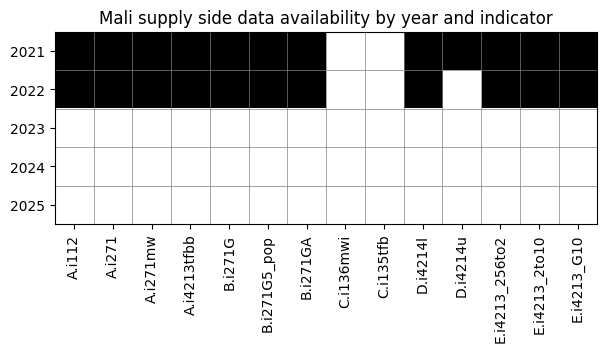

In [39]:
# prepping my data to draw a barcode plot

years = [2021, 2022, 2023, 2024, 2025]

codes = ['i112', 'i271', 'i271mw', 'i4213tfbb', 'i271G' , 'i271G5_pop', 'i271GA', 'i136mwi',  'i135tfb','i4214l',
       'i4214u', 'i4213_256to2', 'i4213_2to10', 'i4213_G10']

new_names = ['A.i112', 'A.i271', 'A.i271mw', 'A.i4213tfbb', 'B.i271G' , 'B.i271G5_pop', 'B.i271GA', 'C.i136mwi',  'C.i135tfb','D.i4214l',
       'D.i4214u', 'E.i4213_256to2', 'E.i4213_2to10', 'E.i4213_G10']

wti_country = wti[(wti.ShortName == 'Mali')].pivot(index='Code', columns='DataYear', values = 'ShortName').reindex(columns=years, index=codes).notna().astype(int).reset_index()

wti_country.Code=new_names

# Convert DataFrame to numpy array
code_array = wti_country.set_index( 'Code').T.to_numpy()

fig, ax = plt.subplots(figsize=(code_array.shape[1] * 0.5, code_array.shape[0] * 0.5))

# Show barcode
ax.imshow(code_array, cmap='binary', aspect='auto', interpolation='nearest')

ax.set_title('Mali supply side data availability by year and indicator')

# Set row labels (y-axis)
ax.set_yticks(np.arange(code_array.shape[0]))
ax.set_yticklabels(wti_country.set_index( 'Code').T.index)

# Set column labels (x-axis)
ax.set_xticks(np.arange(code_array.shape[1]))
ax.set_xticklabels(wti_country.set_index( 'Code').T.columns, rotation=90)

# Optional: remove grid / frame
ax.set_xticks(np.arange(-.5, code_array.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, code_array.shape[0], 1), minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
ax.tick_params(which='minor', bottom=False, left=False)

plt.show()

## Preparing data for calculating average availability by country-indicator

data_in_past_5_years = number of years data was available in the part 5 years for country I, indicator J. Number of times data was available in the past 5 years (2020-2024) for country I, indicator J.

5y_percent and 10y_percent = proportion years when data was available in the past 5y or 10y (2015-2024) for country I, indicator J. For example 5 years out of 5=100%, 5 years out of 10=50%.

NEED TO GROUP THE DATA BY COUNTRY-INDICATOR PAIR

In [40]:
# shows reference years initially included in the dataset

wti.DataYear.describe()

,DataYear
count,12309.0
mean,2022.4136
std,1.673392
min,2020.0
25%,2021.0
50%,2022.0
75%,2024.0
max,2025.0


In [41]:
# keep only 2021-2025 time frame for analysis

wti = wti[wti["DataYear"] >= 2021].reset_index(drop=True)


In [42]:
wti.DataYear.describe()

,DataYear
count,10260.0
mean,2022.895614
std,1.401307
min,2021.0
25%,2022.0
50%,2023.0
75%,2024.0
max,2025.0


In [43]:
wti.columns

Index(['region_name', 'DataYear', 'Code', 'CodeDesc', 'wti_group', 'IsoCode',
       'ShortName', 'LDC', 'LLDC', 'SIDS', 'WB_Income', 'OECD_member',
       'new_group', 'CountryType'],
      dtype='object')

In [44]:
wti[(wti.ShortName == 'Kuwait')& (wti.Code=='i135tfb')]

,region_name,DataYear,Code,CodeDesc,wti_group,IsoCode,ShortName,LDC,LLDC,SIDS,WB_Income,OECD_member,new_group,CountryType
4922,Arab States,2021,i135tfb,Fixed-broadband Internet traffic (exabytes),C. Operator_traffic,KWT,Kuwait,NaN,NaN,NaN,High income,NaN,Other developing and transition,Developing
4936,Arab States,2022,i135tfb,Fixed-broadband Internet traffic (exabytes),C. Operator_traffic,KWT,Kuwait,NaN,NaN,NaN,High income,NaN,Other developing and transition,Developing
4950,Arab States,2023,i135tfb,Fixed-broadband Internet traffic (exabytes),C. Operator_traffic,KWT,Kuwait,NaN,NaN,NaN,High income,NaN,Other developing and transition,Developing
4963,Arab States,2024,i135tfb,Fixed-broadband Internet traffic (exabytes),C. Operator_traffic,KWT,Kuwait,NaN,NaN,NaN,High income,NaN,Other developing and transition,Developing
4974,Arab States,2025,i135tfb,Fixed-broadband Internet traffic (exabytes),C. Operator_traffic,KWT,Kuwait,NaN,NaN,NaN,High income,NaN,Other developing and transition,Developing


In [45]:
# Count the number of rows per Country + Indicator
wti_counts = wti.groupby(["ShortName", "Code", "region_name", "CodeDesc", "wti_group", "IsoCode", "new_group", "CountryType", "WB_Income"]).size().reset_index(name="5Y")


In [46]:
wti_counts.head()

,ShortName,Code,region_name,CodeDesc,wti_group,IsoCode,new_group,CountryType,WB_Income,5Y
0,Afghanistan,i112,Asia & Pacific,Fixed-telephone subscriptions,A. Contracting_records,AFG,SIDS + LDC,Developing,Low income,3
1,Afghanistan,i136mwi,Asia & Pacific,Mobile-broadband Internet traffic (within the ...,C. Operator_traffic,AFG,SIDS + LDC,Developing,Low income,2
2,Afghanistan,i271,Asia & Pacific,"Mobile-cellular telephone subscriptions, by po...",A. Contracting_records,AFG,SIDS + LDC,Developing,Low income,4
3,Afghanistan,i271G,Asia & Pacific,Percentage of the population covered by at lea...,B. Cell_tower_coverage,AFG,SIDS + LDC,Developing,Low income,3
4,Afghanistan,i271G5_pop,Asia & Pacific,Percentage of the population covered by at lea...,B. Cell_tower_coverage,AFG,SIDS + LDC,Developing,Low income,1


In [47]:
wti_counts['5Y'].isna().sum()

np.int64(0)

In [48]:
# this shows there is no missing data here

wti_counts['5Y'].describe()

,5Y
count,2343.000000
mean,4.276142
std,1.208131
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [49]:
wti_counts.IsoCode.nunique()

188

In [50]:
wti_counts['5Y_p'] = wti_counts['5Y'] / 5 *100

In [51]:
# example of aggregated data output for one country
wti_counts[wti_counts.ShortName== 'Mali']

,ShortName,Code,region_name,CodeDesc,wti_group,IsoCode,new_group,CountryType,WB_Income,5Y,5Y_p
1331,Mali,i112,Africa,Fixed-telephone subscriptions,A. Contracting_records,MLI,SIDS + LDC,Developing,Low income,2,40.0
1332,Mali,i271,Africa,"Mobile-cellular telephone subscriptions, by po...",A. Contracting_records,MLI,SIDS + LDC,Developing,Low income,2,40.0
1333,Mali,i271G,Africa,Percentage of the population covered by at lea...,B. Cell_tower_coverage,MLI,SIDS + LDC,Developing,Low income,2,40.0
1334,Mali,i271G5_pop,Africa,Percentage of the population covered by at lea...,B. Cell_tower_coverage,MLI,SIDS + LDC,Developing,Low income,2,40.0
1335,Mali,i271GA,Africa,Percentage of the population covered by at lea...,B. Cell_tower_coverage,MLI,SIDS + LDC,Developing,Low income,2,40.0
1336,Mali,i271mw,Africa,Active mobile-broadband subscriptions,A. Contracting_records,MLI,SIDS + LDC,Developing,Low income,2,40.0
1337,Mali,i4213_256to2,Africa,"Fixed broadband, 256 kbit/s to less than 2 Mbi...",E. Contracting_fixed_broadband_speed,MLI,SIDS + LDC,Developing,Low income,2,40.0
1338,Mali,i4213_2to10,Africa,"Fixed broadband, 2 Mbit/s to less than 10 Mbit...",E. Contracting_fixed_broadband_speed,MLI,SIDS + LDC,Developing,Low income,2,40.0
1339,Mali,i4213_G10,Africa,"Fixed broadband, equal to or above 10 Mbit/s s...",E. Contracting_fixed_broadband_speed,MLI,SIDS + LDC,Developing,Low income,2,40.0
1340,Mali,i4213tfbb,Africa,Fixed-broadband subscriptions,A. Contracting_records,MLI,SIDS + LDC,Developing,Low income,2,40.0


## DOT PLOT number of countries reporting data by country group


Count how many countries have data by indicator and by country group. We take the 5 years averages calculated above.

In [52]:
# sanity check for one region: CIS countries, smallest country group
# shows there are 7 CIS countries that reported data for indicator i4214u, as in the dotplot

wti_counts[(wti_counts.region_name=='CIS countries') & (wti_counts.Code=='i4214u')]

,ShortName,Code,region_name,CodeDesc,wti_group,IsoCode,new_group,CountryType,WB_Income,5Y,5Y_p
89,Armenia,i4214u,CIS countries,"International bandwidth usage, in Mbit/s",D. Operators_wholesale,ARM,Other developing and transition,Developing,Upper middle income,5,100.0
125,Azerbaijan,i4214u,CIS countries,"International bandwidth usage, in Mbit/s",D. Operators_wholesale,AZE,Other developing and transition,Developing,Upper middle income,5,100.0
190,Belarus,i4214u,CIS countries,"International bandwidth usage, in Mbit/s",D. Operators_wholesale,BLR,Other developing and transition,Developed,Upper middle income,5,100.0
1105,Kazakhstan,i4214u,CIS countries,"International bandwidth usage, in Mbit/s",D. Operators_wholesale,KAZ,Other developing and transition,Developing,Upper middle income,5,100.0
1173,Kyrgyzstan,i4214u,CIS countries,"International bandwidth usage, in Mbit/s",D. Operators_wholesale,KGZ,Other developing and transition,Developing,Lower middle income,5,100.0
2173,Turkmenistan,i4214u,CIS countries,"International bandwidth usage, in Mbit/s",D. Operators_wholesale,TKM,Other developing and transition,Developing,Upper middle income,1,20.0
2274,Uzbekistan,i4214u,CIS countries,"International bandwidth usage, in Mbit/s",D. Operators_wholesale,UZB,Other developing and transition,Developing,Lower middle income,5,100.0


In [53]:
# these are the calculations for all the regions
wti_counts[wti_counts.region_name != 'Other Economies'].groupby(['Code', 'region_name'])['ShortName'].nunique().reset_index(name='num_countries')


,Code,region_name,num_countries
0,i112,Africa,39
1,i112,Arab States,20
2,i112,Asia & Pacific,36
3,i112,CIS countries,9
4,i112,Europe countries,45
...,...,...,...
79,i4214u,Arab States,19
80,i4214u,Asia & Pacific,27
81,i4214u,CIS countries,7
82,i4214u,Europe countries,18


In [54]:
# region totals
wti_counts.groupby(['region_name'])['ShortName'].nunique()

,ShortName
region_name,
Africa,41
Arab States,20
Asia & Pacific,36
CIS countries,9
Europe countries,45
Other Economies,7
The Americas,30


In [55]:
import plotly.express as px


# Define custom order and colors
custom_order = ['Europe countries','CIS countries', 'Asia & Pacific', 'The Americas', 'Arab States', 'Africa']
custom_colors = [
    '#0072B2',  # Blue
    '#CC79A7',  # Pink/Purple
    '#009E73',  # Green
    '#F0E442',  # Yellow
    '#56B4E9',  # Light Blue
    '#E69F00'   # Orange
]

# Create a color mapping dict
color_map = dict(zip(custom_order, custom_colors))

# Your custom order and new names
codes = ['i112', 'i271', 'i271mw', 'i4213tfbb', 'i271G' , 'i271G5_pop', 'i271GA',
         'i136mwi',  'i135tfb','i4214l','i4214u', 'i4213_256to2', 'i4213_2to10', 'i4213_G10']

new_names = ['A.i112', 'A.i271', 'A.i271mw', 'A.i4213tfbb', 'B.i271G' , 'B.i271G5_pop',
             'B.i271GA', 'C.i136mwi',  'C.i135tfb','D.i4214l','D.i4214u',
             'E.i4213_256to2', 'E.i4213_2to10', 'E.i4213_G10']

# Create a mapping dict from old code to new names
rename_map = dict(zip(codes, new_names))

# Calculate the total unique countries per region
region_totals = wti_counts.groupby(['region_name'])['ShortName'].nunique()


df = wti_counts[wti_counts.region_name != 'Other Economies'].groupby(['Code', 'region_name'])['ShortName'].nunique().reset_index(name='num_countries').set_index('Code').loc[codes].reset_index()
df['Code'] = df['Code'].map(rename_map)

# Map region totals and compute relative_countries
df['relative_countries'] = df['num_countries'] / df['region_name'].map(region_totals)

# Create the scatter plot with custom order and colors
fig = px.scatter(
    df,
    y="Code",
    x="relative_countries",
    color="region_name",
    symbol="region_name",
    category_orders={"region_name": custom_order},  # enforce order
    color_discrete_map=color_map                   # enforce colors
)

# Optional: update marker size
fig.update_traces(marker_size=15)

# Remove gray background and grid lines
fig.update_layout(
    xaxis_title="Proportion of Countries",
    yaxis_title=" ",
    plot_bgcolor='#F5F5F5',  # white background
    paper_bgcolor='white', # white surrounding background
    xaxis=dict(showgrid=False, title_font=dict(size=18), tickfont=dict(size=18)),  # remove x-axis grid lines
    yaxis=dict(showgrid=False, title_font=dict(size=18), tickfont=dict(size=18)),   # remove y-axis grid lines
    legend=dict(font=dict(size=18))
)

fig.show()


In [56]:
import plotly.express as px


# Define custom order and colors
custom_order = ['Europe countries','CIS countries', 'Asia & Pacific', 'The Americas', 'Arab States', 'Africa']
custom_colors = [
    '#0072B2',  # Blue
    '#CC79A7',  # Pink/Purple
    '#009E73',  # Green
    '#F0E442',  # Yellow
    '#56B4E9',  # Light Blue
    '#E69F00'   # Orange
]

# Create a color mapping dict
color_map = dict(zip(custom_order, custom_colors))

# Your custom order and new names
codes = ['i112', 'i271', 'i271mw', 'i4213tfbb', 'i271G' , 'i271G5_pop', 'i271GA',
         'i136mwi',  'i135tfb','i4214l','i4214u', 'i4213_256to2', 'i4213_2to10', 'i4213_G10']

new_names = ['A.i112', 'A.i271', 'A.i271mw', 'A.i4213tfbb', 'B.i271G' , 'B.i271G5_pop',
             'B.i271GA', 'C.i136mwi',  'C.i135tfb','D.i4214l','D.i4214u',
             'E.i4213_256to2', 'E.i4213_2to10', 'E.i4213_G10']

# Create a mapping dict from old code to new names
rename_map = dict(zip(codes, new_names))


df = wti_counts[wti_counts.region_name != 'Other Economies'].groupby(['Code', 'region_name'])['ShortName'].nunique().reset_index(name='num_countries').set_index('Code').loc[codes].reset_index()
df['Code'] = df['Code'].map(rename_map)


# Create the scatter plot with custom order and colors
fig = px.scatter(
    df,
    y="Code",
    x="num_countries",
    color="region_name",
    symbol="region_name",
    category_orders={"region_name": custom_order},  # enforce order
    color_discrete_map=color_map                   # enforce colors
)

# Optional: update marker size
fig.update_traces(marker_size=15)

# Remove gray background and grid lines
fig.update_layout(
    xaxis_title="Number of Countries",
    yaxis_title=" ",
    plot_bgcolor='#F5F5F5',  # white background
    paper_bgcolor='white', # white surrounding background
    xaxis=dict(showgrid=False, title_font=dict(size=18), tickfont=dict(size=18)),  # remove x-axis grid lines
    yaxis=dict(showgrid=False, title_font=dict(size=18), tickfont=dict(size=18)),   # remove y-axis grid lines
    legend=dict(font=dict(size=18))
)

fig.show()


In [57]:

# Define your custom order
custom_order = ['Developed-OECD', 'Other developing and transition', 'SIDS + LDC']


# Your custom order and new names
codes = ['i112', 'i271', 'i271mw', 'i4213tfbb', 'i271G' , 'i271G5_pop', 'i271GA',
         'i136mwi',  'i135tfb','i4214l','i4214u', 'i4213_256to2', 'i4213_2to10', 'i4213_G10']

new_names = ['A.i112', 'A.i271', 'A.i271mw', 'A.i4213tfbb', 'B.i271G' , 'B.i271G5_pop',
             'B.i271GA', 'C.i136mwi',  'C.i135tfb','D.i4214l','D.i4214u',
             'E.i4213_256to2', 'E.i4213_2to10', 'E.i4213_G10']

# Create a mapping dict from old code to new names
rename_map = dict(zip(codes, new_names))

# Calculate the total unique countries per group
totals = wti_counts.groupby(['new_group'])['ShortName'].nunique()

df = wti_counts.groupby(['Code', 'new_group'])['ShortName'].nunique().reset_index(name='num_countries').set_index('Code').loc[codes].reset_index()
df['Code'] = df['Code'].map(rename_map)

# Map group totals and compute relative_countries
df['relative_countries'] = df['num_countries'] / df['new_group'].map(totals)

# Create the scatter plot with custom order and colors
fig = px.scatter(
    df,
    y="Code",
    x="relative_countries",
    color="new_group",
    symbol="new_group",
    category_orders={"new_group": custom_order}  # enforce order
)

# Optional: update marker size
fig.update_traces(marker_size=15)

# Remove gray background and grid lines
fig.update_layout(
    xaxis_title="Proportion of Countries",
    yaxis_title=" ",
    plot_bgcolor='#F5F5F5',  # white background
    paper_bgcolor='white', # white surrounding background
    xaxis=dict(showgrid=False, title_font=dict(size=18), tickfont=dict(size=18)),  # remove x-axis grid lines
    yaxis=dict(showgrid=False, title_font=dict(size=18), tickfont=dict(size=18)),   # remove y-axis grid lines
    legend=dict(font=dict(size=18))
)

fig.show()


In [58]:

# Define your custom order
custom_order = ['Developed-OECD', 'Other developing and transition', 'SIDS + LDC']


# Your custom order and new names
codes = ['i112', 'i271', 'i271mw', 'i4213tfbb', 'i271G' , 'i271G5_pop', 'i271GA',
         'i136mwi',  'i135tfb','i4214l','i4214u', 'i4213_256to2', 'i4213_2to10', 'i4213_G10']

new_names = ['A.i112', 'A.i271', 'A.i271mw', 'A.i4213tfbb', 'B.i271G' , 'B.i271G5_pop',
             'B.i271GA', 'C.i136mwi',  'C.i135tfb','D.i4214l','D.i4214u',
             'E.i4213_256to2', 'E.i4213_2to10', 'E.i4213_G10']

# Create a mapping dict from old code to new names
rename_map = dict(zip(codes, new_names))

df = wti_counts.groupby(['Code', 'new_group'])['ShortName'].nunique().reset_index(name='num_countries').set_index('Code').loc[codes].reset_index()
df['Code'] = df['Code'].map(rename_map)

# Create the scatter plot with custom order and colors
fig = px.scatter(
    df,
    y="Code",
    x="num_countries",
    color="new_group",
    symbol="new_group",
    category_orders={"new_group": custom_order}  # enforce order
)

# Optional: update marker size
fig.update_traces(marker_size=15)

# Remove gray background and grid lines
fig.update_layout(
    xaxis_title="Number of Countries",
    yaxis_title=" ",
    plot_bgcolor='#F5F5F5',  # white background
    paper_bgcolor='white', # white surrounding background
    xaxis=dict(showgrid=False, title_font=dict(size=18), tickfont=dict(size=18)),  # remove x-axis grid lines
    yaxis=dict(showgrid=False, title_font=dict(size=18), tickfont=dict(size=18)),   # remove y-axis grid lines
    legend=dict(font=dict(size=18))
)

fig.show()


In [59]:

# Define your custom order
custom_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']


# Your custom order and new names
codes = ['i112', 'i271', 'i271mw', 'i4213tfbb', 'i271G' , 'i271G5_pop', 'i271GA',
         'i136mwi',  'i135tfb','i4214l','i4214u', 'i4213_256to2', 'i4213_2to10', 'i4213_G10']

new_names = ['A.i112', 'A.i271', 'A.i271mw', 'A.i4213tfbb', 'B.i271G' , 'B.i271G5_pop',
             'B.i271GA', 'C.i136mwi',  'C.i135tfb','D.i4214l','D.i4214u',
             'E.i4213_256to2', 'E.i4213_2to10', 'E.i4213_G10']

# Create a mapping dict from old code to new names
rename_map = dict(zip(codes, new_names))

# Calculate the total unique countries per group
totals = wti_counts.groupby(['WB_Income'])['ShortName'].nunique()

df = wti_counts.groupby(['Code', 'WB_Income'])['ShortName'].nunique().reset_index(name='num_countries').set_index('Code').loc[codes].reset_index()
df['Code'] = df['Code'].map(rename_map)

# Map group totals and compute relative_countries
df['relative_countries'] = df['num_countries'] / df['WB_Income'].map(totals)

# Create the scatter plot with custom order and colors
fig = px.scatter(
    df,
    y="Code",
    x="relative_countries",
    color="WB_Income",
    symbol="WB_Income",
    category_orders={"WB_Income": custom_order}  # enforce order
)

# Optional: update marker size
fig.update_traces(marker_size=15)

# Remove gray background and grid lines
fig.update_layout(
    xaxis_title="Proportion of Countries",
    yaxis_title=" ",
    plot_bgcolor='#F5F5F5',  # white background
    paper_bgcolor='white', # white surrounding background
    xaxis=dict(showgrid=False, title_font=dict(size=18), tickfont=dict(size=18)),  # remove x-axis grid lines
    yaxis=dict(showgrid=False, title_font=dict(size=18), tickfont=dict(size=18)),   # remove y-axis grid lines
    legend=dict(font=dict(size=18))
)

fig.show()


In [60]:

# Define your custom order
custom_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']


# Your custom order and new names
codes = ['i112', 'i271', 'i271mw', 'i4213tfbb', 'i271G' , 'i271G5_pop', 'i271GA',
         'i136mwi',  'i135tfb','i4214l','i4214u', 'i4213_256to2', 'i4213_2to10', 'i4213_G10']

new_names = ['A.i112', 'A.i271', 'A.i271mw', 'A.i4213tfbb', 'B.i271G' , 'B.i271G5_pop',
             'B.i271GA', 'C.i136mwi',  'C.i135tfb','D.i4214l','D.i4214u',
             'E.i4213_256to2', 'E.i4213_2to10', 'E.i4213_G10']

# Create a mapping dict from old code to new names
rename_map = dict(zip(codes, new_names))

df = wti_counts.groupby(['Code', 'WB_Income'])['ShortName'].nunique().reset_index(name='num_countries').set_index('Code').loc[codes].reset_index()
df['Code'] = df['Code'].map(rename_map)

# Create the scatter plot with custom order and colors
fig = px.scatter(
    df,
    y="Code",
    x="num_countries",
    color="WB_Income",
    symbol="WB_Income",
    category_orders={"WB_Income": custom_order}  # enforce order
)

# Optional: update marker size
fig.update_traces(marker_size=15)

# Remove gray background and grid lines
fig.update_layout(
    xaxis_title="Number of Countries",
    yaxis_title=" ",
    plot_bgcolor='#F5F5F5',  # white background
    paper_bgcolor='white', # white surrounding background
    xaxis=dict(showgrid=False, title_font=dict(size=18), tickfont=dict(size=18)),  # remove x-axis grid lines
    yaxis=dict(showgrid=False, title_font=dict(size=18), tickfont=dict(size=18)),   # remove y-axis grid lines
    legend=dict(font=dict(size=18))
)

fig.show()


## Availability charts (by country group)

Pivot back my data so I can plot it


Plotting everything without any assumptions about missing data.


In [61]:
pivoted = wti_counts.pivot(index=['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType', 'WB_Income'], columns='Code', values=['5Y', '5Y_p'])
# Replace NaNs with 0 -- OK, no longer filling NAs with 0, so no assumptions about missing data
# pivoted = pivoted.fillna(0)

# Flatten and rename the columns
pivoted.columns = [
    f"{indicator}_{suffix}"
    for suffix, indicator in pivoted.columns
]

pivoted.reset_index(inplace=True)

pivoted.head()

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,i112_5Y,i135tfb_5Y,i136mwi_5Y,i271_5Y,...,i271G_5Y_p,i271G5_pop_5Y_p,i271GA_5Y_p,i271mw_5Y_p,i4213_256to2_5Y_p,i4213_2to10_5Y_p,i4213_G10_5Y_p,i4213tfbb_5Y_p,i4214l_5Y_p,i4214u_5Y_p
0,Afghanistan,Asia & Pacific,AFG,SIDS + LDC,Developing,Low income,3.0,NaN,2.0,4.0,...,60.0,20.0,60.0,60.0,NaN,NaN,NaN,60.0,40.0,40.0
1,Albania,Europe countries,ALB,Other developing and transition,Developed,Upper middle income,5.0,5.0,5.0,5.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,NaN
2,Algeria,Arab States,DZA,Other developing and transition,Developing,Lower middle income,5.0,5.0,5.0,5.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
3,Andorra,Europe countries,AND,Other developing and transition,Developed,High income,5.0,5.0,5.0,5.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
4,Angola,Africa,AGO,SIDS + LDC,Developing,Lower middle income,5.0,4.0,5.0,5.0,...,100.0,60.0,100.0,100.0,80.0,80.0,80.0,100.0,80.0,80.0


In [62]:
pivoted.ShortName.nunique()

188

In [63]:
# add an average of all these detailed _5Y indicators so we'll be able to plot against a similar average for timeliness

pivoted['availability_5Y'] = pivoted[['i112_5Y', 'i135tfb_5Y', 'i136mwi_5Y', 'i271_5Y',
       'i271G_5Y', 'i271G5_pop_5Y', 'i271GA_5Y', 'i271mw_5Y',
       'i4213_256to2_5Y', 'i4213_2to10_5Y', 'i4213_G10_5Y', 'i4213tfbb_5Y',
       'i4214l_5Y', 'i4214u_5Y']].mean(axis=1)

pivoted['availability_5Y'].describe()

,availability_5Y
count,188.000000
mean,4.190750
std,1.098378
min,1.000000
25%,3.857143
50%,4.714286
75%,5.000000
max,5.000000


In [64]:
# sanity check: this should return no data
pivoted[pivoted.availability_5Y >5]

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,i112_5Y,i135tfb_5Y,i136mwi_5Y,i271_5Y,...,i271G5_pop_5Y_p,i271GA_5Y_p,i271mw_5Y_p,i4213_256to2_5Y_p,i4213_2to10_5Y_p,i4213_G10_5Y_p,i4213tfbb_5Y_p,i4214l_5Y_p,i4214u_5Y_p,availability_5Y


For missing data no assumption is made. We just take the average of the existing data.

In [65]:
# this code shows what happends with the missing data
pivoted[pivoted['i271G5_pop_5Y'].isna()==True].head()

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,i112_5Y,i135tfb_5Y,i136mwi_5Y,i271_5Y,...,i271G5_pop_5Y_p,i271GA_5Y_p,i271mw_5Y_p,i4213_256to2_5Y_p,i4213_2to10_5Y_p,i4213_G10_5Y_p,i4213tfbb_5Y_p,i4214l_5Y_p,i4214u_5Y_p,availability_5Y
13,Barbados,The Americas,BRB,SIDS + LDC,Developing,High income,2.0,NaN,1.0,2.0,...,NaN,40.0,40.0,40.0,40.0,40.0,40.0,20.0,NaN,1.818182
19,Bolivia (Plurinational State of),The Americas,BOL,Other developing and transition,Developing,Lower middle income,4.0,NaN,NaN,2.0,...,NaN,20.0,40.0,20.0,NaN,NaN,60.0,20.0,20.0,1.888889
23,British Virgin Islands,Other Economies,VGB,SIDS + LDC,Developing,High income,4.0,NaN,NaN,4.0,...,NaN,20.0,20.0,NaN,NaN,NaN,80.0,NaN,NaN,2.500000
60,French Polynesia,Other Economies,PYF,SIDS + LDC,Developing,High income,3.0,3.0,3.0,3.0,...,NaN,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0,3.000000
61,Gabon,Africa,GAB,Other developing and transition,Developing,Upper middle income,4.0,NaN,NaN,4.0,...,NaN,80.0,80.0,80.0,80.0,80.0,80.0,80.0,80.0,4.000000


In [66]:
# this is the list of regions present in the data
pivoted.region_name.unique()

array(['Asia & Pacific', 'Europe countries', 'Arab States', 'Africa',
       'The Americas', 'CIS countries', 'Other Economies'], dtype=object)

In [67]:
pivoted.columns

Index(['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income', 'i112_5Y', 'i135tfb_5Y', 'i136mwi_5Y', 'i271_5Y',
       'i271G_5Y', 'i271G5_pop_5Y', 'i271GA_5Y', 'i271mw_5Y',
       'i4213_256to2_5Y', 'i4213_2to10_5Y', 'i4213_G10_5Y', 'i4213tfbb_5Y',
       'i4214l_5Y', 'i4214u_5Y', 'i112_5Y_p', 'i135tfb_5Y_p', 'i136mwi_5Y_p',
       'i271_5Y_p', 'i271G_5Y_p', 'i271G5_pop_5Y_p', 'i271GA_5Y_p',
       'i271mw_5Y_p', 'i4213_256to2_5Y_p', 'i4213_2to10_5Y_p',
       'i4213_G10_5Y_p', 'i4213tfbb_5Y_p', 'i4214l_5Y_p', 'i4214u_5Y_p',
       'availability_5Y'],
      dtype='object')

In [68]:
## this dataset contains imputed 0s as in 0 data point available
pivoted.i4213_2to10_5Y.describe()

,i4213_2to10_5Y
count,163.000000
mean,4.220859
std,1.242382
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [69]:
pivoted.i4213_2to10_5Y.isna().sum()

np.int64(25)

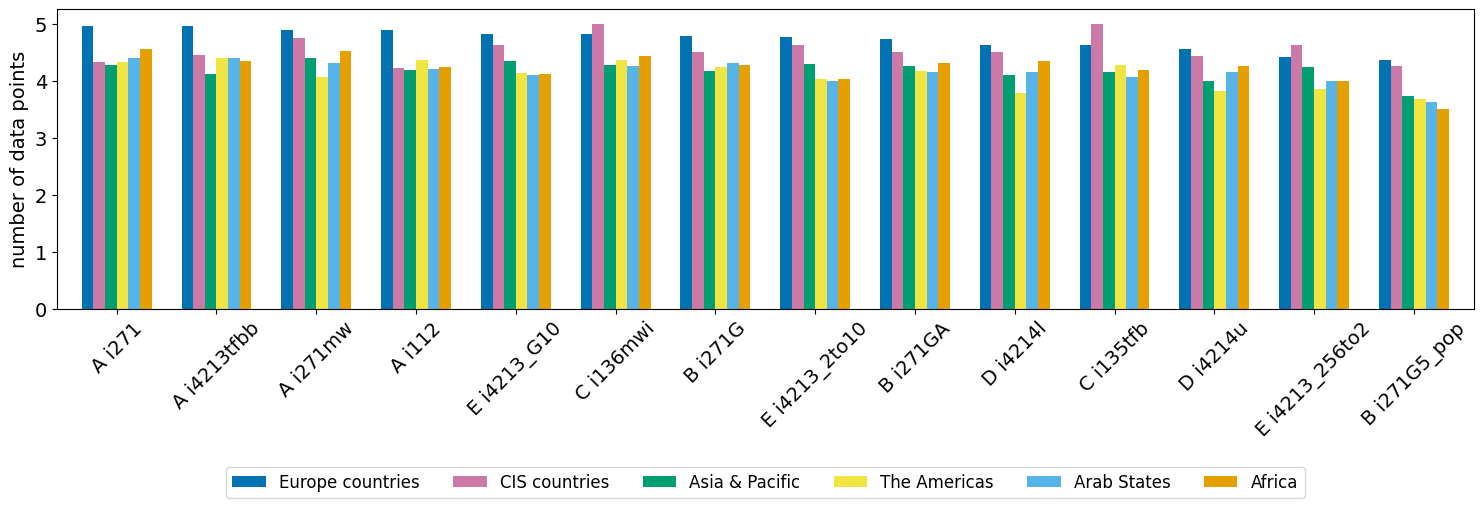

In [70]:
# Define your custom order
custom_order = ['Europe countries','CIS countries', 'Asia & Pacific', 'The Americas', 'Arab States', 'Africa']
#, 'Other Economies']

custom_colors = [
    '#0072B2',  # Blue
    '#CC79A7',  # Pink/Purple
    '#009E73',  # Green
    '#F0E442',  # Yellow
    '#56B4E9',  # Light Blue
    '#E69F00'  # Orange
    #'#696969'
    #'#999999',   # Grey
    ]

rename_dict = {
 'i112_5Y': 'A i112',
 'i135tfb_5Y': 'C i135tfb',
 'i136mwi_5Y': 'C i136mwi',
 'i271_5Y': 'A i271',
 'i271G_5Y': 'B i271G',
 'i271G5_pop_5Y': 'B i271G5_pop',
 'i271GA_5Y': 'B i271GA',
 'i271mw_5Y': 'A i271mw',
 'i4213_256to2_5Y': 'E i4213_256to2',
 'i4213_2to10_5Y': 'E i4213_2to10',
 'i4213_G10_5Y': 'E i4213_G10',
 'i4213tfbb_5Y': 'A i4213tfbb',
 'i4214l_5Y': 'D i4214l',
 'i4214u_5Y': 'D i4214u'
}

pivoted[['region_name','i112_5Y', 'i135tfb_5Y',
       'i136mwi_5Y', 'i271_5Y', 'i271G_5Y', 'i271G5_pop_5Y', 'i271GA_5Y',
       'i271mw_5Y', 'i4213_256to2_5Y', 'i4213_2to10_5Y', 'i4213_G10_5Y',
       'i4213tfbb_5Y', 'i4214l_5Y', 'i4214u_5Y']].rename(
     columns=rename_dict).groupby('region_name').mean(numeric_only=True).reindex(custom_order).T.sort_values(by='Europe countries', ascending=False).plot(kind='bar',
                                                  figsize=(15, 6),
                                                  color=custom_colors,
                                                  width=0.7)
#plt.title('Average number of data points per indicator in the past 5 years (2020-2024)')
plt.xlabel('')
plt.ylabel('number of data points', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=7,
    fontsize=12
)

plt.tight_layout()
plt.show()

In [71]:
pivoted.WB_Income.unique()

array(['Low income', 'Upper middle income', 'Lower middle income',
       'High income'], dtype=object)

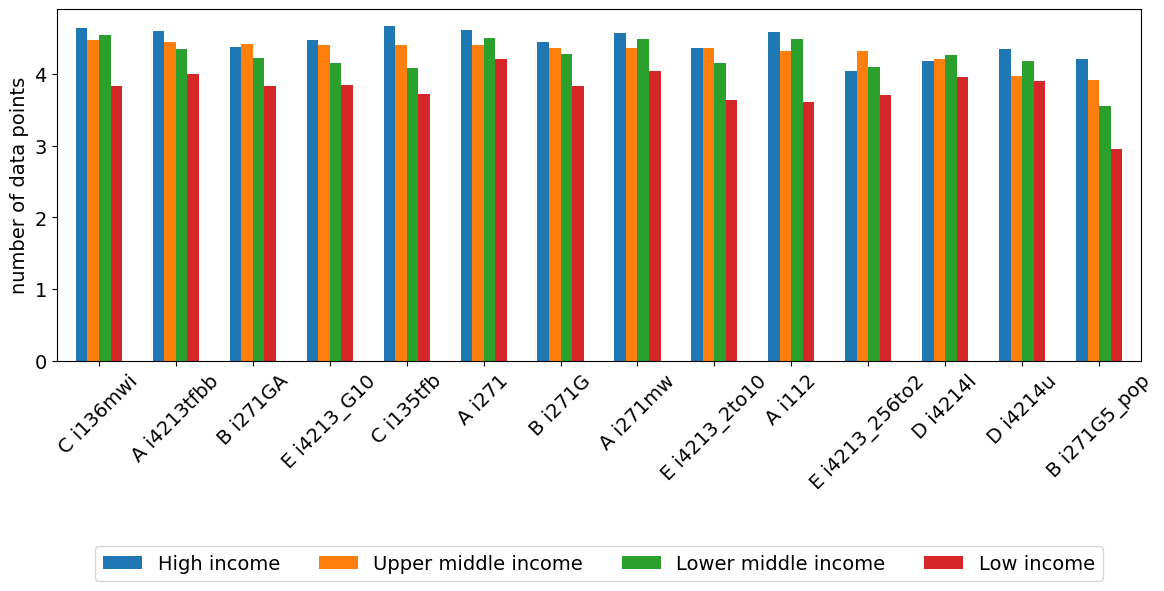

In [72]:

rename_dict = {
  'i112_5Y': 'A i112',
 'i135tfb_5Y': 'C i135tfb',
 'i136mwi_5Y': 'C i136mwi',
 'i271_5Y': 'A i271',
 'i271G_5Y': 'B i271G',
 'i271G5_pop_5Y': 'B i271G5_pop',
 'i271GA_5Y': 'B i271GA',
 'i271mw_5Y': 'A i271mw',
 'i4213_256to2_5Y': 'E i4213_256to2',
 'i4213_2to10_5Y': 'E i4213_2to10',
 'i4213_G10_5Y': 'E i4213_G10',
 'i4213tfbb_5Y': 'A i4213tfbb',
 'i4214l_5Y': 'D i4214l',
 'i4214u_5Y': 'D i4214u'
}

# Define your custom order
custom_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']

pivoted[['WB_Income','i112_5Y', 'i135tfb_5Y',
       'i136mwi_5Y', 'i271_5Y', 'i271G_5Y', 'i271G5_pop_5Y', 'i271GA_5Y',
       'i271mw_5Y', 'i4213_256to2_5Y', 'i4213_2to10_5Y', 'i4213_G10_5Y',
       'i4213tfbb_5Y', 'i4214l_5Y', 'i4214u_5Y'
 ]].rename(columns=rename_dict).groupby('WB_Income').mean(numeric_only=True).T.sort_values(
     by='Upper middle income', ascending=False)[custom_order].plot(kind='bar',
                                                figsize=(12, 6),
                                                width=0.6)
#plt.title('Average number of data points per indicator in the past 5 years (2020-2024)')
plt.xlabel('')
plt.ylabel('number of data points', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1) # places legend bottom

# adjust bottom margin to make space for legend
plt.subplots_adjust(bottom=0.3)  # increase bottom space

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=4,
    fontsize=14
)
plt.tight_layout()
plt.show()

In [73]:
pivoted.new_group.unique()

array(['SIDS + LDC', 'Other developing and transition', 'Developed-OECD'],
      dtype=object)

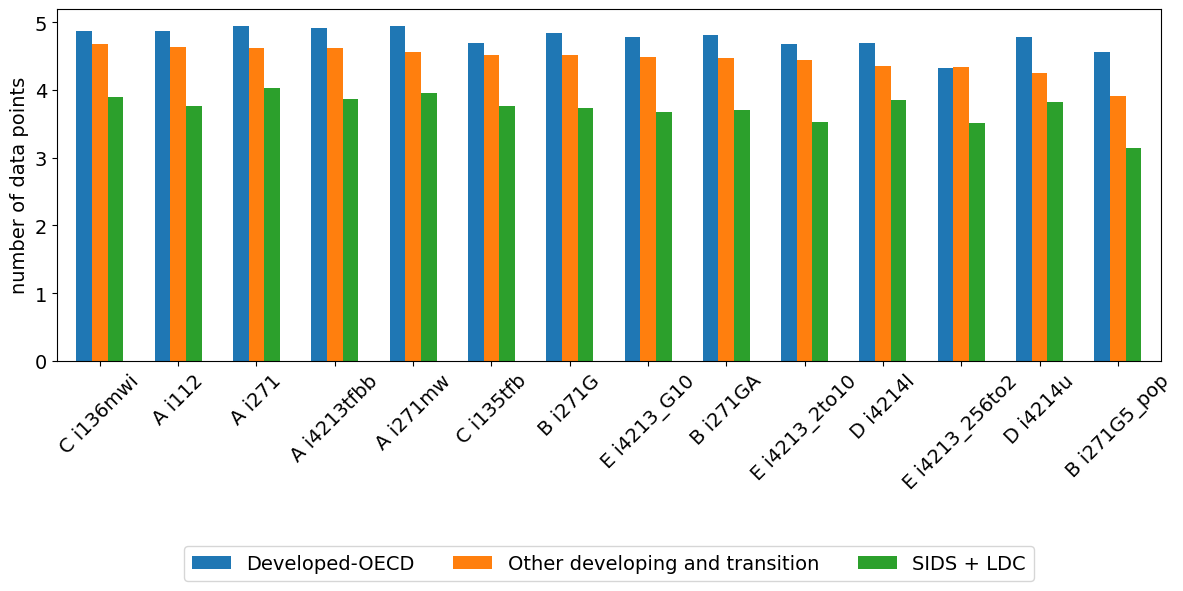

In [74]:

rename_dict = {
  'i112_5Y': 'A i112',
 'i135tfb_5Y': 'C i135tfb',
 'i136mwi_5Y': 'C i136mwi',
 'i271_5Y': 'A i271',
 'i271G_5Y': 'B i271G',
 'i271G5_pop_5Y': 'B i271G5_pop',
 'i271GA_5Y': 'B i271GA',
 'i271mw_5Y': 'A i271mw',
 'i4213_256to2_5Y': 'E i4213_256to2',
 'i4213_2to10_5Y': 'E i4213_2to10',
 'i4213_G10_5Y': 'E i4213_G10',
 'i4213tfbb_5Y': 'A i4213tfbb',
 'i4214l_5Y': 'D i4214l',
 'i4214u_5Y': 'D i4214u'
}

# Define your custom order
custom_order = ['Developed-OECD', 'Other developing and transition', 'SIDS + LDC']

pivoted[['new_group','i112_5Y', 'i135tfb_5Y',
       'i136mwi_5Y', 'i271_5Y', 'i271G_5Y', 'i271G5_pop_5Y', 'i271GA_5Y',
       'i271mw_5Y', 'i4213_256to2_5Y', 'i4213_2to10_5Y', 'i4213_G10_5Y',
       'i4213tfbb_5Y', 'i4214l_5Y', 'i4214u_5Y'
 ]].rename(columns=rename_dict).groupby('new_group').mean(numeric_only=True).T.sort_values(
     by='Other developing and transition', ascending=False)[custom_order].plot(kind='bar',
                                                figsize=(12, 6),
                                                width=0.6)
#plt.title('Average number of data points per indicator in the past 5 years (2020-2024)')
plt.xlabel('')
plt.ylabel('number of data points', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1) # places legend bottom

# adjust bottom margin to make space for legend
plt.subplots_adjust(bottom=0.3)  # increase bottom space

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=3,
    fontsize=14
)
plt.tight_layout()
plt.show()

In [75]:
pivoted.CountryType.unique()

array(['Developing', 'Developed'], dtype=object)

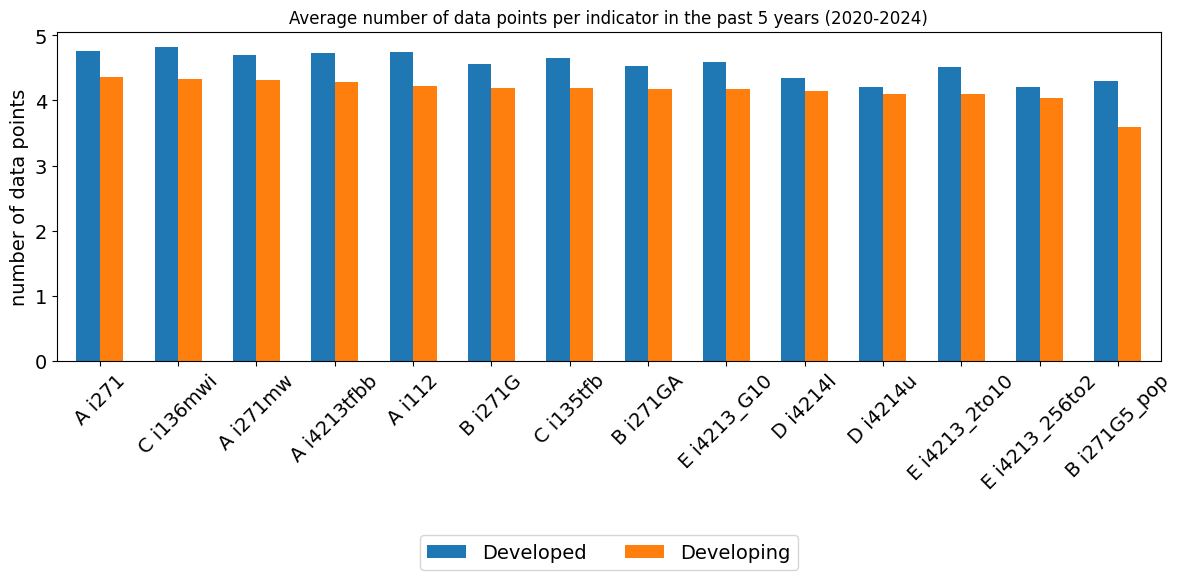

In [76]:

rename_dict = {
  'i112_5Y': 'A i112',
 'i135tfb_5Y': 'C i135tfb',
 'i136mwi_5Y': 'C i136mwi',
 'i271_5Y': 'A i271',
 'i271G_5Y': 'B i271G',
 'i271G5_pop_5Y': 'B i271G5_pop',
 'i271GA_5Y': 'B i271GA',
 'i271mw_5Y': 'A i271mw',
 'i4213_256to2_5Y': 'E i4213_256to2',
 'i4213_2to10_5Y': 'E i4213_2to10',
 'i4213_G10_5Y': 'E i4213_G10',
 'i4213tfbb_5Y': 'A i4213tfbb',
 'i4214l_5Y': 'D i4214l',
 'i4214u_5Y': 'D i4214u'
}

# Define your custom order
custom_order = [ 'Developed', 'Developing']

pivoted[['CountryType','i112_5Y', 'i135tfb_5Y',
       'i136mwi_5Y', 'i271_5Y', 'i271G_5Y', 'i271G5_pop_5Y', 'i271GA_5Y',
       'i271mw_5Y', 'i4213_256to2_5Y', 'i4213_2to10_5Y', 'i4213_G10_5Y',
       'i4213tfbb_5Y', 'i4214l_5Y', 'i4214u_5Y'
 ]].rename(columns=rename_dict).groupby('CountryType').mean(numeric_only=True).T.sort_values(
     by='Developing', ascending=False)[custom_order].plot(kind='bar',
                                                figsize=(12, 6),
                                                width=0.6)
plt.title('Average number of data points per indicator in the past 5 years (2020-2024)')
plt.xlabel('')
plt.ylabel('number of data points', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1) # places legend bottom

# adjust bottom margin to make space for legend
plt.subplots_adjust(bottom=0.3)  # increase bottom space

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=2,
    fontsize=14
)
plt.tight_layout()
plt.show()

## Charts for country profile (one country)

In [77]:
pivoted[pivoted.ShortName=='Madagascar'][['region_name','i112_5Y', 'i135tfb_5Y',
       'i136mwi_5Y', 'i271_5Y', 'i271G_5Y', 'i271G5_pop_5Y', 'i271GA_5Y',
       'i271mw_5Y', 'i4213_256to2_5Y', 'i4213_2to10_5Y', 'i4213_G10_5Y',
       'i4213tfbb_5Y', 'i4214l_5Y', 'i4214u_5Y']]

,region_name,i112_5Y,i135tfb_5Y,i136mwi_5Y,i271_5Y,i271G_5Y,i271G5_pop_5Y,i271GA_5Y,i271mw_5Y,i4213_256to2_5Y,i4213_2to10_5Y,i4213_G10_5Y,i4213tfbb_5Y,i4214l_5Y,i4214u_5Y
101,Africa,3.0,3.0,3.0,3.0,2.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0


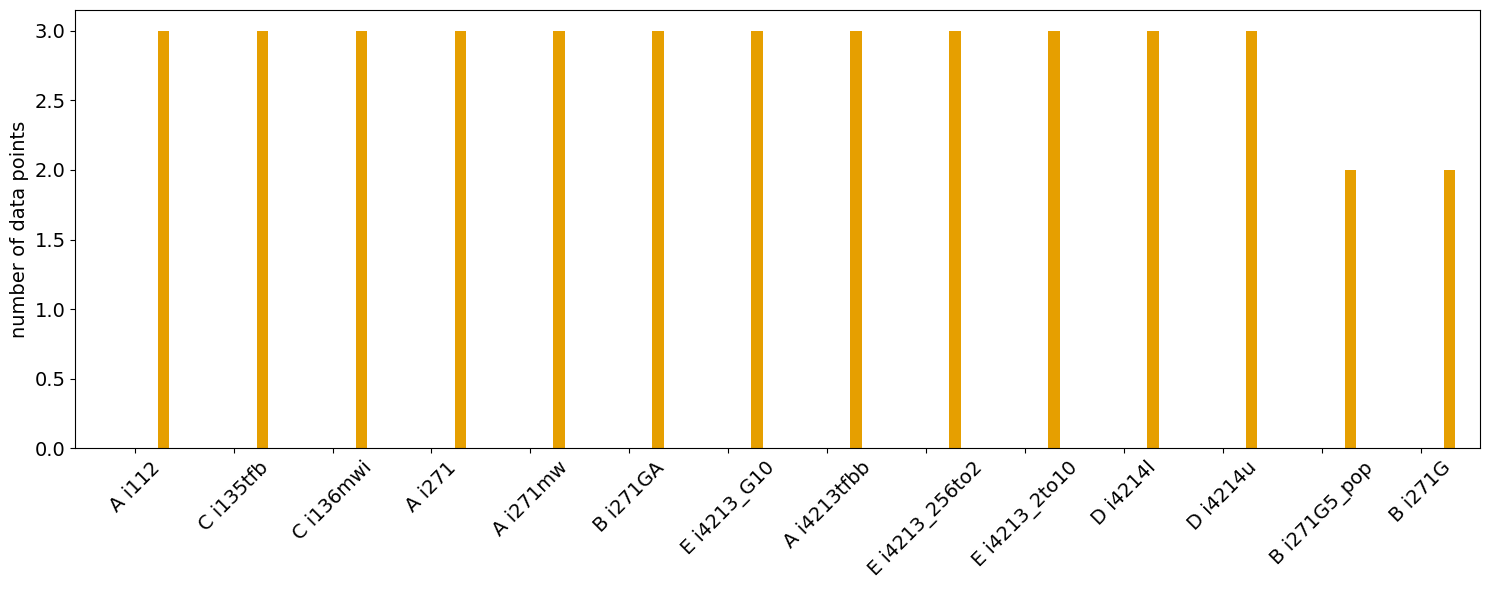

In [78]:
# Define your custom order
custom_order = ['Europe countries','CIS countries', 'Asia & Pacific', 'The Americas', 'Arab States', 'Africa']
#, 'Other Economies']

custom_colors = [
    '#0072B2',  # Blue
    '#CC79A7',  # Pink/Purple
    '#009E73',  # Green
    '#F0E442',  # Yellow
    '#56B4E9',  # Light Blue
    '#E69F00'  # Orange
    #'#696969'
    #'#999999',   # Grey
    ]

rename_dict = {
 'i112_5Y': 'A i112',
 'i135tfb_5Y': 'C i135tfb',
 'i136mwi_5Y': 'C i136mwi',
 'i271_5Y': 'A i271',
 'i271G_5Y': 'B i271G',
 'i271G5_pop_5Y': 'B i271G5_pop',
 'i271GA_5Y': 'B i271GA',
 'i271mw_5Y': 'A i271mw',
 'i4213_256to2_5Y': 'E i4213_256to2',
 'i4213_2to10_5Y': 'E i4213_2to10',
 'i4213_G10_5Y': 'E i4213_G10',
 'i4213tfbb_5Y': 'A i4213tfbb',
 'i4214l_5Y': 'D i4214l',
 'i4214u_5Y': 'D i4214u'
}

pivoted[pivoted.ShortName=='Madagascar'][['region_name','i112_5Y', 'i135tfb_5Y',
       'i136mwi_5Y', 'i271_5Y', 'i271G_5Y', 'i271G5_pop_5Y', 'i271GA_5Y',
       'i271mw_5Y', 'i4213_256to2_5Y', 'i4213_2to10_5Y', 'i4213_G10_5Y',
       'i4213tfbb_5Y', 'i4214l_5Y', 'i4214u_5Y']].rename(
     columns=rename_dict).groupby('region_name').mean(numeric_only=True).reindex(custom_order).T.sort_values(by='Africa', ascending=False).plot(kind='bar',
                                                  figsize=(15, 6),
                                                  color=custom_colors,
                                                  width=0.7)
#plt.title('MADAGASCAR: Average number of data points per indicator in the past 5 years (2020-2024)')
plt.xlabel('')
plt.ylabel('number of data points', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

# Step 1: Get current handles and labels
#handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
#label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
#plt.legend(
    #[label_to_handle[label] for label in custom_order],
   # custom_order,
    #loc='upper center',
    #bbox_to_anchor=(0.5, -0.5),
    #ncol=7,
   # fontsize=12
#)
plt.legend().remove()


plt.tight_layout()
plt.show()

## Group-wise calculations for availability (by group of indicators)


Within the group take the best availability - the NSS has the capacity to produce this data, but maybe it chooses not to produce all indicators because lack of policy interest

In [79]:
# Make calculations for the group of indicators - take the maximum per group

wti_counts.groupby(["ShortName", "region_name", "wti_group", "IsoCode", 'new_group', 'CountryType', 'WB_Income'], as_index=False)["5Y"].max().head()

,ShortName,region_name,wti_group,IsoCode,new_group,CountryType,WB_Income,5Y
0,Afghanistan,Asia & Pacific,A. Contracting_records,AFG,SIDS + LDC,Developing,Low income,4
1,Afghanistan,Asia & Pacific,B. Cell_tower_coverage,AFG,SIDS + LDC,Developing,Low income,3
2,Afghanistan,Asia & Pacific,C. Operator_traffic,AFG,SIDS + LDC,Developing,Low income,2
3,Afghanistan,Asia & Pacific,D. Operators_wholesale,AFG,SIDS + LDC,Developing,Low income,2
4,Albania,Europe countries,A. Contracting_records,ALB,Other developing and transition,Developed,Upper middle income,5


In [80]:
wti_counts_group = wti_counts.groupby(["ShortName", "region_name", "wti_group", "IsoCode", 'new_group', 'CountryType', 'WB_Income'], as_index=False)["5Y"].max()

# add percentage column

wti_counts_group['5Y_p'] = wti_counts_group['5Y'] / 5 *100

pivoted_group = wti_counts_group.pivot(index=['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType', 'WB_Income'], columns='wti_group', values=['5Y', '5Y_p'])

# Pivot back my data so I ca plot it
# Replace NaNs with 0 - rolling this back, I' no longer filling NAs with 0
#pivoted_group = pivoted_group.fillna(0)

# Flatten and rename the columns
pivoted_group.columns = [
    f"{indicator}_{suffix}"
    for suffix, indicator in pivoted_group.columns
]

pivoted_group.reset_index(inplace=True)

pivoted_group.head()

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,A. Contracting_records_5Y,B. Cell_tower_coverage_5Y,C. Operator_traffic_5Y,D. Operators_wholesale_5Y,E. Contracting_fixed_broadband_speed_5Y,A. Contracting_records_5Y_p,B. Cell_tower_coverage_5Y_p,C. Operator_traffic_5Y_p,D. Operators_wholesale_5Y_p,E. Contracting_fixed_broadband_speed_5Y_p
0,Afghanistan,Asia & Pacific,AFG,SIDS + LDC,Developing,Low income,4.0,3.0,2.0,2.0,NaN,80.0,60.0,40.0,40.0,NaN
1,Albania,Europe countries,ALB,Other developing and transition,Developed,Upper middle income,5.0,5.0,5.0,5.0,5.0,100.0,100.0,100.0,100.0,100.0
2,Algeria,Arab States,DZA,Other developing and transition,Developing,Lower middle income,5.0,5.0,5.0,5.0,5.0,100.0,100.0,100.0,100.0,100.0
3,Andorra,Europe countries,AND,Other developing and transition,Developed,High income,5.0,5.0,5.0,5.0,5.0,100.0,100.0,100.0,100.0,100.0
4,Angola,Africa,AGO,SIDS + LDC,Developing,Lower middle income,5.0,5.0,5.0,4.0,4.0,100.0,100.0,100.0,80.0,80.0


In [81]:
pivoted_group.IsoCode.nunique()

188

In [82]:
pivoted_group['E. Contracting_fixed_broadband_speed_5Y'].describe()

,E. Contracting_fixed_broadband_speed_5Y
count,172.000000
mean,4.296512
std,1.179449
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [83]:
pivoted_group.columns

Index(['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income', 'A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y',
       'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y',
       'E. Contracting_fixed_broadband_speed_5Y',
       'A. Contracting_records_5Y_p', 'B. Cell_tower_coverage_5Y_p',
       'C. Operator_traffic_5Y_p', 'D. Operators_wholesale_5Y_p',
       'E. Contracting_fixed_broadband_speed_5Y_p'],
      dtype='object')

In [84]:
pivoted_group.region_name.unique()

array(['Asia & Pacific', 'Europe countries', 'Arab States', 'Africa',
       'The Americas', 'CIS countries', 'Other Economies'], dtype=object)

In [85]:
pivoted_group[['A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y',
       'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y',
       'E. Contracting_fixed_broadband_speed_5Y']].describe()

,A. Contracting_records_5Y,B. Cell_tower_coverage_5Y,C. Operator_traffic_5Y,D. Operators_wholesale_5Y,E. Contracting_fixed_broadband_speed_5Y
count,188.000000,186.000000,163.000000,142.000000,172.000000
mean,4.526596,4.360215,4.496933,4.176056,4.296512
std,0.999644,1.126740,1.026646,1.317096,1.179449
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,5.000000,4.000000,4.500000,4.000000,4.000000
50%,5.000000,5.000000,5.000000,5.000000,5.000000
75%,5.000000,5.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000


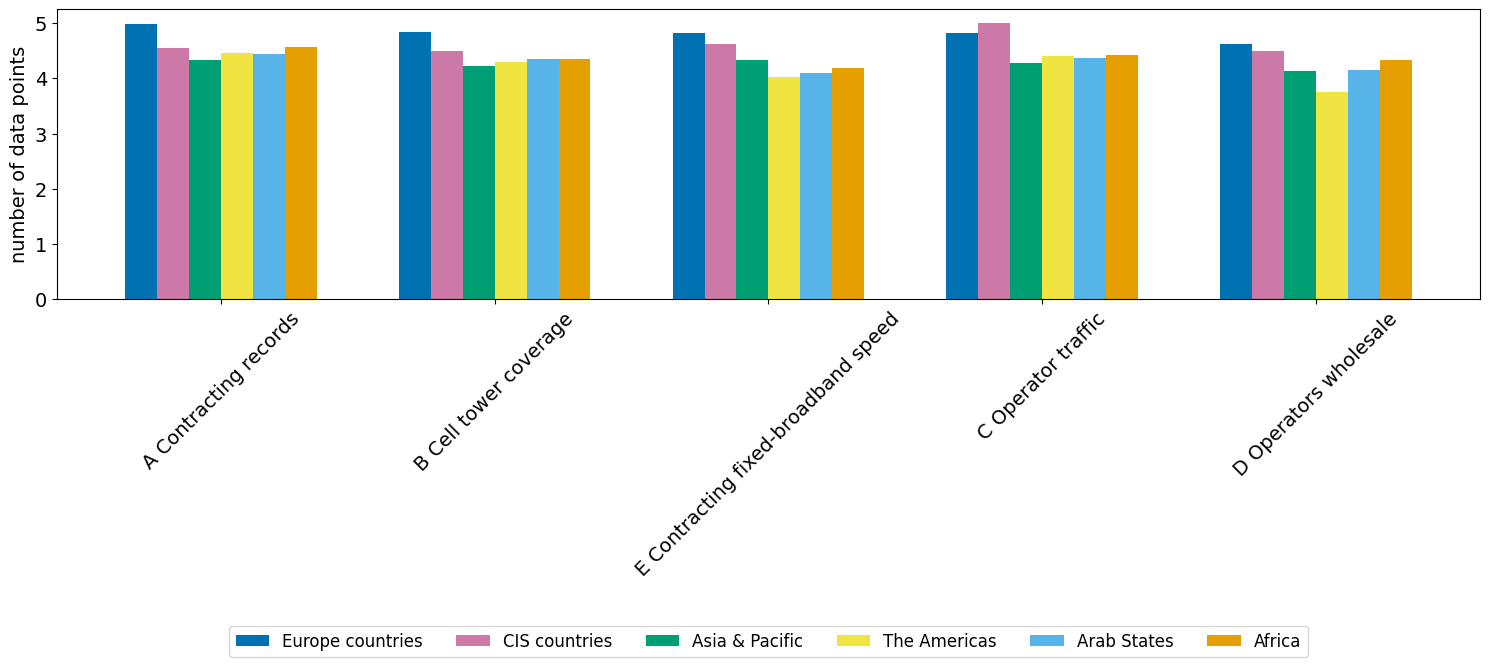

In [86]:
# Define your custom order
custom_order = ['Europe countries','CIS countries', 'Asia & Pacific', 'The Americas', 'Arab States', 'Africa']
#, 'Other Economies']

custom_colors = [
    '#0072B2',  # Blue
    '#CC79A7',  # Pink/Purple
    '#009E73',  # Green
    '#F0E442',  # Yellow
    '#56B4E9',  # Light Blue
    '#E69F00'  # Orange
    #'#696969'
    #'#999999',   # Grey
    ]

rename_dict = {
'B. Cell_tower_coverage_5Y': "B Cell tower coverage",
'A. Contracting_records_5Y':"A Contracting records",
'C. Operator_traffic_5Y':"C Operator traffic",
'D. Operators_wholesale_5Y':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_5Y': "E Contracting fixed-broadband speed"
}

pivoted_group[['region_name','B. Cell_tower_coverage_5Y',
       'A. Contracting_records_5Y', 'C. Operator_traffic_5Y',
       'D. Operators_wholesale_5Y', 'E. Contracting_fixed_broadband_speed_5Y']].rename(
     columns=rename_dict).groupby('region_name').mean(numeric_only=True).reindex(custom_order).T.sort_values(by='Europe countries', ascending=False).plot(kind='bar',
                                                  figsize=(15, 6),
                                                  color=custom_colors,
                                                  width=0.7)
#plt.title('Average number of data points per indicator in the past 5 years (2020-2024)')
plt.xlabel('')
plt.ylabel('number of data points', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

# adjust bottom margin to make space for legend
plt.subplots_adjust(bottom=0.6)  # increase bottom space

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -1.1),
    ncol=7,
    fontsize=12
)

plt.tight_layout()
plt.show()

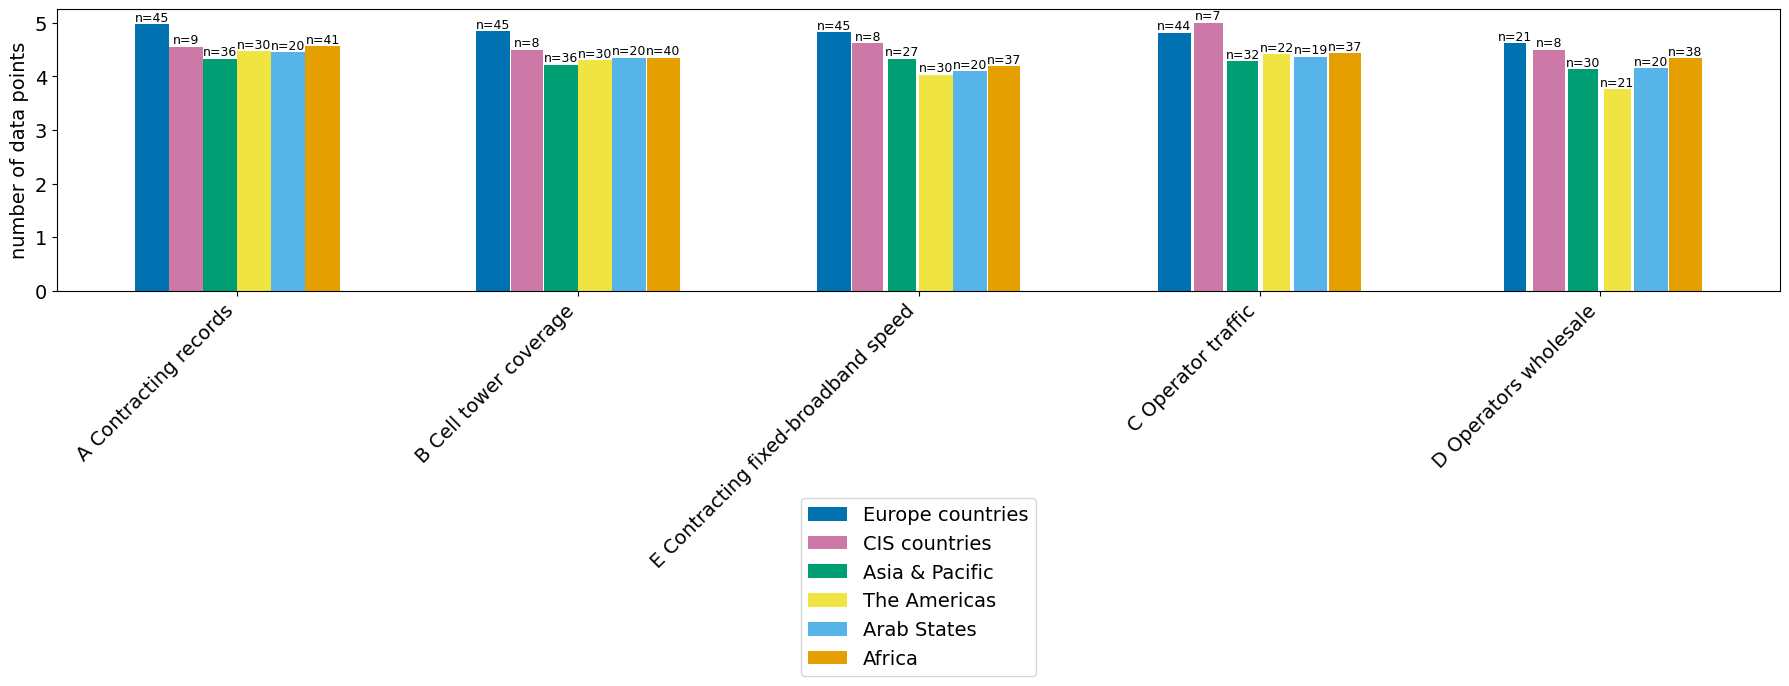

In [87]:
from matplotlib.patches import Patch

# Define your custom order
custom_order = ['Europe countries','CIS countries', 'Asia & Pacific', 'The Americas', 'Arab States', 'Africa']
#, 'Other Economies']

custom_colors = [
    '#0072B2',  # Blue
    '#CC79A7',  # Pink/Purple
    '#009E73',  # Green
    '#F0E442',  # Yellow
    '#56B4E9',  # Light Blue
    '#E69F00'  # Orange
    ]

rename_dict = {
'B. Cell_tower_coverage_5Y': "B Cell tower coverage",
'A. Contracting_records_5Y':"A Contracting records",
'C. Operator_traffic_5Y':"C Operator traffic",
'D. Operators_wholesale_5Y':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_5Y': "E Contracting fixed-broadband speed"
}


subset = pivoted_group[['region_name','B. Cell_tower_coverage_5Y',
       'A. Contracting_records_5Y', 'C. Operator_traffic_5Y',
       'D. Operators_wholesale_5Y', 'E. Contracting_fixed_broadband_speed_5Y']].rename(
     columns=rename_dict)

# Calculate means and counts
means = subset.groupby('region_name').mean(numeric_only=True).T
counts = subset.groupby('region_name').count().T

# Sort by Europe countries
means_sorted = means.sort_values(by='Europe countries', ascending=False)[custom_order]
counts_sorted = counts.loc[means_sorted.index][custom_order]

# Set width factor range
min_width_factor = 0.3
max_width_factor = 1.0

# Create figure
fig, ax = plt.subplots(figsize=(18, 6))

# Plot each region separately to control width
x = np.arange(len(means_sorted.index))
base_width = 0.6 / len(custom_order)

for i, region in enumerate(custom_order):
    # Calculate width for each bar WITHIN THIS GROUP
    group_max_count = counts_sorted[region].max()

    # Normalize within the group
    width_factors = counts_sorted[region] / group_max_count * (max_width_factor - min_width_factor) + min_width_factor

    # Plot bars with individual widths
    for j, (indicator, value) in enumerate(means_sorted[region].items()):
        bar_width = base_width * width_factors.iloc[j]
        bar_x = x[j] + i * base_width - (len(custom_order) - 1) * base_width / 2

        ax.bar(
            bar_x,
            value,
            bar_width,
            color=custom_colors[i]
        )

        # Add text label on top of bar
        count = int(counts_sorted[region].iloc[j])
        if count > 0:
            ax.text(
                bar_x,
                value,
                f'n={count}',
                ha='center',
                va='bottom',
                fontsize=9,
                rotation=0
            )

ax.set_xlabel('', fontsize=14)
ax.set_ylabel('number of data points', fontsize=14)
#plt.title('Average number of data points per indicator in the past 5 years (2020-2024)')
ax.set_xticks(x)
ax.set_xticklabels(means_sorted.index, rotation=45, fontsize=14, ha='right')
ax.tick_params(axis='y', labelsize=14)

# Create custom legend
legend_handles = [Patch(facecolor=custom_colors[i], label=region)
                  for i, region in enumerate(custom_order)] #

plt.subplots_adjust(bottom=0.7)
plt.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.7),
    ncol=1,
    fontsize=14
)

plt.tight_layout()
plt.show()



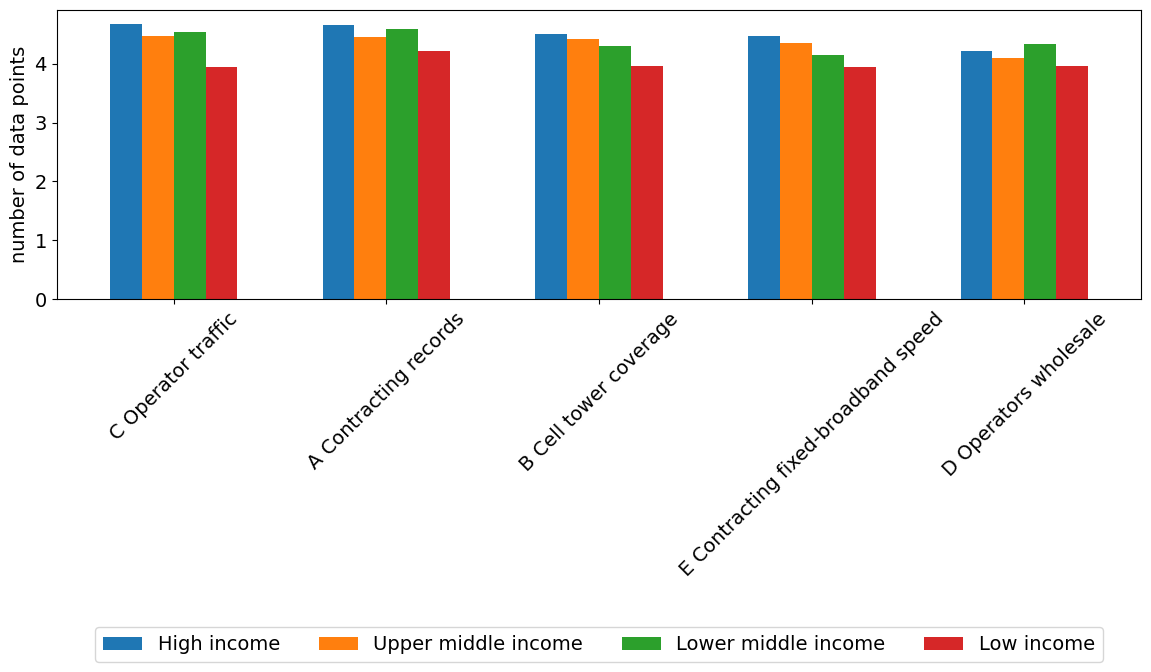

In [88]:
rename_dict = {
'B. Cell_tower_coverage_5Y': "B Cell tower coverage",
'A. Contracting_records_5Y':"A Contracting records",
'C. Operator_traffic_5Y':"C Operator traffic",
'D. Operators_wholesale_5Y':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_5Y': "E Contracting fixed-broadband speed"
}

# Define your custom order
custom_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']

pivoted_group[['WB_Income','B. Cell_tower_coverage_5Y',
       'A. Contracting_records_5Y', 'C. Operator_traffic_5Y',
       'D. Operators_wholesale_5Y', 'E. Contracting_fixed_broadband_speed_5Y'
 ]].rename(columns=rename_dict).groupby('WB_Income').mean(numeric_only=True).T.sort_values(
     by='Upper middle income', ascending=False)[custom_order].plot(kind='bar',
                                                figsize=(12, 6),
                                                width=0.6)
#plt.title('Average number of data points per indicator in the past 5 years (2020-2024)')
plt.xlabel('')
plt.ylabel('number of data points', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1) # places legend bottom

# adjust bottom margin to make space for legend
plt.subplots_adjust(bottom=0.7)  # increase bottom space

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -1.1),
    ncol=4,
    fontsize=14
)
plt.tight_layout()
plt.show()

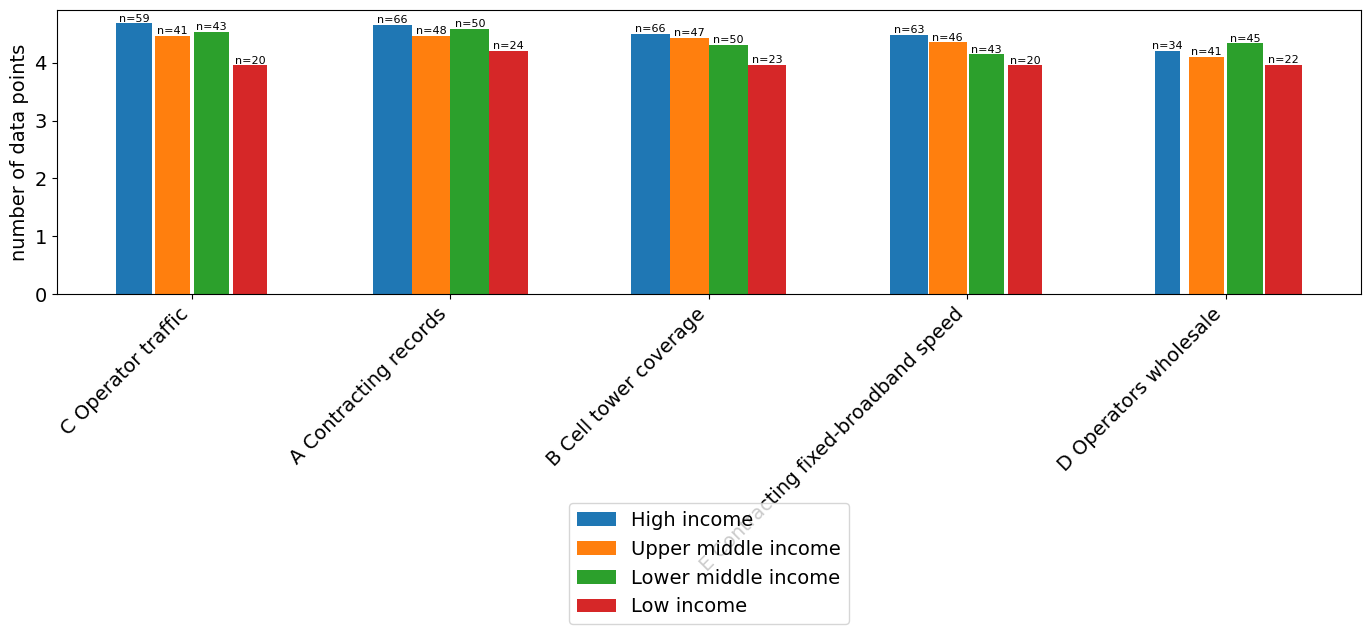

In [89]:
from matplotlib.patches import Patch

# Define your custom order
custom_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']
#, 'Other Economies']

rename_dict = {
'B. Cell_tower_coverage_5Y': "B Cell tower coverage",
'A. Contracting_records_5Y':"A Contracting records",
'C. Operator_traffic_5Y':"C Operator traffic",
'D. Operators_wholesale_5Y':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_5Y': "E Contracting fixed-broadband speed"
}

custom_colors = ['#1f77b4',  # Blue
'#ff7f0e' , # Orange
'#2ca02c',  # Green
'#d62728'  # Red
]

subset = pivoted_group[['WB_Income','B. Cell_tower_coverage_5Y',
       'A. Contracting_records_5Y', 'C. Operator_traffic_5Y',
       'D. Operators_wholesale_5Y', 'E. Contracting_fixed_broadband_speed_5Y']].rename(
     columns=rename_dict)

# Calculate means and counts
means = subset.groupby('WB_Income').mean(numeric_only=True).T
counts = subset.groupby('WB_Income').count().T

# Sort by Europe countries
means_sorted = means.sort_values(by='Upper middle income', ascending=False)[custom_order]
counts_sorted = counts.loc[means_sorted.index][custom_order]

# Set width factor range
min_width_factor = 0.3
max_width_factor = 1.0

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot each region separately to control width
x = np.arange(len(means_sorted.index))
base_width = 0.6 / len(custom_order)

for i, region in enumerate(custom_order):
    # Calculate width for each bar WITHIN THIS GROUP
    group_max_count = counts_sorted[region].max()

    # Normalize within the group
    width_factors = counts_sorted[region] / group_max_count * (max_width_factor - min_width_factor) + min_width_factor

    # Plot bars with individual widths
    for j, (indicator, value) in enumerate(means_sorted[region].items()):
        bar_width = base_width * width_factors.iloc[j]
        bar_x = x[j] + i * base_width - (len(custom_order) - 1) * base_width / 2

        ax.bar(
            bar_x,
            value,
            bar_width,
            color=custom_colors[i]
        )

        # Add text label on top of bar
        count = int(counts_sorted[region].iloc[j])
        if count > 0:
            ax.text(
                bar_x,
                value,
                f'n={count}',
                ha='center',
                va='bottom',
                fontsize=8,
                rotation=0
            )

ax.set_xlabel('', fontsize=14)
ax.set_ylabel('number of data points', fontsize=14)
#plt.title('Average number of data points per indicator in the past 5 years (2020-2024)')
ax.set_xticks(x)
ax.set_xticklabels(means_sorted.index, rotation=45, fontsize=14, ha='right')
ax.tick_params(axis='y', labelsize=14)

# Create custom legend
legend_handles = [Patch(facecolor=custom_colors[i], label=region)
                  for i, region in enumerate(custom_order)] #

plt.subplots_adjust(bottom=0.7)
plt.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.7),
    ncol=1,
    fontsize=14
)

plt.tight_layout()
plt.show()



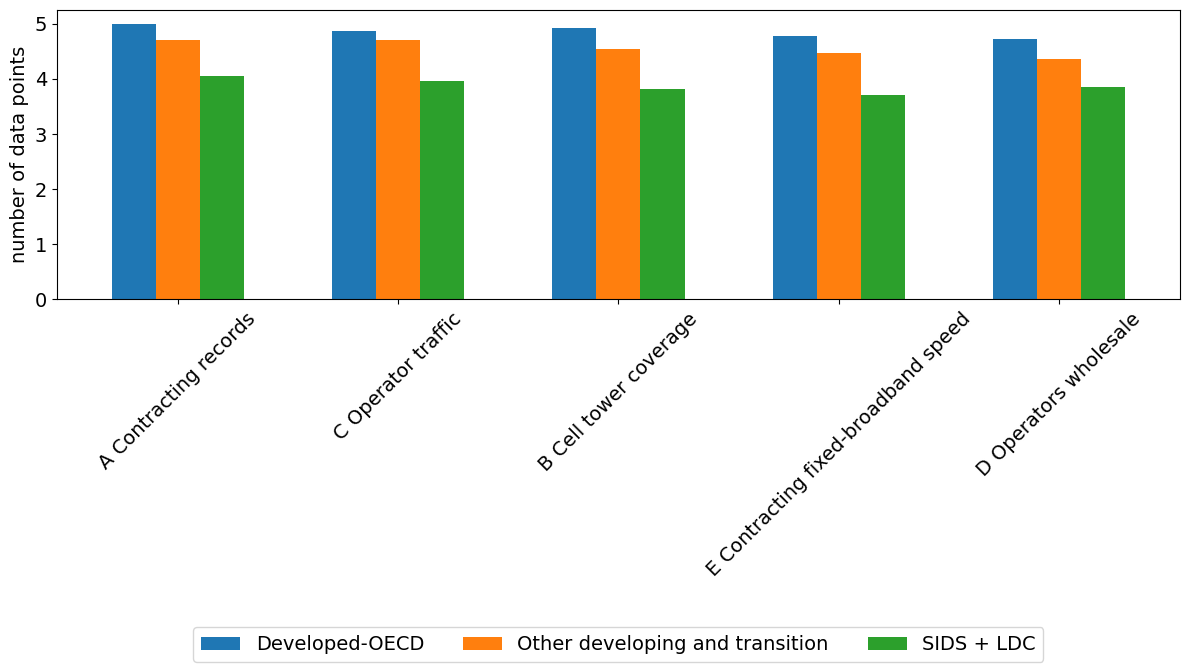

In [90]:
rename_dict = {
'B. Cell_tower_coverage_5Y': "B Cell tower coverage",
'A. Contracting_records_5Y':"A Contracting records",
'C. Operator_traffic_5Y':"C Operator traffic",
'D. Operators_wholesale_5Y':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_5Y': "E Contracting fixed-broadband speed"
}

# Define your custom order
custom_order = ['Developed-OECD', 'Other developing and transition', 'SIDS + LDC']

pivoted_group[['new_group','B. Cell_tower_coverage_5Y',
       'A. Contracting_records_5Y', 'C. Operator_traffic_5Y',
       'D. Operators_wholesale_5Y', 'E. Contracting_fixed_broadband_speed_5Y'
 ]].rename(columns=rename_dict).groupby('new_group').mean(numeric_only=True).T.sort_values(
     by='Other developing and transition', ascending=False)[custom_order].plot(kind='bar',
                                                figsize=(12, 6),
                                                width=0.6)
#plt.title('Average number of data points per indicator in the past 5 years (2020-2024)')
plt.xlabel('')
plt.ylabel('number of data points', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1) # places legend bottom

# adjust bottom margin to make space for legend
plt.subplots_adjust(bottom=0.7)  # increase bottom space

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -1.1),
    ncol=4,
    fontsize=14
)
plt.tight_layout()
plt.show()

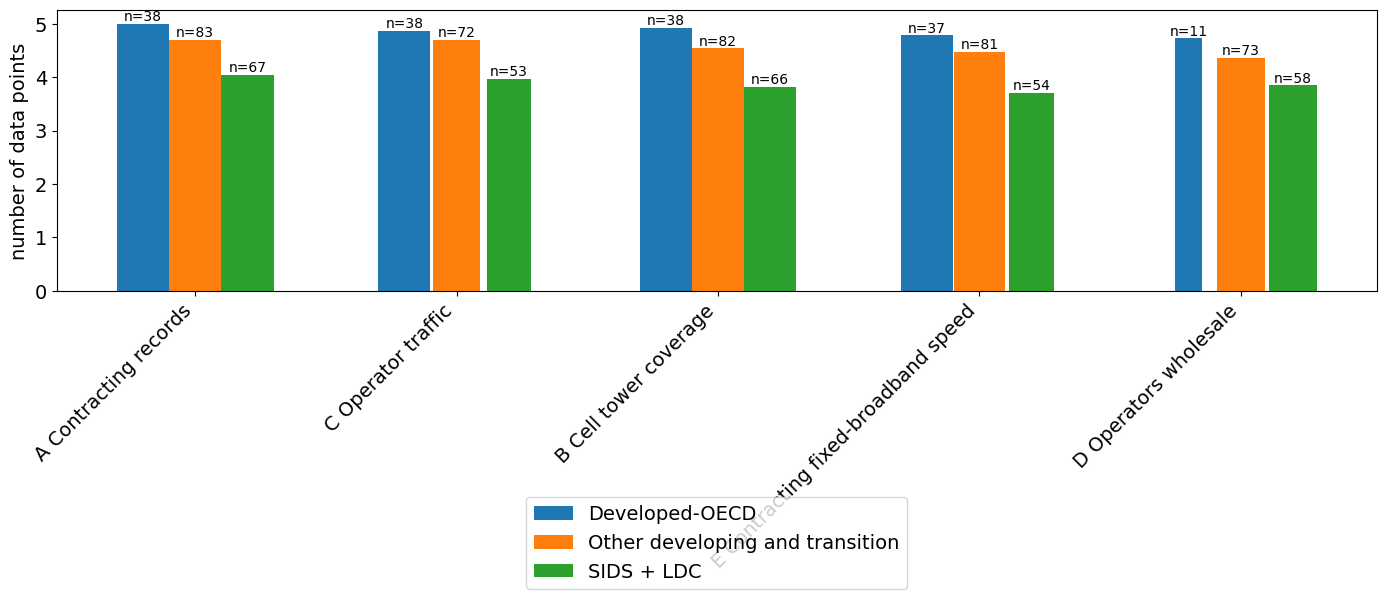

In [91]:
from matplotlib.patches import Patch

# Define your custom order
custom_order = ['Developed-OECD', 'Other developing and transition', 'SIDS + LDC']

rename_dict = {
'B. Cell_tower_coverage_5Y': "B Cell tower coverage",
'A. Contracting_records_5Y':"A Contracting records",
'C. Operator_traffic_5Y':"C Operator traffic",
'D. Operators_wholesale_5Y':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_5Y': "E Contracting fixed-broadband speed"
}

custom_colors = ['#1f77b4',  # Blue
'#ff7f0e' , # Orange
'#2ca02c',  # Green
'#d62728'  # Red
]

subset = pivoted_group[['new_group','B. Cell_tower_coverage_5Y',
       'A. Contracting_records_5Y', 'C. Operator_traffic_5Y',
       'D. Operators_wholesale_5Y', 'E. Contracting_fixed_broadband_speed_5Y']].rename(
     columns=rename_dict)

# Calculate means and counts
means = subset.groupby('new_group').mean(numeric_only=True).T
counts = subset.groupby('new_group').count().T

# Sort by Europe countries
means_sorted = means.sort_values(by='Other developing and transition', ascending=False)[custom_order]
counts_sorted = counts.loc[means_sorted.index][custom_order]

# Set width factor range
min_width_factor = 0.3
max_width_factor = 1.0

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot each region separately to control width
x = np.arange(len(means_sorted.index))
base_width = 0.6 / len(custom_order)

for i, region in enumerate(custom_order):
    # Calculate width for each bar WITHIN THIS GROUP
    group_max_count = counts_sorted[region].max()

    # Normalize within the group
    width_factors = counts_sorted[region] / group_max_count * (max_width_factor - min_width_factor) + min_width_factor

    # Plot bars with individual widths
    for j, (indicator, value) in enumerate(means_sorted[region].items()):
        bar_width = base_width * width_factors.iloc[j]
        bar_x = x[j] + i * base_width - (len(custom_order) - 1) * base_width / 2

        ax.bar(
            bar_x,
            value,
            bar_width,
            color=custom_colors[i]
        )

        # Add text label on top of bar
        count = int(counts_sorted[region].iloc[j])
        if count > 0:
            ax.text(
                bar_x,
                value,
                f'n={count}',
                ha='center',
                va='bottom',
                fontsize=10,
                rotation=0
            )

ax.set_xlabel('', fontsize=14)
ax.set_ylabel('number of data points', fontsize=14)
#plt.title('Average number of data points per indicator in the past 5 years (2020-2024)')
ax.set_xticks(x)
ax.set_xticklabels(means_sorted.index, rotation=45, fontsize=14, ha='right')
ax.tick_params(axis='y', labelsize=14)

# Create custom legend
legend_handles = [Patch(facecolor=custom_colors[i], label=region)
                  for i, region in enumerate(custom_order)] #

plt.subplots_adjust(bottom=0.7)
plt.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.7),
    ncol=1,
    fontsize=14
)

plt.tight_layout()
plt.show()



## Charts for country profile (one country)

In [92]:
pivoted_group[pivoted_group.ShortName=='Madagascar'][['region_name','B. Cell_tower_coverage_5Y',
       'A. Contracting_records_5Y', 'C. Operator_traffic_5Y',
       'D. Operators_wholesale_5Y', 'E. Contracting_fixed_broadband_speed_5Y']]

,region_name,B. Cell_tower_coverage_5Y,A. Contracting_records_5Y,C. Operator_traffic_5Y,D. Operators_wholesale_5Y,E. Contracting_fixed_broadband_speed_5Y
101,Africa,3.0,3.0,3.0,3.0,3.0


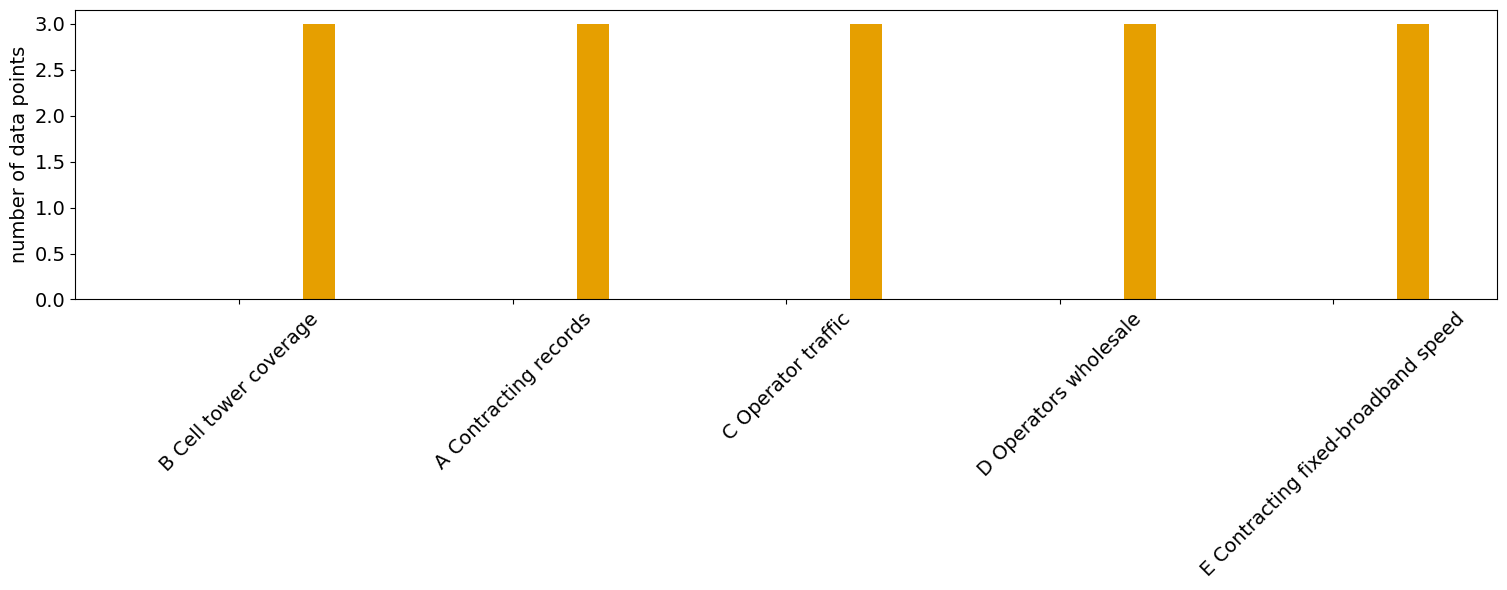

In [93]:
# Define your custom order
custom_order = ['Europe countries','CIS countries', 'Asia & Pacific', 'The Americas', 'Arab States', 'Africa']
#, 'Other Economies']

custom_colors = [
    '#0072B2',  # Blue
    '#CC79A7',  # Pink/Purple
    '#009E73',  # Green
    '#F0E442',  # Yellow
    '#56B4E9',  # Light Blue
    '#E69F00'  # Orange
    #'#696969'
    #'#999999',   # Grey
    ]

rename_dict = {
'B. Cell_tower_coverage_5Y': "B Cell tower coverage",
'A. Contracting_records_5Y':"A Contracting records",
'C. Operator_traffic_5Y':"C Operator traffic",
'D. Operators_wholesale_5Y':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_5Y': "E Contracting fixed-broadband speed"
}

pivoted_group[pivoted_group.ShortName=='Madagascar'][['region_name','B. Cell_tower_coverage_5Y',
       'A. Contracting_records_5Y', 'C. Operator_traffic_5Y',
       'D. Operators_wholesale_5Y', 'E. Contracting_fixed_broadband_speed_5Y']].rename(
     columns=rename_dict).groupby('region_name').mean(numeric_only=True).reindex(custom_order).T.sort_values(by='Africa', ascending=False).plot(kind='bar',
                                                  figsize=(15, 6),
                                                  color=custom_colors,
                                                  width=0.7)
#plt.title('Average number of data points per indicator in the past 5 years (2020-2024)')
plt.xlabel('')
plt.ylabel('number of data points', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

# adjust bottom margin to make space for legend
plt.subplots_adjust(bottom=0.6)  # increase bottom space

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -1.1),
    ncol=7,
    fontsize=12
)
plt.legend().remove()
plt.tight_layout()
plt.show()

## Timeliness

We have 2020-2024 data. we will further trim it to have only the latest year available.

For each indicator take the time lag with which data is available (with reference year 2025). Example: For country I, indicator J data was last available in 2020. Timeliness is 2025 (reference year) - 2024 (last year data available for wti1 in Austria) = 1.

Here higher values are associated with a bad performance (data is less timely if it is older).


In [94]:
# for example for Afghanistan we have a max of 4 observations per country-indicator
wti[wti.ShortName=='Afghanistan'].DataYear.unique()

<IntegerArray>
[2021, 2022, 2023, 2024]
Length: 4, dtype: Int64

In [95]:
wti[['Code', 'ShortName', 'DataYear']][(wti.ShortName=='Afghanistan') & (wti.Code=='i271G')]

,Code,ShortName,DataYear
2,i271G,Afghanistan,2021
10,i271G,Afghanistan,2022
19,i271G,Afghanistan,2023


In [96]:
wti.shape

(10260, 14)

In [97]:
wti.head()

,region_name,DataYear,Code,CodeDesc,wti_group,IsoCode,ShortName,LDC,LLDC,SIDS,WB_Income,OECD_member,new_group,CountryType
0,Asia & Pacific,2021,i112,Fixed-telephone subscriptions,A. Contracting_records,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
1,Asia & Pacific,2021,i271,"Mobile-cellular telephone subscriptions, by po...",A. Contracting_records,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
2,Asia & Pacific,2021,i271G,Percentage of the population covered by at lea...,B. Cell_tower_coverage,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
3,Asia & Pacific,2021,i271G5_pop,Percentage of the population covered by at lea...,B. Cell_tower_coverage,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing
4,Asia & Pacific,2021,i271GA,Percentage of the population covered by at lea...,B. Cell_tower_coverage,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing


So we'll calculate timeliness and for each country-indicator pair we'll take the minimum.

In [98]:
wti['timeliness'] = (2026 - wti['DataYear']).astype('Int64')

In [99]:
# get min timeliness

wti_timeliness = wti.groupby(["ShortName", "Code", "region_name", "CodeDesc", "IsoCode", "wti_group", 'new_group', 'CountryType', 'WB_Income'], as_index=False)['timeliness'].min()
wti_timeliness.head()

,ShortName,Code,region_name,CodeDesc,IsoCode,wti_group,new_group,CountryType,WB_Income,timeliness
0,Afghanistan,i112,Asia & Pacific,Fixed-telephone subscriptions,AFG,A. Contracting_records,SIDS + LDC,Developing,Low income,3
1,Afghanistan,i136mwi,Asia & Pacific,Mobile-broadband Internet traffic (within the ...,AFG,C. Operator_traffic,SIDS + LDC,Developing,Low income,3
2,Afghanistan,i271,Asia & Pacific,"Mobile-cellular telephone subscriptions, by po...",AFG,A. Contracting_records,SIDS + LDC,Developing,Low income,2
3,Afghanistan,i271G,Asia & Pacific,Percentage of the population covered by at lea...,AFG,B. Cell_tower_coverage,SIDS + LDC,Developing,Low income,3
4,Afghanistan,i271G5_pop,Asia & Pacific,Percentage of the population covered by at lea...,AFG,B. Cell_tower_coverage,SIDS + LDC,Developing,Low income,5


In [100]:
# with the transformation above we get one line per country-indicator pair -- here we can see it's also the most recent one, corresponding to 2023
wti_timeliness[(wti_timeliness.ShortName=='Afghanistan') & (wti_timeliness.Code =='i112')]

,ShortName,Code,region_name,CodeDesc,IsoCode,wti_group,new_group,CountryType,WB_Income,timeliness
0,Afghanistan,i112,Asia & Pacific,Fixed-telephone subscriptions,AFG,A. Contracting_records,SIDS + LDC,Developing,Low income,3


In [101]:
wti_timeliness[wti_timeliness.ShortName=='Afghanistan']

,ShortName,Code,region_name,CodeDesc,IsoCode,wti_group,new_group,CountryType,WB_Income,timeliness
0,Afghanistan,i112,Asia & Pacific,Fixed-telephone subscriptions,AFG,A. Contracting_records,SIDS + LDC,Developing,Low income,3
1,Afghanistan,i136mwi,Asia & Pacific,Mobile-broadband Internet traffic (within the ...,AFG,C. Operator_traffic,SIDS + LDC,Developing,Low income,3
2,Afghanistan,i271,Asia & Pacific,"Mobile-cellular telephone subscriptions, by po...",AFG,A. Contracting_records,SIDS + LDC,Developing,Low income,2
3,Afghanistan,i271G,Asia & Pacific,Percentage of the population covered by at lea...,AFG,B. Cell_tower_coverage,SIDS + LDC,Developing,Low income,3
4,Afghanistan,i271G5_pop,Asia & Pacific,Percentage of the population covered by at lea...,AFG,B. Cell_tower_coverage,SIDS + LDC,Developing,Low income,5
5,Afghanistan,i271GA,Asia & Pacific,Percentage of the population covered by at lea...,AFG,B. Cell_tower_coverage,SIDS + LDC,Developing,Low income,3
6,Afghanistan,i271mw,Asia & Pacific,Active mobile-broadband subscriptions,AFG,A. Contracting_records,SIDS + LDC,Developing,Low income,3
7,Afghanistan,i4213tfbb,Asia & Pacific,Fixed-broadband subscriptions,AFG,A. Contracting_records,SIDS + LDC,Developing,Low income,3
8,Afghanistan,i4214l,Asia & Pacific,"Lit/equipped international bandwidth capacity,...",AFG,D. Operators_wholesale,SIDS + LDC,Developing,Low income,3
9,Afghanistan,i4214u,Asia & Pacific,"International bandwidth usage, in Mbit/s",AFG,D. Operators_wholesale,SIDS + LDC,Developing,Low income,3


In [102]:
wti.timeliness.describe()

,timeliness
count,10260.0
mean,3.104386
std,1.401307
min,1.0
25%,2.0
50%,3.0
75%,4.0
max,5.0


Here we transform the data so there is one timeliness value per country-indicator pair. This data contains NaNs

In [103]:
pivoted_t = wti_timeliness.pivot(index=['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType', 'WB_Income'], columns='Code', values=['timeliness'])
# Replace NaNs with 5 because max value for available data is 2024-2020 =4
#pivoted_t = pivoted_t.fillna(5)

# Flatten and rename the columns
pivoted_t.columns = [
    f"{indicator}_{suffix}"
    for suffix, indicator in pivoted_t.columns
]

pivoted_t.reset_index(inplace=True)

pivoted_t.head()

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,i112_timeliness,i135tfb_timeliness,i136mwi_timeliness,i271_timeliness,i271G_timeliness,i271G5_pop_timeliness,i271GA_timeliness,i271mw_timeliness,i4213_256to2_timeliness,i4213_2to10_timeliness,i4213_G10_timeliness,i4213tfbb_timeliness,i4214l_timeliness,i4214u_timeliness
0,Afghanistan,Asia & Pacific,AFG,SIDS + LDC,Developing,Low income,3.0,NaN,3.0,2.0,3.0,5.0,3.0,3.0,NaN,NaN,NaN,3.0,3.0,3.0
1,Albania,Europe countries,ALB,Other developing and transition,Developed,Upper middle income,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
2,Algeria,Arab States,DZA,Other developing and transition,Developing,Lower middle income,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Andorra,Europe countries,AND,Other developing and transition,Developed,High income,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,Angola,Africa,AGO,SIDS + LDC,Developing,Lower middle income,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0


In [104]:
pivoted_t.ShortName.nunique()

188

In [105]:
# add a single average indicator of timeliness so we can plot it against availability

pivoted_t['timeliness'] = pivoted_t[['i112_timeliness', 'i135tfb_timeliness',
       'i136mwi_timeliness', 'i271_timeliness', 'i271G_timeliness',
       'i271G5_pop_timeliness', 'i271GA_timeliness', 'i271mw_timeliness',
       'i4213_256to2_timeliness', 'i4213_2to10_timeliness',
       'i4213_G10_timeliness', 'i4213tfbb_timeliness', 'i4214l_timeliness',
       'i4214u_timeliness']].mean(axis=1)

pivoted_t['timeliness'].describe()

,timeliness
count,188.000000
mean,1.602226
std,1.015456
min,1.000000
25%,1.000000
50%,1.116883
75%,1.687500
max,5.000000


In [106]:
# just out of curiosity checking which were these least timely countries
pivoted_t[pivoted_t.timeliness==5]

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,i112_timeliness,i135tfb_timeliness,i136mwi_timeliness,i271_timeliness,...,i271G5_pop_timeliness,i271GA_timeliness,i271mw_timeliness,i4213_256to2_timeliness,i4213_2to10_timeliness,i4213_G10_timeliness,i4213tfbb_timeliness,i4214l_timeliness,i4214u_timeliness,timeliness
68,Greenland,Other Economies,GRL,Other developing and transition,Developed,High income,NaN,NaN,NaN,5.0,...,NaN,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,5.0
152,Sierra Leone,Africa,SLE,SIDS + LDC,Developing,Low income,5.0,NaN,NaN,5.0,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
171,Tonga,Asia & Pacific,TON,SIDS + LDC,Developing,Upper middle income,5.0,5.0,5.0,5.0,...,NaN,5.0,5.0,NaN,NaN,NaN,5.0,5.0,5.0,5.0


In [107]:
pivoted_t.columns

Index(['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income', 'i112_timeliness', 'i135tfb_timeliness',
       'i136mwi_timeliness', 'i271_timeliness', 'i271G_timeliness',
       'i271G5_pop_timeliness', 'i271GA_timeliness', 'i271mw_timeliness',
       'i4213_256to2_timeliness', 'i4213_2to10_timeliness',
       'i4213_G10_timeliness', 'i4213tfbb_timeliness', 'i4214l_timeliness',
       'i4214u_timeliness', 'timeliness'],
      dtype='object')

In [108]:
pivoted_t.i4213_256to2_timeliness.describe()

,i4213_256to2_timeliness
count,165.000000
mean,1.696970
std,1.221875
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,5.000000


In [109]:
pivoted_t[pivoted_t.ShortName == 'Chile']

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,i112_timeliness,i135tfb_timeliness,i136mwi_timeliness,i271_timeliness,...,i271G5_pop_timeliness,i271GA_timeliness,i271mw_timeliness,i4213_256to2_timeliness,i4213_2to10_timeliness,i4213_G10_timeliness,i4213tfbb_timeliness,i4214l_timeliness,i4214u_timeliness,timeliness
33,Chile,The Americas,CHL,Developed-OECD,Developing,High income,1.0,1.0,1.0,2.0,...,1.0,1.0,2.0,1.0,1.0,1.0,1.0,NaN,1.0,1.153846


In [110]:
wti.wti_group.unique()

array(['A. Contracting_records', 'B. Cell_tower_coverage',
       'C. Operator_traffic', 'D. Operators_wholesale',
       'E. Contracting_fixed_broadband_speed'], dtype=object)

In [111]:
wti[(wti.ShortName=='Chile')& (wti.wti_group=='D. Operators_wholesale') ]

,region_name,DataYear,Code,CodeDesc,wti_group,IsoCode,ShortName,LDC,LLDC,SIDS,WB_Income,OECD_member,new_group,CountryType,timeliness
1832,The Americas,2021,i4214u,"International bandwidth usage, in Mbit/s",D. Operators_wholesale,CHL,Chile,NaN,NaN,NaN,High income,1.0,Developed-OECD,Developing,5
1845,The Americas,2022,i4214u,"International bandwidth usage, in Mbit/s",D. Operators_wholesale,CHL,Chile,NaN,NaN,NaN,High income,1.0,Developed-OECD,Developing,4
1858,The Americas,2023,i4214u,"International bandwidth usage, in Mbit/s",D. Operators_wholesale,CHL,Chile,NaN,NaN,NaN,High income,1.0,Developed-OECD,Developing,3
1871,The Americas,2024,i4214u,"International bandwidth usage, in Mbit/s",D. Operators_wholesale,CHL,Chile,NaN,NaN,NaN,High income,1.0,Developed-OECD,Developing,2
1882,The Americas,2025,i4214u,"International bandwidth usage, in Mbit/s",D. Operators_wholesale,CHL,Chile,NaN,NaN,NaN,High income,1.0,Developed-OECD,Developing,1


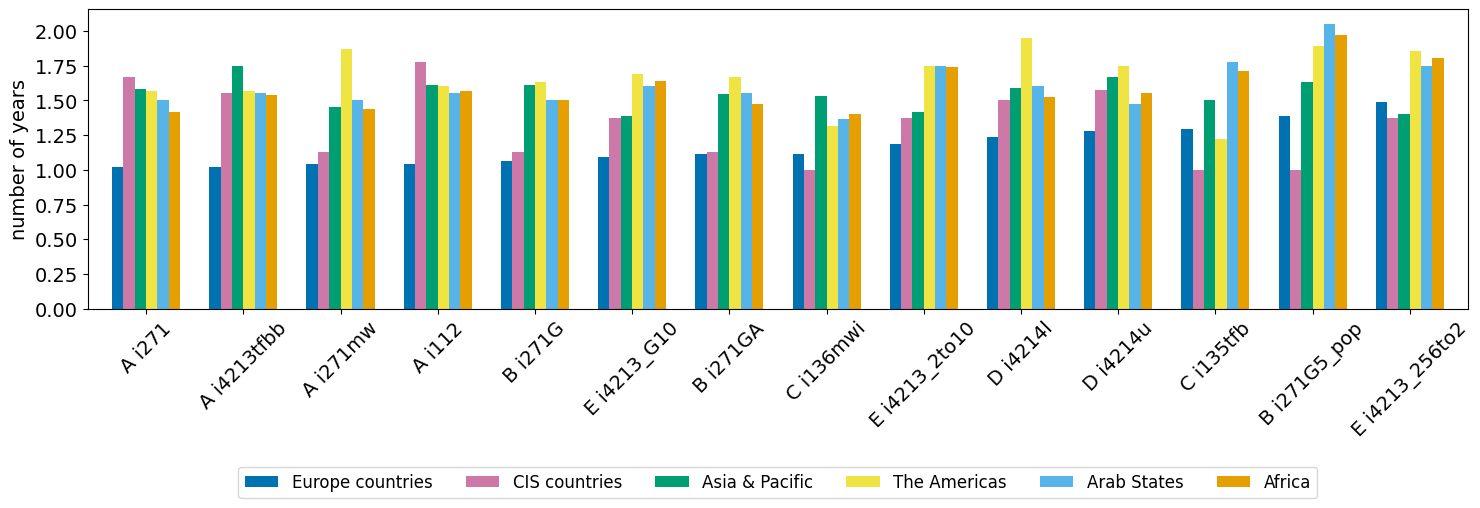

In [112]:
# Define your custom order
custom_order = ['Europe countries','CIS countries', 'Asia & Pacific', 'The Americas', 'Arab States', 'Africa']
#, 'Other Economies']

custom_colors = [
    '#0072B2',  # Blue
    '#CC79A7',  # Pink/Purple
    '#009E73',  # Green
    '#F0E442',  # Yellow
    '#56B4E9',  # Light Blue
    '#E69F00'  # Orange
    #'#696969'
    #'#999999',   # Grey
    ]

rename_dict = {
 'i112_timeliness': 'A i112',
 'i135tfb_timeliness': 'C i135tfb',
 'i136mwi_timeliness': 'C i136mwi',
 'i271_timeliness': 'A i271',
 'i271G_timeliness': 'B i271G',
 'i271G5_pop_timeliness': 'B i271G5_pop',
 'i271GA_timeliness': 'B i271GA',
 'i271mw_timeliness': 'A i271mw',
 'i4213_256to2_timeliness': 'E i4213_256to2',
 'i4213_2to10_timeliness': 'E i4213_2to10',
 'i4213_G10_timeliness': 'E i4213_G10',
 'i4213tfbb_timeliness': 'A i4213tfbb',
 'i4214l_timeliness': 'D i4214l',
 'i4214u_timeliness': 'D i4214u'
}

pivoted_t[['region_name','i112_timeliness',
       'i135tfb_timeliness', 'i136mwi_timeliness', 'i271_timeliness',
       'i271G_timeliness', 'i271G5_pop_timeliness', 'i271GA_timeliness',
       'i271mw_timeliness', 'i4213_256to2_timeliness',
       'i4213_2to10_timeliness', 'i4213_G10_timeliness',
       'i4213tfbb_timeliness', 'i4214l_timeliness', 'i4214u_timeliness']].rename(
     columns=rename_dict).groupby('region_name').mean(numeric_only=True).reindex(custom_order).T.sort_values(by='Europe countries', ascending=True).plot(kind='bar',
                                                  figsize=(15, 6),
                                                  color=custom_colors,
                                                  width=0.7)
#plt.title('Timeliness in 2024: time lag of latest available data point in number of years (available data only)')
plt.xlabel('')
plt.ylabel('number of years', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=7,
    fontsize=12
)

plt.tight_layout()
plt.show()

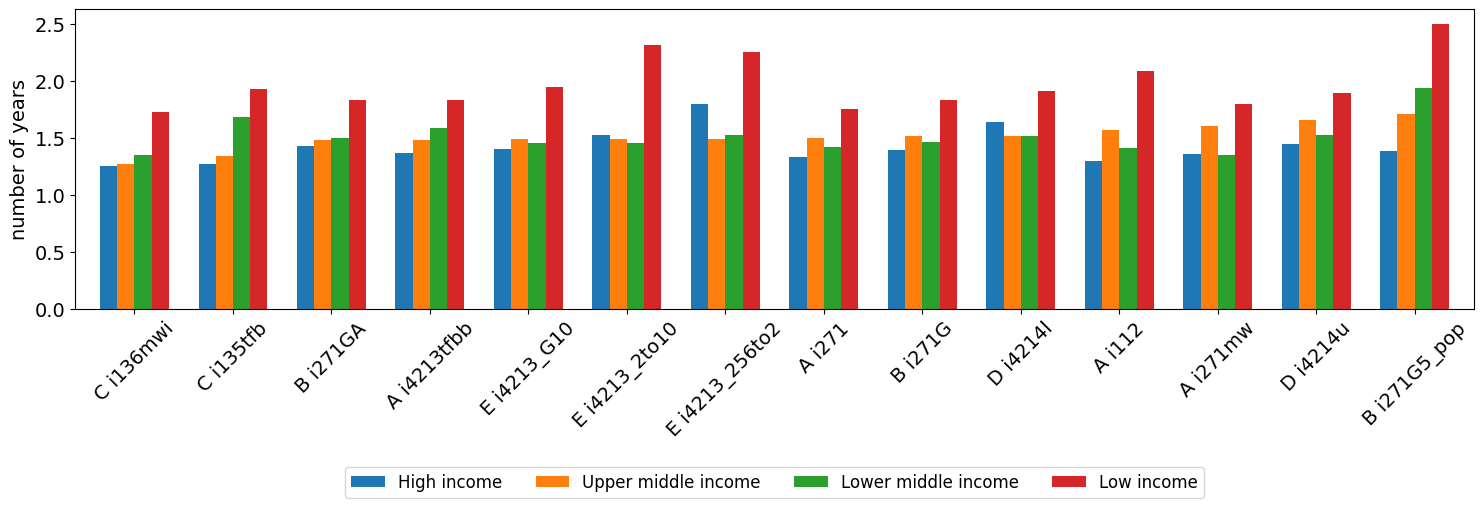

In [113]:
# Define your custom order
custom_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']
#, 'Other Economies']

rename_dict = {
 'i112_timeliness': 'A i112',
 'i135tfb_timeliness': 'C i135tfb',
 'i136mwi_timeliness': 'C i136mwi',
 'i271_timeliness': 'A i271',
 'i271G_timeliness': 'B i271G',
 'i271G5_pop_timeliness': 'B i271G5_pop',
 'i271GA_timeliness': 'B i271GA',
 'i271mw_timeliness': 'A i271mw',
 'i4213_256to2_timeliness': 'E i4213_256to2',
 'i4213_2to10_timeliness': 'E i4213_2to10',
 'i4213_G10_timeliness': 'E i4213_G10',
 'i4213tfbb_timeliness': 'A i4213tfbb',
 'i4214l_timeliness': 'D i4214l',
 'i4214u_timeliness': 'D i4214u'
}

pivoted_t[['WB_Income','i112_timeliness',
       'i135tfb_timeliness', 'i136mwi_timeliness', 'i271_timeliness',
       'i271G_timeliness', 'i271G5_pop_timeliness', 'i271GA_timeliness',
       'i271mw_timeliness', 'i4213_256to2_timeliness',
       'i4213_2to10_timeliness', 'i4213_G10_timeliness',
       'i4213tfbb_timeliness', 'i4214l_timeliness', 'i4214u_timeliness']].rename(
     columns=rename_dict).groupby('WB_Income').mean(numeric_only=True).reindex(custom_order).T.sort_values(by='Upper middle income', ascending=True).plot(kind='bar',
                                                  figsize=(15, 6),
                                                  #color=custom_colors,
                                                  width=0.7)
#plt.title('Timeliness in 2024: time lag of latest available data point in number of years (available data only)')
plt.xlabel('')
plt.ylabel('number of years', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=7,
    fontsize=12
)

plt.tight_layout()
plt.show()

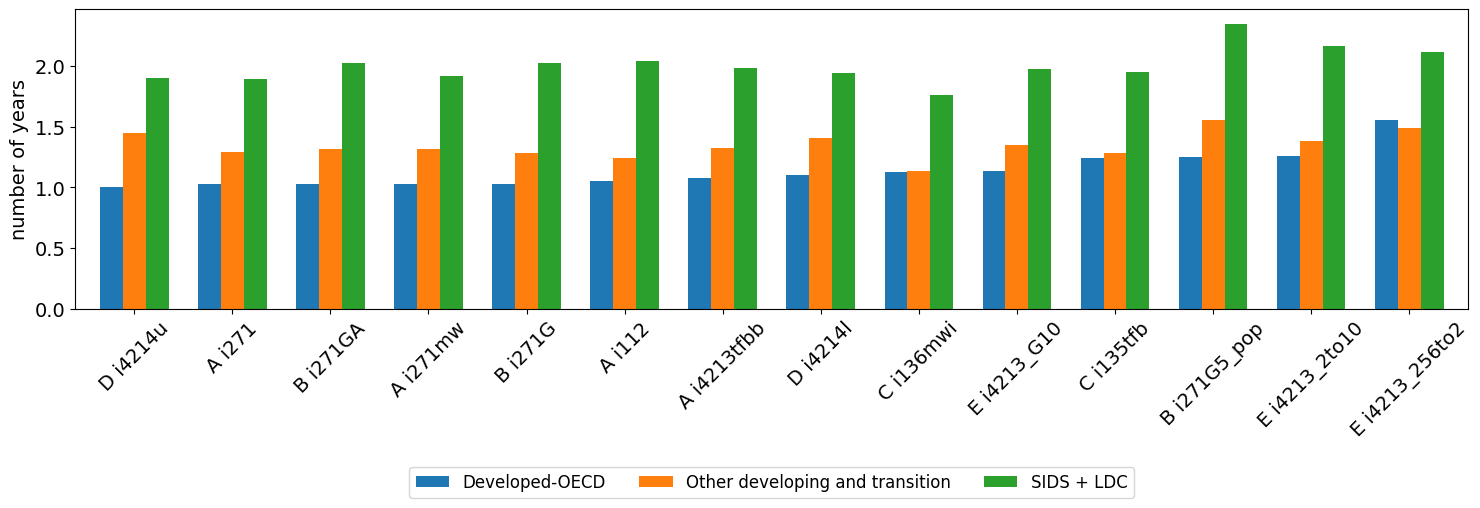

In [114]:
# Define your custom order
custom_order = ['Developed-OECD', 'Other developing and transition', 'SIDS + LDC']
#, 'Other Economies']

rename_dict = {
 'i112_timeliness': 'A i112',
 'i135tfb_timeliness': 'C i135tfb',
 'i136mwi_timeliness': 'C i136mwi',
 'i271_timeliness': 'A i271',
 'i271G_timeliness': 'B i271G',
 'i271G5_pop_timeliness': 'B i271G5_pop',
 'i271GA_timeliness': 'B i271GA',
 'i271mw_timeliness': 'A i271mw',
 'i4213_256to2_timeliness': 'E i4213_256to2',
 'i4213_2to10_timeliness': 'E i4213_2to10',
 'i4213_G10_timeliness': 'E i4213_G10',
 'i4213tfbb_timeliness': 'A i4213tfbb',
 'i4214l_timeliness': 'D i4214l',
 'i4214u_timeliness': 'D i4214u'
}

pivoted_t[['new_group','i112_timeliness',
       'i135tfb_timeliness', 'i136mwi_timeliness', 'i271_timeliness',
       'i271G_timeliness', 'i271G5_pop_timeliness', 'i271GA_timeliness',
       'i271mw_timeliness', 'i4213_256to2_timeliness',
       'i4213_2to10_timeliness', 'i4213_G10_timeliness',
       'i4213tfbb_timeliness', 'i4214l_timeliness', 'i4214u_timeliness']].rename(
     columns=rename_dict).groupby('new_group').mean(numeric_only=True).reindex(custom_order).T.sort_values(by='Developed-OECD', ascending=True).plot(kind='bar',
                                                  figsize=(15, 6),
                                                  #color=custom_colors,
                                                  width=0.7)
#plt.title('Timeliness in 2024: time lag of latest available data point in number of years (available data only)')
plt.xlabel('')
plt.ylabel('number of years', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=7,
    fontsize=12
)

plt.tight_layout()
plt.show()

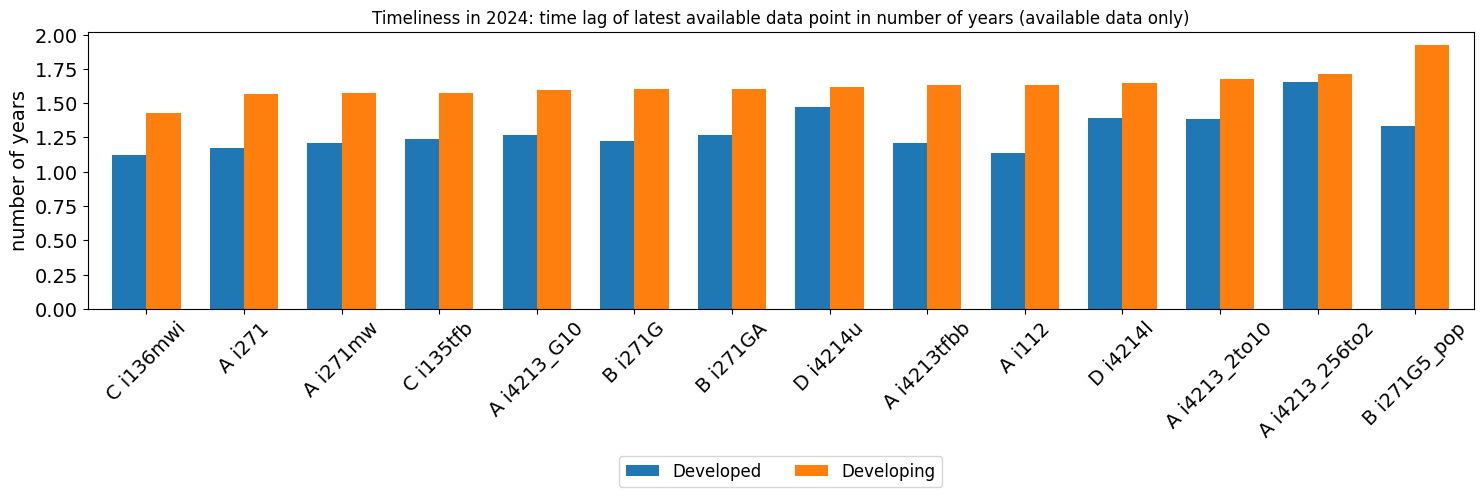

In [115]:
# Define your custom order
custom_order = ['Developed', 'Developing']
#, 'Other Economies']

rename_dict = {
 'i112_timeliness': 'A i112',
 'i135tfb_timeliness': 'C i135tfb',
 'i136mwi_timeliness': 'C i136mwi',
 'i271_timeliness': 'A i271',
 'i271G_timeliness': 'B i271G',
 'i271G5_pop_timeliness': 'B i271G5_pop',
 'i271GA_timeliness': 'B i271GA',
 'i271mw_timeliness': 'A i271mw',
 'i4213_256to2_timeliness': 'A i4213_256to2',
 'i4213_2to10_timeliness': 'A i4213_2to10',
 'i4213_G10_timeliness': 'A i4213_G10',
 'i4213tfbb_timeliness': 'A i4213tfbb',
 'i4214l_timeliness': 'D i4214l',
 'i4214u_timeliness': 'D i4214u'
}

pivoted_t[['CountryType','i112_timeliness',
       'i135tfb_timeliness', 'i136mwi_timeliness', 'i271_timeliness',
       'i271G_timeliness', 'i271G5_pop_timeliness', 'i271GA_timeliness',
       'i271mw_timeliness', 'i4213_256to2_timeliness',
       'i4213_2to10_timeliness', 'i4213_G10_timeliness',
       'i4213tfbb_timeliness', 'i4214l_timeliness', 'i4214u_timeliness']].rename(
     columns=rename_dict).groupby('CountryType').mean(numeric_only=True).reindex(custom_order).T.sort_values(by='Developing', ascending=True).plot(kind='bar',
                                                  figsize=(15, 6),
                                                  #color=custom_colors,
                                                  width=0.7)
plt.title('Timeliness in 2024: time lag of latest available data point in number of years (available data only)')
plt.xlabel('')
plt.ylabel('number of years', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=7,
    fontsize=12
)

plt.tight_layout()
plt.show()

## Charts for country profile

In [116]:
pivoted_t[pivoted_t.ShortName=='Madagascar'][['region_name','i112_timeliness',
       'i135tfb_timeliness', 'i136mwi_timeliness', 'i271_timeliness',
       'i271G_timeliness', 'i271G5_pop_timeliness', 'i271GA_timeliness',
       'i271mw_timeliness', 'i4213_256to2_timeliness',
       'i4213_2to10_timeliness', 'i4213_G10_timeliness',
       'i4213tfbb_timeliness', 'i4214l_timeliness', 'i4214u_timeliness']]

,region_name,i112_timeliness,i135tfb_timeliness,i136mwi_timeliness,i271_timeliness,i271G_timeliness,i271G5_pop_timeliness,i271GA_timeliness,i271mw_timeliness,i4213_256to2_timeliness,i4213_2to10_timeliness,i4213_G10_timeliness,i4213tfbb_timeliness,i4214l_timeliness,i4214u_timeliness
101,Africa,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0


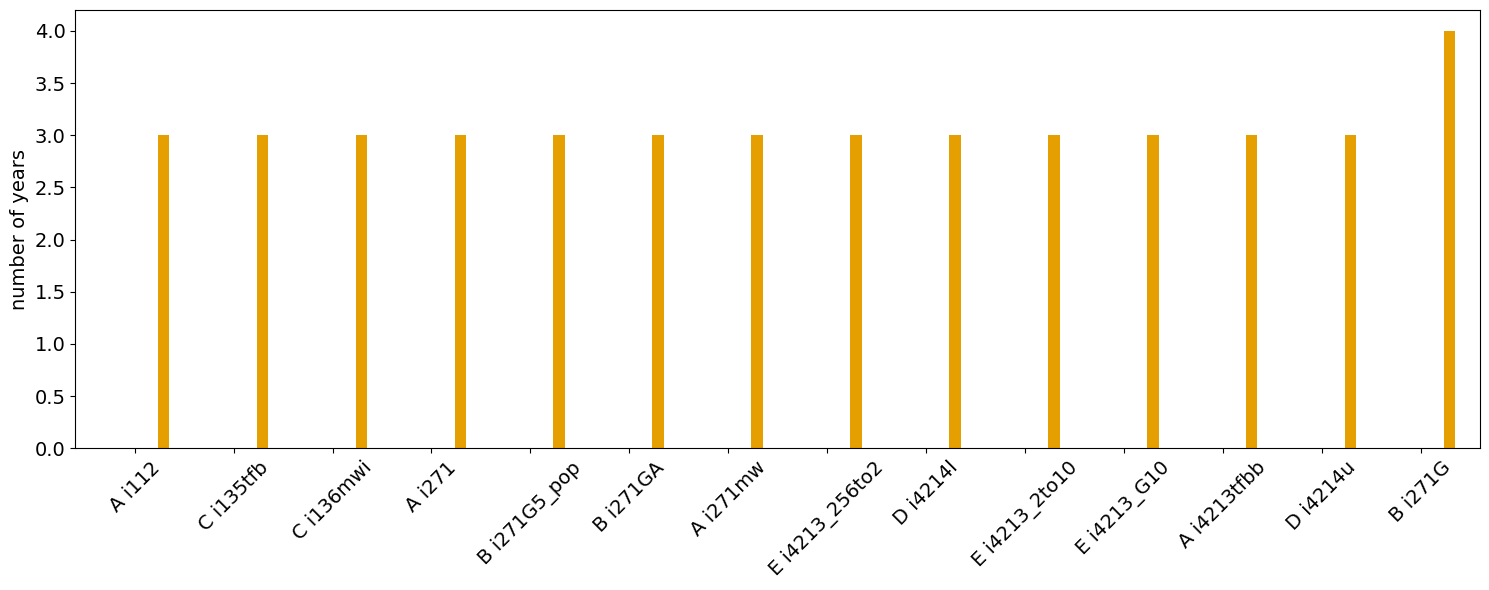

In [117]:
# Define your custom order
custom_order = ['Europe countries','CIS countries', 'Asia & Pacific', 'The Americas', 'Arab States', 'Africa']
#, 'Other Economies']

custom_colors = [
    '#0072B2',  # Blue
    '#CC79A7',  # Pink/Purple
    '#009E73',  # Green
    '#F0E442',  # Yellow
    '#56B4E9',  # Light Blue
    '#E69F00'  # Orange
    #'#696969'
    #'#999999',   # Grey
    ]

rename_dict = {
 'i112_timeliness': 'A i112',
 'i135tfb_timeliness': 'C i135tfb',
 'i136mwi_timeliness': 'C i136mwi',
 'i271_timeliness': 'A i271',
 'i271G_timeliness': 'B i271G',
 'i271G5_pop_timeliness': 'B i271G5_pop',
 'i271GA_timeliness': 'B i271GA',
 'i271mw_timeliness': 'A i271mw',
 'i4213_256to2_timeliness': 'E i4213_256to2',
 'i4213_2to10_timeliness': 'E i4213_2to10',
 'i4213_G10_timeliness': 'E i4213_G10',
 'i4213tfbb_timeliness': 'A i4213tfbb',
 'i4214l_timeliness': 'D i4214l',
 'i4214u_timeliness': 'D i4214u'
}

pivoted_t[pivoted_t.ShortName=='Madagascar'][['region_name','i112_timeliness',
       'i135tfb_timeliness', 'i136mwi_timeliness', 'i271_timeliness',
       'i271G_timeliness', 'i271G5_pop_timeliness', 'i271GA_timeliness',
       'i271mw_timeliness', 'i4213_256to2_timeliness',
       'i4213_2to10_timeliness', 'i4213_G10_timeliness',
       'i4213tfbb_timeliness', 'i4214l_timeliness', 'i4214u_timeliness']].rename(
     columns=rename_dict).groupby('region_name').mean(numeric_only=True).reindex(custom_order).T.sort_values(by='Africa', ascending=True).plot(kind='bar',
                                                  figsize=(15, 6),
                                                  color=custom_colors,
                                                  width=0.7)
#plt.title('Timeliness in 2024: time lag of latest available data point in number of years (available data only)')
plt.xlabel('')
plt.ylabel('number of years', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=7,
    fontsize=12
)
plt.legend().remove()

plt.tight_layout()
plt.show()

## Group-wise calculations for timeliness (by group of indicators)

Now group the data so we can report timeliness for the categories of indicators

In [118]:
wti_timeliness.head()

,ShortName,Code,region_name,CodeDesc,IsoCode,wti_group,new_group,CountryType,WB_Income,timeliness
0,Afghanistan,i112,Asia & Pacific,Fixed-telephone subscriptions,AFG,A. Contracting_records,SIDS + LDC,Developing,Low income,3
1,Afghanistan,i136mwi,Asia & Pacific,Mobile-broadband Internet traffic (within the ...,AFG,C. Operator_traffic,SIDS + LDC,Developing,Low income,3
2,Afghanistan,i271,Asia & Pacific,"Mobile-cellular telephone subscriptions, by po...",AFG,A. Contracting_records,SIDS + LDC,Developing,Low income,2
3,Afghanistan,i271G,Asia & Pacific,Percentage of the population covered by at lea...,AFG,B. Cell_tower_coverage,SIDS + LDC,Developing,Low income,3
4,Afghanistan,i271G5_pop,Asia & Pacific,Percentage of the population covered by at lea...,AFG,B. Cell_tower_coverage,SIDS + LDC,Developing,Low income,5


In [119]:
# Make calculations for the group of indicators - take the minimum per group

wti_timeliness.groupby(["ShortName", "region_name", "wti_group", "IsoCode", 'new_group', 'CountryType', 'WB_Income'], as_index=False)["timeliness"].min().head()

,ShortName,region_name,wti_group,IsoCode,new_group,CountryType,WB_Income,timeliness
0,Afghanistan,Asia & Pacific,A. Contracting_records,AFG,SIDS + LDC,Developing,Low income,2
1,Afghanistan,Asia & Pacific,B. Cell_tower_coverage,AFG,SIDS + LDC,Developing,Low income,3
2,Afghanistan,Asia & Pacific,C. Operator_traffic,AFG,SIDS + LDC,Developing,Low income,3
3,Afghanistan,Asia & Pacific,D. Operators_wholesale,AFG,SIDS + LDC,Developing,Low income,3
4,Albania,Europe countries,A. Contracting_records,ALB,Other developing and transition,Developed,Upper middle income,1


In [120]:
# check the range of timeliness
wti_timeliness.groupby(["ShortName", "region_name", "wti_group", "IsoCode", 'new_group', 'CountryType', 'WB_Income'], as_index=False)["timeliness"].min().timeliness.describe()

,timeliness
count,851.0
mean,1.465335
std,0.99984
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,5.0


In [121]:
wti_time_group = wti_timeliness.groupby(["ShortName", "region_name", "wti_group", "IsoCode", 'new_group', 'CountryType', 'WB_Income'], as_index=False)["timeliness"].min()

# the percentage column is only needed at the later stage when computing the sub-index


pivoted_t_group = wti_time_group.pivot(index=['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType', 'WB_Income'], columns='wti_group', values=['timeliness'])

# Pivot back my data so I can plot it
# Replace NaNs with 6 because the data must be older than 2025-2020 =5 years
# pivoted_t_group = pivoted_t_group.fillna(6)

# Flatten and rename the columns
pivoted_t_group.columns = [
    f"{indicator}_{suffix}"
    for suffix, indicator in pivoted_t_group.columns
]

pivoted_t_group.reset_index(inplace=True)

pivoted_t_group.head()

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,A. Contracting_records_timeliness,B. Cell_tower_coverage_timeliness,C. Operator_traffic_timeliness,D. Operators_wholesale_timeliness,E. Contracting_fixed_broadband_speed_timeliness
0,Afghanistan,Asia & Pacific,AFG,SIDS + LDC,Developing,Low income,2.0,3.0,3.0,3.0,NaN
1,Albania,Europe countries,ALB,Other developing and transition,Developed,Upper middle income,1.0,1.0,1.0,1.0,1.0
2,Algeria,Arab States,DZA,Other developing and transition,Developing,Lower middle income,1.0,1.0,1.0,1.0,1.0
3,Andorra,Europe countries,AND,Other developing and transition,Developed,High income,1.0,1.0,1.0,1.0,1.0
4,Angola,Africa,AGO,SIDS + LDC,Developing,Lower middle income,1.0,1.0,1.0,2.0,2.0


In [122]:
pivoted_t_group.columns

Index(['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income', 'A. Contracting_records_timeliness',
       'B. Cell_tower_coverage_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness',
       'E. Contracting_fixed_broadband_speed_timeliness'],
      dtype='object')

In [123]:
pivoted_t_group[['ShortName', 'region_name','A. Contracting_records_timeliness',
       'B. Cell_tower_coverage_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness',
       'E. Contracting_fixed_broadband_speed_timeliness']][pivoted_t_group.region_name== 'CIS countries']

,ShortName,region_name,A. Contracting_records_timeliness,B. Cell_tower_coverage_timeliness,C. Operator_traffic_timeliness,D. Operators_wholesale_timeliness,E. Contracting_fixed_broadband_speed_timeliness
6,Armenia,CIS countries,1.0,1.0,1.0,1.0,1.0
9,Azerbaijan,CIS countries,1.0,1.0,1.0,1.0,1.0
14,Belarus,CIS countries,1.0,1.0,1.0,1.0,1.0
86,Kazakhstan,CIS countries,1.0,1.0,1.0,1.0,1.0
91,Kyrgyzstan,CIS countries,1.0,1.0,1.0,1.0,1.0
140,Russian Federation,CIS countries,1.0,1.0,1.0,1.0,1.0
166,Tajikistan,CIS countries,1.0,1.0,NaN,NaN,NaN
174,Turkmenistan,CIS countries,4.0,NaN,NaN,5.0,4.0
182,Uzbekistan,CIS countries,1.0,1.0,1.0,1.0,1.0


In [124]:
pivoted_t_group[['A. Contracting_records_timeliness',
       'B. Cell_tower_coverage_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness',
       'E. Contracting_fixed_broadband_speed_timeliness']].describe()

,A. Contracting_records_timeliness,B. Cell_tower_coverage_timeliness,C. Operator_traffic_timeliness,D. Operators_wholesale_timeliness,E. Contracting_fixed_broadband_speed_timeliness
count,188.000000,186.000000,163.000000,142.000000,172.000000
mean,1.420213,1.478495,1.325153,1.619718,1.505814
std,0.958506,1.003814,0.800335,1.165292,1.051299
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,2.000000,1.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000


In [125]:
# these are the countries with the lowest timeliness values (5) per group of indicator, not accounting for missing values
pivoted_t_group[pivoted_t_group[['A. Contracting_records_timeliness',
       'B. Cell_tower_coverage_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness',
       'E. Contracting_fixed_broadband_speed_timeliness']].ge(5).any(axis=1)]

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,A. Contracting_records_timeliness,B. Cell_tower_coverage_timeliness,C. Operator_traffic_timeliness,D. Operators_wholesale_timeliness,E. Contracting_fixed_broadband_speed_timeliness
13,Barbados,The Americas,BRB,SIDS + LDC,Developing,High income,4.0,4.0,5.0,5.0,4.0
19,Bolivia (Plurinational State of),The Americas,BOL,Other developing and transition,Developing,Lower middle income,2.0,2.0,NaN,5.0,5.0
23,British Virgin Islands,Other Economies,VGB,SIDS + LDC,Developing,High income,2.0,5.0,NaN,NaN,NaN
68,Greenland,Other Economies,GRL,Other developing and transition,Developed,High income,5.0,5.0,NaN,NaN,5.0
92,Lao P.D.R.,Asia & Pacific,LAO,SIDS + LDC,Developing,Lower middle income,3.0,3.0,5.0,5.0,3.0
110,Micronesia,Asia & Pacific,FSM,SIDS + LDC,Developing,Lower middle income,5.0,4.0,NaN,NaN,NaN
142,Saint Kitts and Nevis,The Americas,KNA,SIDS + LDC,Developing,High income,3.0,4.0,NaN,5.0,4.0
144,Saint Vincent and the Grenadines,The Americas,VCT,SIDS + LDC,Developing,Upper middle income,1.0,1.0,2.0,NaN,5.0
152,Sierra Leone,Africa,SLE,SIDS + LDC,Developing,Low income,5.0,5.0,NaN,5.0,5.0
161,Sudan,Arab States,SDN,SIDS + LDC,Developing,Low income,4.0,4.0,NaN,5.0,5.0


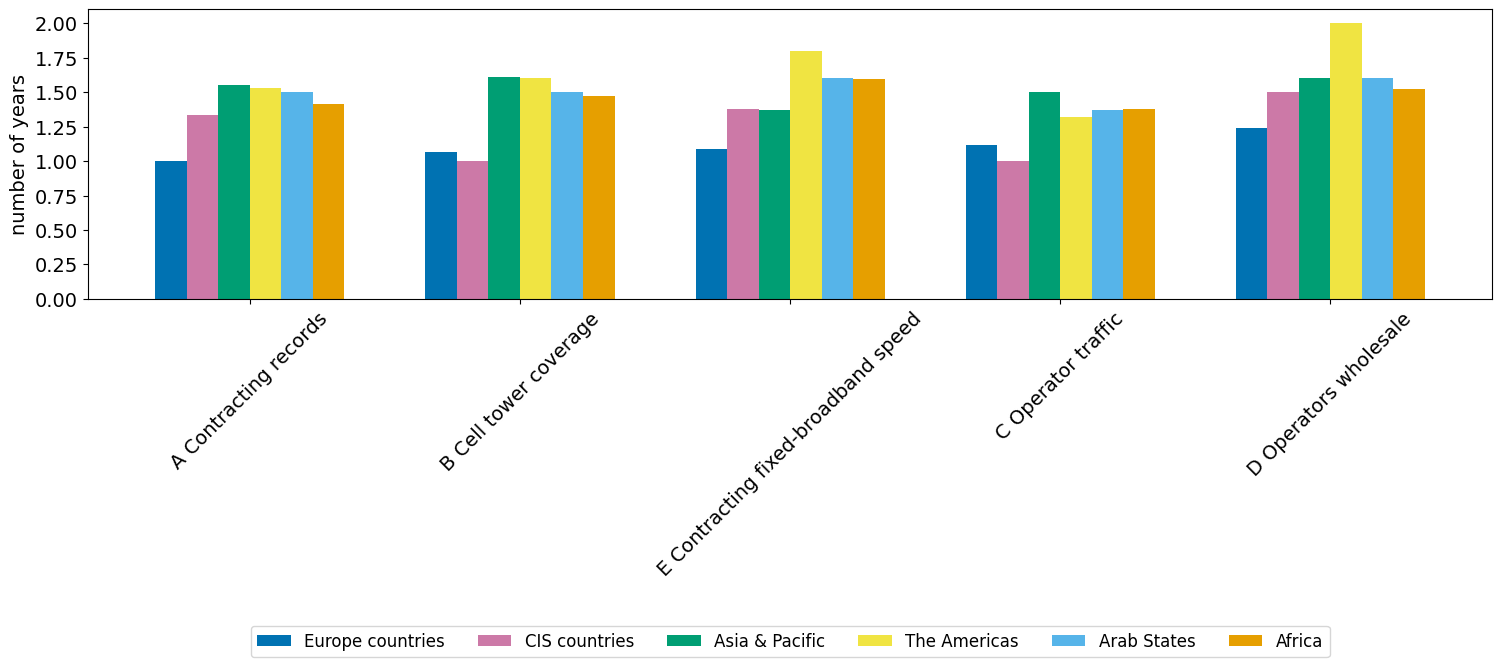

In [126]:
# Define your custom order
custom_order = ['Europe countries','CIS countries', 'Asia & Pacific', 'The Americas', 'Arab States', 'Africa']
#, 'Other Economies']

custom_colors = [
    '#0072B2',  # Blue
    '#CC79A7',  # Pink/Purple
    '#009E73',  # Green
    '#F0E442',  # Yellow
    '#56B4E9',  # Light Blue
    '#E69F00'  # Orange
    #'#696969'
    #'#999999',   # Grey
    ]

rename_dict = {
'B. Cell_tower_coverage_timeliness': "B Cell tower coverage",
'A. Contracting_records_timeliness':"A Contracting records",
'C. Operator_traffic_timeliness':"C Operator traffic",
'D. Operators_wholesale_timeliness':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_timeliness': "E Contracting fixed-broadband speed"
}

pivoted_t_group[['region_name','B. Cell_tower_coverage_timeliness',
       'A. Contracting_records_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness', 'E. Contracting_fixed_broadband_speed_timeliness']].rename(
     columns=rename_dict).groupby('region_name').mean(numeric_only=True).reindex(custom_order).T.sort_values(by='Europe countries', ascending=True).plot(kind='bar',
                                                  figsize=(15, 6),
                                                  color=custom_colors,
                                                  width=0.7)
#plt.title('Timeliness in 2025: time lag of latest available data point in number of years (available data only)')
plt.xlabel('')
plt.ylabel('number of years', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

# adjust bottom margin to make space for legend
plt.subplots_adjust(bottom=0.6)  # increase bottom space

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -1.1),
    ncol=7,
    fontsize=12
)

plt.tight_layout()
plt.show()

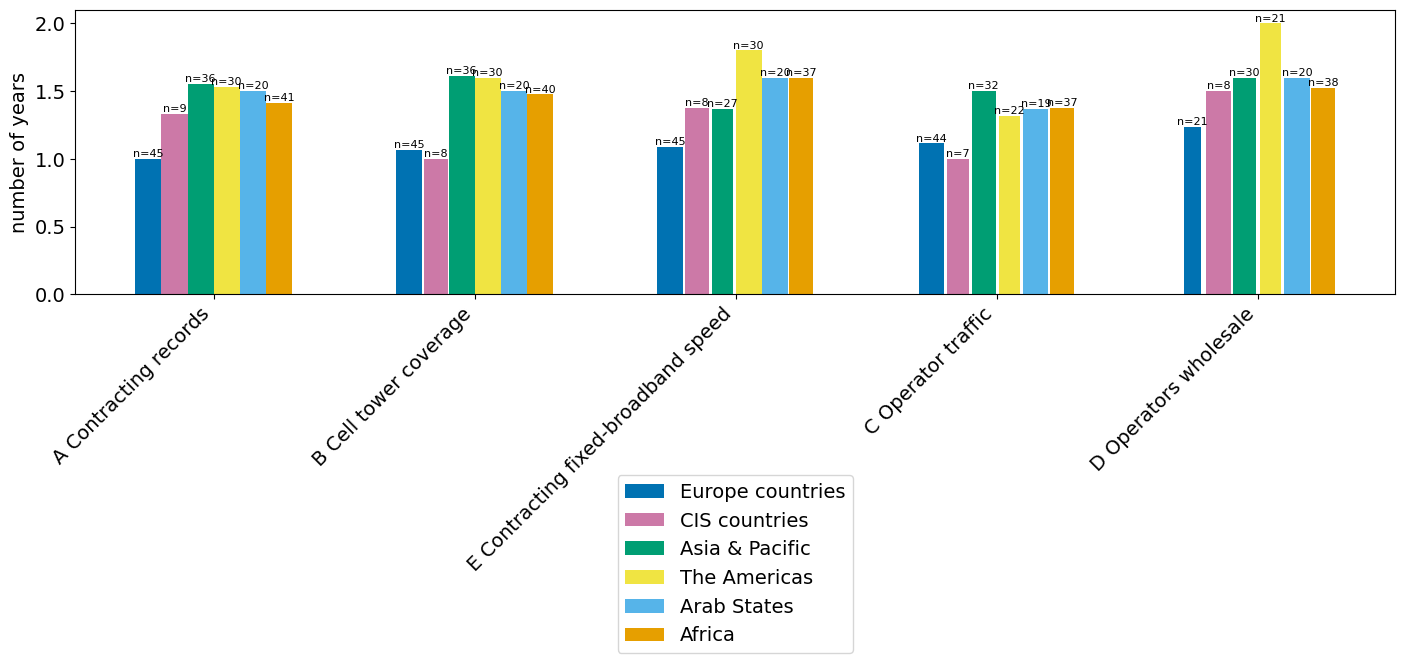

In [127]:
from matplotlib.patches import Patch

# Define your custom order
custom_order = ['Europe countries','CIS countries', 'Asia & Pacific', 'The Americas', 'Arab States', 'Africa']
#, 'Other Economies']

custom_colors = [
    '#0072B2',  # Blue
    '#CC79A7',  # Pink/Purple
    '#009E73',  # Green
    '#F0E442',  # Yellow
    '#56B4E9',  # Light Blue
    '#E69F00'  # Orange
    ]

rename_dict = {
'B. Cell_tower_coverage_timeliness': "B Cell tower coverage",
'A. Contracting_records_timeliness':"A Contracting records",
'C. Operator_traffic_timeliness':"C Operator traffic",
'D. Operators_wholesale_timeliness':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_timeliness': "E Contracting fixed-broadband speed"
}

subset = pivoted_t_group[['region_name','B. Cell_tower_coverage_timeliness',
       'A. Contracting_records_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness', 'E. Contracting_fixed_broadband_speed_timeliness']].rename(
     columns=rename_dict)

# Calculate means and counts
means = subset.groupby('region_name').mean(numeric_only=True).T
counts = subset.groupby('region_name').count().T

# Sort by Europe countries
means_sorted = means.sort_values(by='Europe countries', ascending=True)[custom_order]
counts_sorted = counts.loc[means_sorted.index][custom_order]

# Set width factor range
min_width_factor = 0.3
max_width_factor = 1.0

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot each region separately to control width
x = np.arange(len(means_sorted.index))
base_width = 0.6 / len(custom_order)

for i, region in enumerate(custom_order):
    # Calculate width for each bar WITHIN THIS GROUP
    group_max_count = counts_sorted[region].max()

    # Normalize within the group
    width_factors = counts_sorted[region] / group_max_count * (max_width_factor - min_width_factor) + min_width_factor

    # Plot bars with individual widths
    for j, (indicator, value) in enumerate(means_sorted[region].items()):
        bar_width = base_width * width_factors.iloc[j]
        bar_x = x[j] + i * base_width - (len(custom_order) - 1) * base_width / 2

        ax.bar(
            bar_x,
            value,
            bar_width,
            color=custom_colors[i]
        )

        # Add text label on top of bar
        count = int(counts_sorted[region].iloc[j])
        if count > 0:
            ax.text(
                bar_x,
                value,
                f'n={count}',
                ha='center',
                va='bottom',
                fontsize=8,
                rotation=0
            )

ax.set_xlabel('', fontsize=14)
ax.set_ylabel('number of years', fontsize=14)
#plt.title('Timeliness in 2025: time lag of latest available data point in number of years (available data only)')
ax.set_xticks(x)
ax.set_xticklabels(means_sorted.index, rotation=45, fontsize=14, ha='right')
ax.tick_params(axis='y', labelsize=14)

# Create custom legend
legend_handles = [Patch(facecolor=custom_colors[i], label=region)
                  for i, region in enumerate(custom_order)]

plt.subplots_adjust(bottom=0.7)
plt.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.6),
    ncol=1,
    fontsize=14
)

plt.tight_layout()
plt.show()



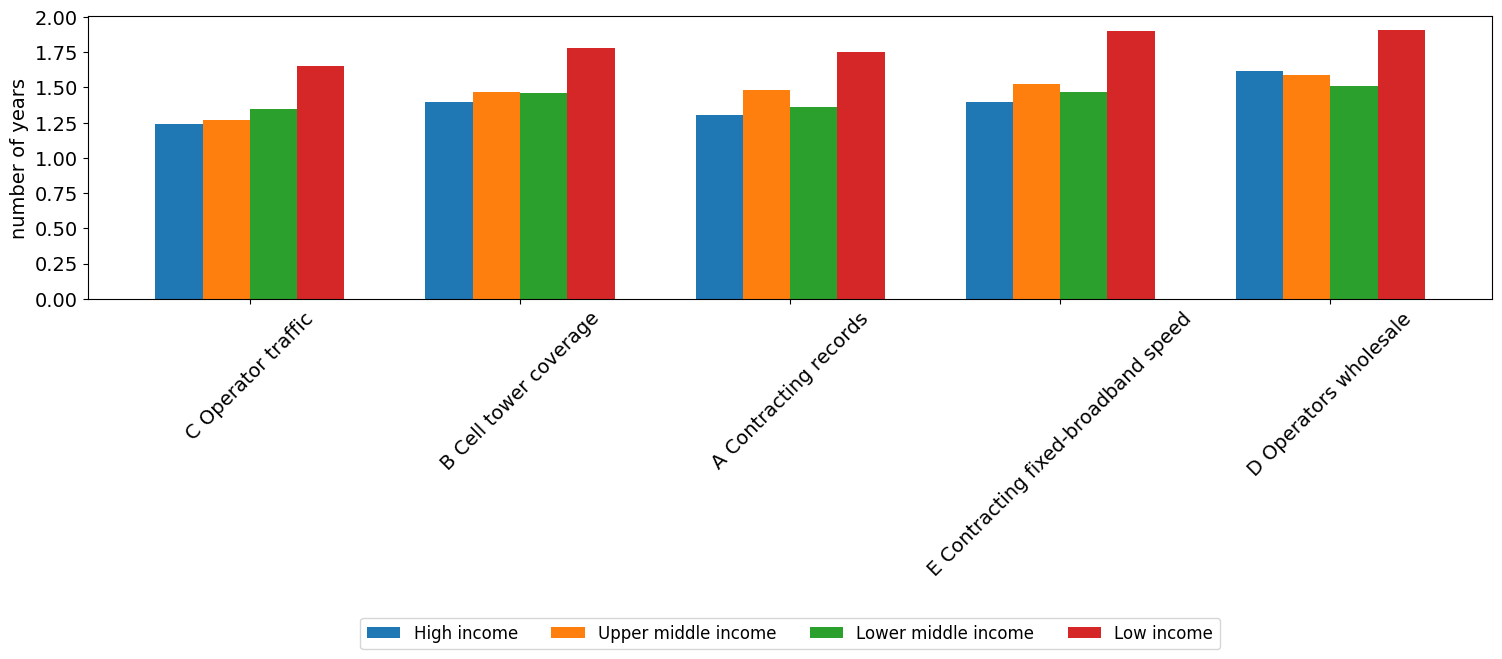

In [128]:
# Define your custom order
custom_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']
#, 'Other Economies']

rename_dict = {
'B. Cell_tower_coverage_timeliness': "B Cell tower coverage",
'A. Contracting_records_timeliness':"A Contracting records",
'C. Operator_traffic_timeliness':"C Operator traffic",
'D. Operators_wholesale_timeliness':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_timeliness': "E Contracting fixed-broadband speed"
}

pivoted_t_group[['WB_Income','B. Cell_tower_coverage_timeliness',
       'A. Contracting_records_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness', 'E. Contracting_fixed_broadband_speed_timeliness']].rename(
     columns=rename_dict).groupby('WB_Income').mean(numeric_only=True).reindex(custom_order).T.sort_values(by='Upper middle income', ascending=True).plot(kind='bar',
                                                  figsize=(15, 6),
                                                  #color=custom_colors,
                                                  width=0.7)
#plt.title('Timeliness in 2025: time lag of latest available data point in number of years (available data only)')
plt.xlabel('')
plt.ylabel('number of years', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

# adjust bottom margin to make space for legend
plt.subplots_adjust(bottom=0.6)  # increase bottom space

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -1.1),
    ncol=7,
    fontsize=12
)

plt.tight_layout()
plt.show()

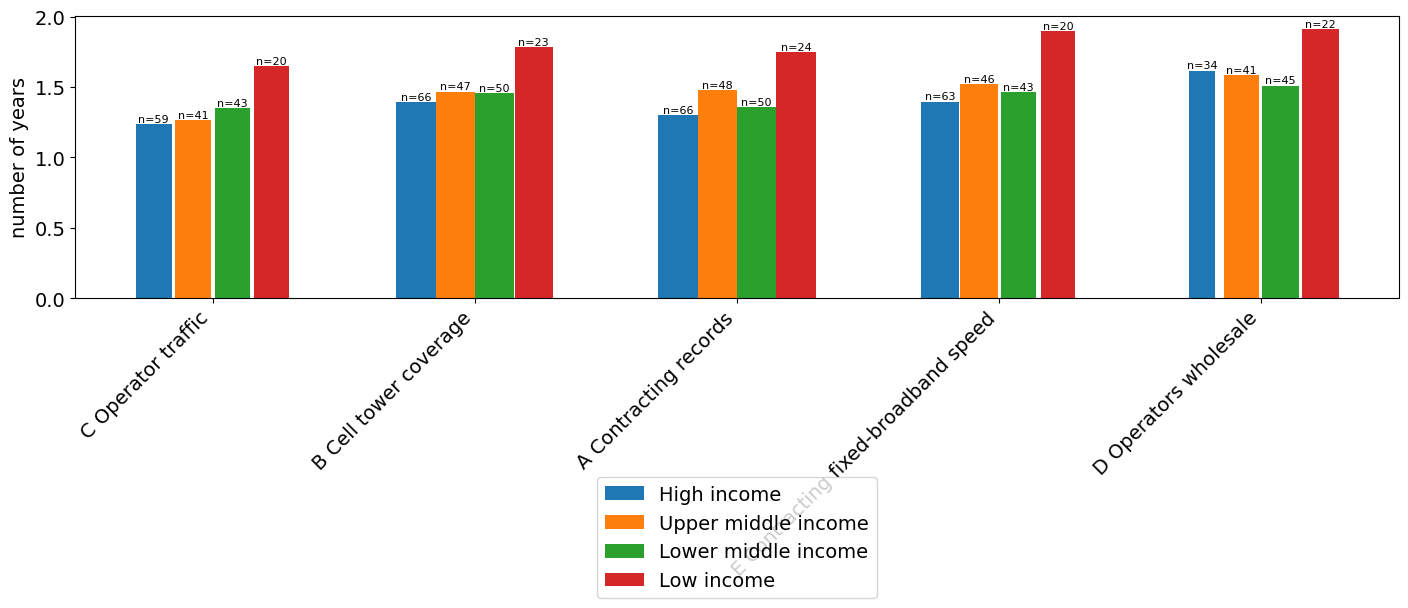

In [129]:
from matplotlib.patches import Patch

# Define your custom order
custom_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']
#, 'Other Economies']

rename_dict = {
'B. Cell_tower_coverage_timeliness': "B Cell tower coverage",
'A. Contracting_records_timeliness':"A Contracting records",
'C. Operator_traffic_timeliness':"C Operator traffic",
'D. Operators_wholesale_timeliness':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_timeliness': "E Contracting fixed-broadband speed"
}

custom_colors = ['#1f77b4',  # Blue
'#ff7f0e' , # Orange
'#2ca02c',  # Green
'#d62728'  # Red
]

subset = pivoted_t_group[['WB_Income','B. Cell_tower_coverage_timeliness',
       'A. Contracting_records_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness', 'E. Contracting_fixed_broadband_speed_timeliness']].rename(
     columns=rename_dict)

# Calculate means and counts
means = subset.groupby('WB_Income').mean(numeric_only=True).T
counts = subset.groupby('WB_Income').count().T

# Sort by Europe countries
means_sorted = means.sort_values(by='Upper middle income', ascending=True)[custom_order]
counts_sorted = counts.loc[means_sorted.index][custom_order]

# Set width factor range
min_width_factor = 0.3
max_width_factor = 1.0

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot each region separately to control width
x = np.arange(len(means_sorted.index))
base_width = 0.6 / len(custom_order)

for i, region in enumerate(custom_order):
    # Calculate width for each bar WITHIN THIS GROUP
    group_max_count = counts_sorted[region].max()

    # Normalize within the group
    width_factors = counts_sorted[region] / group_max_count * (max_width_factor - min_width_factor) + min_width_factor

    # Plot bars with individual widths
    for j, (indicator, value) in enumerate(means_sorted[region].items()):
        bar_width = base_width * width_factors.iloc[j]
        bar_x = x[j] + i * base_width - (len(custom_order) - 1) * base_width / 2

        ax.bar(
            bar_x,
            value,
            bar_width,
            color=custom_colors[i]
        )

        # Add text label on top of bar
        count = int(counts_sorted[region].iloc[j])
        if count > 0:
            ax.text(
                bar_x,
                value,
                f'n={count}',
                ha='center',
                va='bottom',
                fontsize=8,
                rotation=0
            )

ax.set_xlabel('', fontsize=14)
ax.set_ylabel('number of years', fontsize=14)
#plt.title('Timeliness in 2025: time lag of latest available data point in number of years (available data only)')
ax.set_xticks(x)
ax.set_xticklabels(means_sorted.index, rotation=45, fontsize=14, ha='right')
ax.tick_params(axis='y', labelsize=14)

# Create custom legend
legend_handles = [Patch(facecolor=custom_colors[i], label=region)
                  for i, region in enumerate(custom_order)] #

plt.subplots_adjust(bottom=0.7)
plt.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.6),
    ncol=1,
    fontsize=14
)

plt.tight_layout()
plt.show()



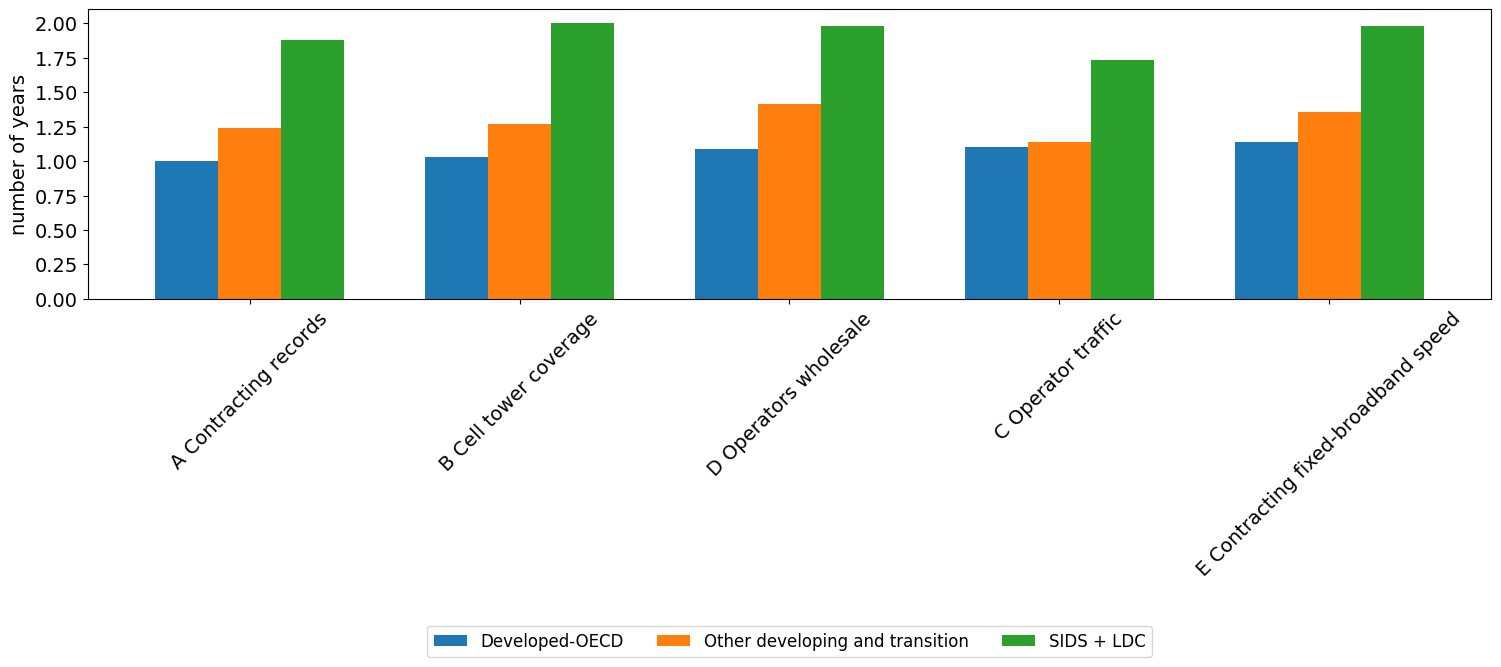

In [130]:
# Define your custom order
custom_order = ['Developed-OECD', 'Other developing and transition', 'SIDS + LDC']
#, 'Other Economies']

rename_dict = {
'B. Cell_tower_coverage_timeliness': "B Cell tower coverage",
'A. Contracting_records_timeliness':"A Contracting records",
'C. Operator_traffic_timeliness':"C Operator traffic",
'D. Operators_wholesale_timeliness':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_timeliness': "E Contracting fixed-broadband speed"
}

pivoted_t_group[['new_group','B. Cell_tower_coverage_timeliness',
       'A. Contracting_records_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness', 'E. Contracting_fixed_broadband_speed_timeliness']].rename(
     columns=rename_dict).groupby('new_group').mean(numeric_only=True).reindex(custom_order).T.sort_values(by='Developed-OECD', ascending=True).plot(kind='bar',
                                                  figsize=(15, 6),
                                                  #color=custom_colors,
                                                  width=0.7)
#plt.title('Timeliness in 2025: time lag of latest available data point in number of years (available data only)')
plt.xlabel('')
plt.ylabel('number of years', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

# adjust bottom margin to make space for legend
plt.subplots_adjust(bottom=0.6)  # increase bottom space

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -1.1),
    ncol=7,
    fontsize=12
)

plt.tight_layout()
plt.show()

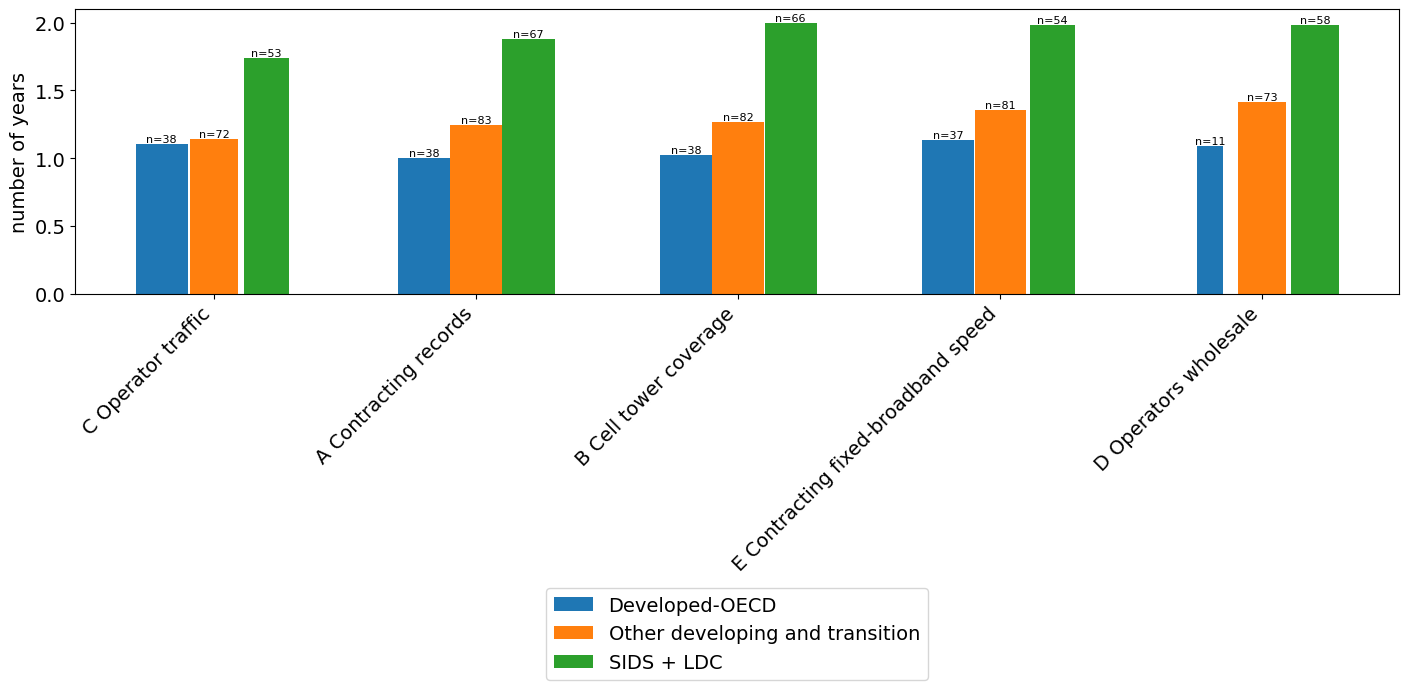

In [131]:
from matplotlib.patches import Patch

# Define your custom order
custom_order = ['Developed-OECD', 'Other developing and transition', 'SIDS + LDC']
#, 'Other Economies']

rename_dict = {
'B. Cell_tower_coverage_timeliness': "B Cell tower coverage",
'A. Contracting_records_timeliness':"A Contracting records",
'C. Operator_traffic_timeliness':"C Operator traffic",
'D. Operators_wholesale_timeliness':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_timeliness': "E Contracting fixed-broadband speed"
}

custom_colors = ['#1f77b4',  # Blue
'#ff7f0e' , # Orange
'#2ca02c',  # Green
'#d62728'  # Red
]

subset = pivoted_t_group[['new_group','B. Cell_tower_coverage_timeliness',
       'A. Contracting_records_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness', 'E. Contracting_fixed_broadband_speed_timeliness']].rename(
     columns=rename_dict)

# Calculate means and counts
means = subset.groupby('new_group').mean(numeric_only=True).T
counts = subset.groupby('new_group').count().T

# Sort by Europe countries
means_sorted = means.sort_values(by='Other developing and transition', ascending=True)[custom_order]
counts_sorted = counts.loc[means_sorted.index][custom_order]

# Set width factor range
min_width_factor = 0.3
max_width_factor = 1.0

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot each region separately to control width
x = np.arange(len(means_sorted.index))
base_width = 0.6 / len(custom_order)

for i, region in enumerate(custom_order):
    # Calculate width for each bar WITHIN THIS GROUP
    group_max_count = counts_sorted[region].max()

    # Normalize within the group
    width_factors = counts_sorted[region] / group_max_count * (max_width_factor - min_width_factor) + min_width_factor

    # Plot bars with individual widths
    for j, (indicator, value) in enumerate(means_sorted[region].items()):
        bar_width = base_width * width_factors.iloc[j]
        bar_x = x[j] + i * base_width - (len(custom_order) - 1) * base_width / 2

        ax.bar(
            bar_x,
            value,
            bar_width,
            color=custom_colors[i]
        )

        # Add text label on top of bar
        count = int(counts_sorted[region].iloc[j])
        if count > 0:
            ax.text(
                bar_x,
                value,
                f'n={count}',
                ha='center',
                va='bottom',
                fontsize=8,
                rotation=0
            )

ax.set_xlabel('', fontsize=14)
ax.set_ylabel('number of years', fontsize=14)
#plt.title('Timeliness in 2025: time lag of latest available data point in number of years (available data only)')
ax.set_xticks(x)
ax.set_xticklabels(means_sorted.index, rotation=45, fontsize=14, ha='right')
ax.tick_params(axis='y', labelsize=14)

# Create custom legend
legend_handles = [Patch(facecolor=custom_colors[i], label=region)
                  for i, region in enumerate(custom_order)] #

plt.subplots_adjust(bottom=0.7)
plt.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -1.0),
    ncol=1,
    fontsize=14
)

plt.tight_layout()
plt.show()



In [132]:
# for oecd countries, the only data available is the one below and timeliness averages to 0⁄
wti_timeliness[(wti_timeliness.new_group=='Developed-OECD') & (wti_timeliness.wti_group=='D. Operators_wholesale')]

,ShortName,Code,region_name,CodeDesc,IsoCode,wti_group,new_group,CountryType,WB_Income,timeliness
430,Chile,i4214u,The Americas,"International bandwidth usage, in Mbit/s",CHL,D. Operators_wholesale,Developed-OECD,Developing,High income,1
457,Colombia,i4214l,The Americas,"Lit/equipped international bandwidth capacity,...",COL,D. Operators_wholesale,Developed-OECD,Developing,Upper middle income,1
458,Colombia,i4214u,The Americas,"International bandwidth usage, in Mbit/s",COL,D. Operators_wholesale,Developed-OECD,Developing,Upper middle income,1
498,Costa Rica,i4214l,The Americas,"Lit/equipped international bandwidth capacity,...",CRI,D. Operators_wholesale,Developed-OECD,Developing,Upper middle income,2
859,Greece,i4214l,Europe countries,"Lit/equipped international bandwidth capacity,...",GRC,D. Operators_wholesale,Developed-OECD,Developed,High income,1
860,Greece,i4214u,Europe countries,"International bandwidth usage, in Mbit/s",GRC,D. Operators_wholesale,Developed-OECD,Developed,High income,1
960,Iceland,i4214l,Europe countries,"Lit/equipped international bandwidth capacity,...",ISL,D. Operators_wholesale,Developed-OECD,Developed,High income,1
961,Iceland,i4214u,Europe countries,"International bandwidth usage, in Mbit/s",ISL,D. Operators_wholesale,Developed-OECD,Developed,High income,1
1145,Korea (Rep. of),i4214l,Asia & Pacific,"Lit/equipped international bandwidth capacity,...",KOR,D. Operators_wholesale,Developed-OECD,Developing,High income,1
1253,Lithuania,i4214l,Europe countries,"Lit/equipped international bandwidth capacity,...",LTU,D. Operators_wholesale,Developed-OECD,Developed,High income,1


In [133]:
pivoted_t[pivoted_t.ShortName=='Afghanistan']

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,i112_timeliness,i135tfb_timeliness,i136mwi_timeliness,i271_timeliness,...,i271G5_pop_timeliness,i271GA_timeliness,i271mw_timeliness,i4213_256to2_timeliness,i4213_2to10_timeliness,i4213_G10_timeliness,i4213tfbb_timeliness,i4214l_timeliness,i4214u_timeliness,timeliness
0,Afghanistan,Asia & Pacific,AFG,SIDS + LDC,Developing,Low income,3.0,NaN,3.0,2.0,...,5.0,3.0,3.0,NaN,NaN,NaN,3.0,3.0,3.0,3.1


In [134]:
wti_timeliness[wti_timeliness.ShortName=='Afghanistan']

,ShortName,Code,region_name,CodeDesc,IsoCode,wti_group,new_group,CountryType,WB_Income,timeliness
0,Afghanistan,i112,Asia & Pacific,Fixed-telephone subscriptions,AFG,A. Contracting_records,SIDS + LDC,Developing,Low income,3
1,Afghanistan,i136mwi,Asia & Pacific,Mobile-broadband Internet traffic (within the ...,AFG,C. Operator_traffic,SIDS + LDC,Developing,Low income,3
2,Afghanistan,i271,Asia & Pacific,"Mobile-cellular telephone subscriptions, by po...",AFG,A. Contracting_records,SIDS + LDC,Developing,Low income,2
3,Afghanistan,i271G,Asia & Pacific,Percentage of the population covered by at lea...,AFG,B. Cell_tower_coverage,SIDS + LDC,Developing,Low income,3
4,Afghanistan,i271G5_pop,Asia & Pacific,Percentage of the population covered by at lea...,AFG,B. Cell_tower_coverage,SIDS + LDC,Developing,Low income,5
5,Afghanistan,i271GA,Asia & Pacific,Percentage of the population covered by at lea...,AFG,B. Cell_tower_coverage,SIDS + LDC,Developing,Low income,3
6,Afghanistan,i271mw,Asia & Pacific,Active mobile-broadband subscriptions,AFG,A. Contracting_records,SIDS + LDC,Developing,Low income,3
7,Afghanistan,i4213tfbb,Asia & Pacific,Fixed-broadband subscriptions,AFG,A. Contracting_records,SIDS + LDC,Developing,Low income,3
8,Afghanistan,i4214l,Asia & Pacific,"Lit/equipped international bandwidth capacity,...",AFG,D. Operators_wholesale,SIDS + LDC,Developing,Low income,3
9,Afghanistan,i4214u,Asia & Pacific,"International bandwidth usage, in Mbit/s",AFG,D. Operators_wholesale,SIDS + LDC,Developing,Low income,3


In [135]:
wti_counts[wti_counts.ShortName=='Afghanistan']

,ShortName,Code,region_name,CodeDesc,wti_group,IsoCode,new_group,CountryType,WB_Income,5Y,5Y_p
0,Afghanistan,i112,Asia & Pacific,Fixed-telephone subscriptions,A. Contracting_records,AFG,SIDS + LDC,Developing,Low income,3,60.0
1,Afghanistan,i136mwi,Asia & Pacific,Mobile-broadband Internet traffic (within the ...,C. Operator_traffic,AFG,SIDS + LDC,Developing,Low income,2,40.0
2,Afghanistan,i271,Asia & Pacific,"Mobile-cellular telephone subscriptions, by po...",A. Contracting_records,AFG,SIDS + LDC,Developing,Low income,4,80.0
3,Afghanistan,i271G,Asia & Pacific,Percentage of the population covered by at lea...,B. Cell_tower_coverage,AFG,SIDS + LDC,Developing,Low income,3,60.0
4,Afghanistan,i271G5_pop,Asia & Pacific,Percentage of the population covered by at lea...,B. Cell_tower_coverage,AFG,SIDS + LDC,Developing,Low income,1,20.0
5,Afghanistan,i271GA,Asia & Pacific,Percentage of the population covered by at lea...,B. Cell_tower_coverage,AFG,SIDS + LDC,Developing,Low income,3,60.0
6,Afghanistan,i271mw,Asia & Pacific,Active mobile-broadband subscriptions,A. Contracting_records,AFG,SIDS + LDC,Developing,Low income,3,60.0
7,Afghanistan,i4213tfbb,Asia & Pacific,Fixed-broadband subscriptions,A. Contracting_records,AFG,SIDS + LDC,Developing,Low income,3,60.0
8,Afghanistan,i4214l,Asia & Pacific,"Lit/equipped international bandwidth capacity,...",D. Operators_wholesale,AFG,SIDS + LDC,Developing,Low income,2,40.0
9,Afghanistan,i4214u,Asia & Pacific,"International bandwidth usage, in Mbit/s",D. Operators_wholesale,AFG,SIDS + LDC,Developing,Low income,2,40.0


In [136]:
wti[wti.ShortName=='Afghanistan']

,region_name,DataYear,Code,CodeDesc,wti_group,IsoCode,ShortName,LDC,LLDC,SIDS,WB_Income,OECD_member,new_group,CountryType,timeliness
0,Asia & Pacific,2021,i112,Fixed-telephone subscriptions,A. Contracting_records,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing,5
1,Asia & Pacific,2021,i271,"Mobile-cellular telephone subscriptions, by po...",A. Contracting_records,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing,5
2,Asia & Pacific,2021,i271G,Percentage of the population covered by at lea...,B. Cell_tower_coverage,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing,5
3,Asia & Pacific,2021,i271G5_pop,Percentage of the population covered by at lea...,B. Cell_tower_coverage,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing,5
4,Asia & Pacific,2021,i271GA,Percentage of the population covered by at lea...,B. Cell_tower_coverage,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing,5
5,Asia & Pacific,2021,i271mw,Active mobile-broadband subscriptions,A. Contracting_records,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing,5
6,Asia & Pacific,2021,i4213tfbb,Fixed-broadband subscriptions,A. Contracting_records,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing,5
7,Asia & Pacific,2022,i112,Fixed-telephone subscriptions,A. Contracting_records,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing,4
8,Asia & Pacific,2022,i136mwi,Mobile-broadband Internet traffic (within the ...,C. Operator_traffic,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing,4
9,Asia & Pacific,2022,i271,"Mobile-cellular telephone subscriptions, by po...",A. Contracting_records,AFG,Afghanistan,LDC,LLDC,NaN,Low income,NaN,SIDS + LDC,Developing,4


## Charts for country profile

In [137]:
pivoted_t_group[pivoted_t_group.ShortName=='Madagascar'][['region_name','B. Cell_tower_coverage_timeliness',
       'A. Contracting_records_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness', 'E. Contracting_fixed_broadband_speed_timeliness']]

,region_name,B. Cell_tower_coverage_timeliness,A. Contracting_records_timeliness,C. Operator_traffic_timeliness,D. Operators_wholesale_timeliness,E. Contracting_fixed_broadband_speed_timeliness
101,Africa,3.0,3.0,3.0,3.0,3.0


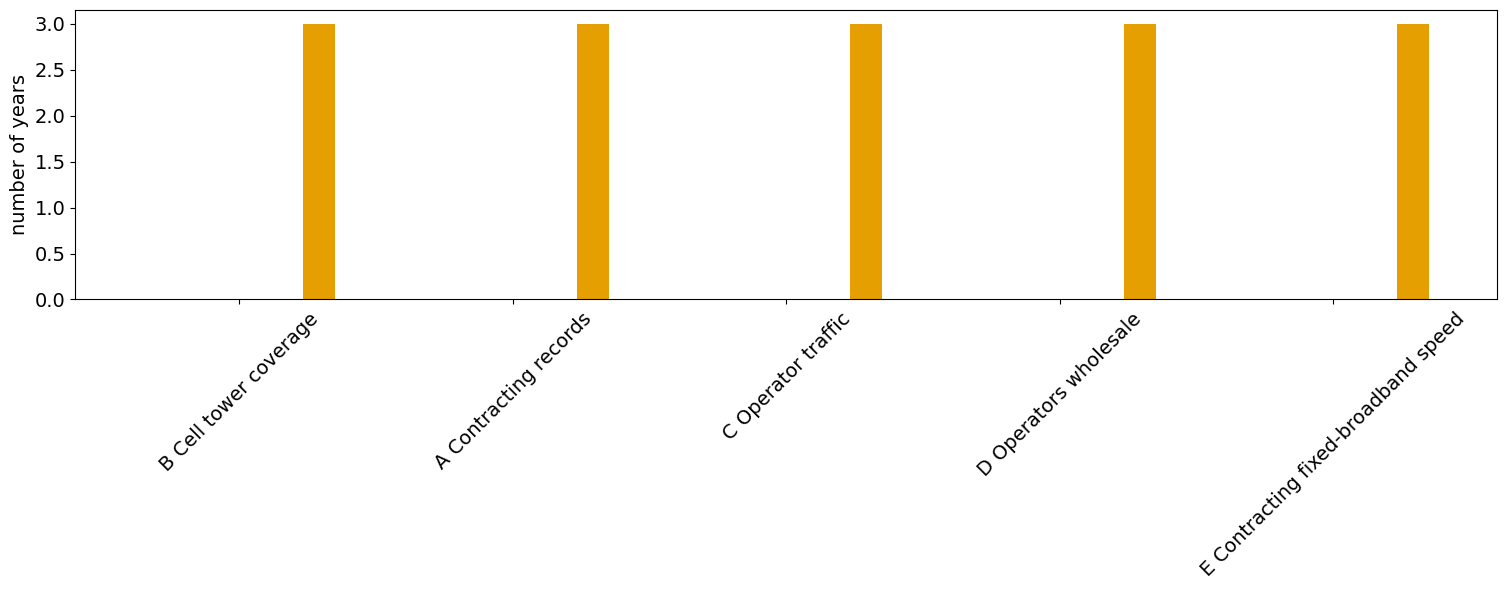

In [138]:
# Define your custom order
custom_order = ['Europe countries','CIS countries', 'Asia & Pacific', 'The Americas', 'Arab States', 'Africa']
#, 'Other Economies']

custom_colors = [
    '#0072B2',  # Blue
    '#CC79A7',  # Pink/Purple
    '#009E73',  # Green
    '#F0E442',  # Yellow
    '#56B4E9',  # Light Blue
    '#E69F00'  # Orange
    #'#696969'
    #'#999999',   # Grey
    ]

rename_dict = {
'B. Cell_tower_coverage_timeliness': "B Cell tower coverage",
'A. Contracting_records_timeliness':"A Contracting records",
'C. Operator_traffic_timeliness':"C Operator traffic",
'D. Operators_wholesale_timeliness':"D Operators wholesale",
'E. Contracting_fixed_broadband_speed_timeliness': "E Contracting fixed-broadband speed"
}

pivoted_t_group[pivoted_t_group.ShortName=='Madagascar'][['region_name','B. Cell_tower_coverage_timeliness',
       'A. Contracting_records_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness', 'E. Contracting_fixed_broadband_speed_timeliness']].rename(
     columns=rename_dict).groupby('region_name').mean(numeric_only=True).reindex(custom_order).T.sort_values(by='Africa', ascending=True).plot(kind='bar',
                                                  figsize=(15, 6),
                                                  color=custom_colors,
                                                  width=0.7)
#plt.title('Timeliness in 2025: time lag of latest available data point in number of years (available data only)')
plt.xlabel('')
plt.ylabel('number of years', fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

# adjust bottom margin to make space for legend
plt.subplots_adjust(bottom=0.6)  # increase bottom space

# Step 1: Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Step 2: Create a dict for easy lookup
label_to_handle = dict(zip(labels, handles))

# Step 3: Reconstruct the legend using custom order
plt.legend(
    [label_to_handle[label] for label in custom_order],
    custom_order,
    loc='upper center',
    bbox_to_anchor=(0.5, -1.1),
    ncol=7,
    fontsize=12
)
plt.legend().remove()

plt.tight_layout()
plt.show()

# WTI indicators results by country

In [139]:
pivoted_group.columns

Index(['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income', 'A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y',
       'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y',
       'E. Contracting_fixed_broadband_speed_5Y',
       'A. Contracting_records_5Y_p', 'B. Cell_tower_coverage_5Y_p',
       'C. Operator_traffic_5Y_p', 'D. Operators_wholesale_5Y_p',
       'E. Contracting_fixed_broadband_speed_5Y_p'],
      dtype='object')

In [140]:
pivoted_t_group.columns

Index(['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income', 'A. Contracting_records_timeliness',
       'B. Cell_tower_coverage_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness',
       'E. Contracting_fixed_broadband_speed_timeliness'],
      dtype='object')

In [141]:
pivoted_group[['ShortName', 'IsoCode', 'region_name', 'new_group',
       'WB_Income', 'A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y',
       'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y',
       'E. Contracting_fixed_broadband_speed_5Y']].merge(pivoted_t_group[['IsoCode', 'A. Contracting_records_timeliness',
       'B. Cell_tower_coverage_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness',
       'E. Contracting_fixed_broadband_speed_timeliness']], on='IsoCode', how='left')

,ShortName,IsoCode,region_name,new_group,WB_Income,A. Contracting_records_5Y,B. Cell_tower_coverage_5Y,C. Operator_traffic_5Y,D. Operators_wholesale_5Y,E. Contracting_fixed_broadband_speed_5Y,A. Contracting_records_timeliness,B. Cell_tower_coverage_timeliness,C. Operator_traffic_timeliness,D. Operators_wholesale_timeliness,E. Contracting_fixed_broadband_speed_timeliness
0,Afghanistan,AFG,Asia & Pacific,SIDS + LDC,Low income,4.0,3.0,2.0,2.0,NaN,2.0,3.0,3.0,3.0,NaN
1,Albania,ALB,Europe countries,Other developing and transition,Upper middle income,5.0,5.0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,1.0
2,Algeria,DZA,Arab States,Other developing and transition,Lower middle income,5.0,5.0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,1.0
3,Andorra,AND,Europe countries,Other developing and transition,High income,5.0,5.0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,1.0
4,Angola,AGO,Africa,SIDS + LDC,Lower middle income,5.0,5.0,5.0,4.0,4.0,1.0,1.0,1.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Vanuatu,VUT,Asia & Pacific,SIDS + LDC,Lower middle income,4.0,4.0,3.0,4.0,4.0,2.0,2.0,3.0,2.0,2.0
184,Viet Nam,VNM,Asia & Pacific,Other developing and transition,Lower middle income,5.0,5.0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,1.0
185,Yemen,YEM,Arab States,SIDS + LDC,Low income,3.0,3.0,3.0,2.0,2.0,3.0,3.0,3.0,4.0,4.0
186,Zambia,ZMB,Africa,SIDS + LDC,Low income,5.0,5.0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,1.0


In [142]:
results_wti_capacity = pivoted_group[['ShortName', 'IsoCode', 'region_name', 'new_group',
       'WB_Income', 'A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y',
       'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y',
       'E. Contracting_fixed_broadband_speed_5Y']].merge(pivoted_t_group[['IsoCode', 'A. Contracting_records_timeliness',
       'B. Cell_tower_coverage_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness',
       'E. Contracting_fixed_broadband_speed_timeliness']], on='IsoCode', how='left')

In [143]:
results_wti_capacity.to_excel('wti_capacity_country.xlsx', index=False)

## Comparing availability to timeliness

In [144]:
merged = pd.merge(pivoted[['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income','availability_5Y']], pivoted_t[['IsoCode', 'timeliness']], on='IsoCode', how='left')

merged.ShortName.nunique()

188

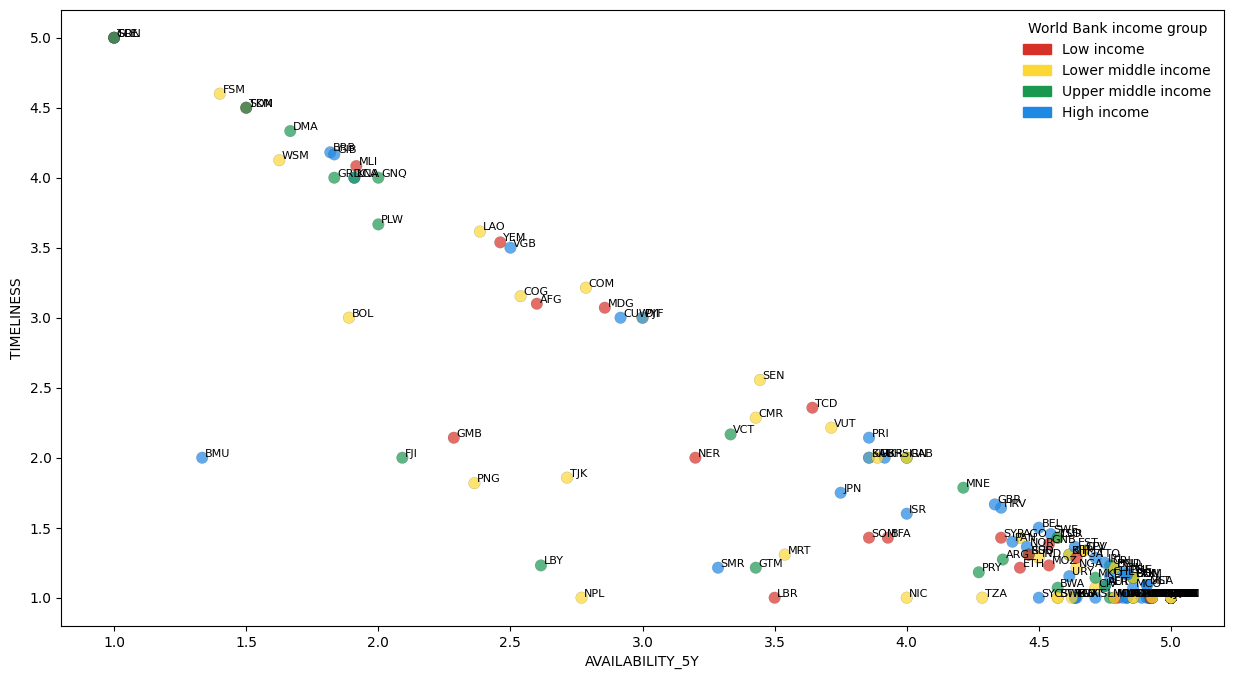

In [145]:
import matplotlib.patches as mpatches

# Start plotting
plt.figure(figsize=(15, 8))

# Assign a color to each income group
group_colors = {
    #'n.a.': '#999999',
    'Low income': '#d73027',
    'Lower middle income': '#fdd835',
    'Upper middle income': '#1a9850',
    'High income': '#1e88e5'
}
merged['group_color'] = merged['WB_Income'].map(group_colors)

# Define your columns
x_column = 'availability_5Y'
y_column = 'timeliness'
label_column='IsoCode'

# Scatter plot with manually assigned colors
plt.scatter(
    merged[x_column], merged[y_column],
    c=merged['group_color'],
    s=70, edgecolors='k', linewidths=0.1, alpha=0.7
)

# Add point labels
for i, label in enumerate(merged[label_column]):
    plt.text(merged[x_column].iloc[i]+0.01, merged[y_column].iloc[i]+0.01, label, fontsize=8)


# Add axis labels and title
plt.xlabel(x_column.upper())
plt.ylabel(y_column.upper())


# Add legend
patches = [mpatches.Patch(color=color, label=label) for label, color in group_colors.items()]
plt.legend(handles=patches, title='World Bank income group', frameon=False)

plt.show()

Sanity check 1: all countries that have 100% availability, have timeliness

In [146]:
merged [merged.availability_5Y==5]

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,availability_5Y,timeliness,group_color
1,Albania,Europe countries,ALB,Other developing and transition,Developed,Upper middle income,5.0,1.0,#1a9850
2,Algeria,Arab States,DZA,Other developing and transition,Developing,Lower middle income,5.0,1.0,#fdd835
3,Andorra,Europe countries,AND,Other developing and transition,Developed,High income,5.0,1.0,#1e88e5
6,Armenia,CIS countries,ARM,Other developing and transition,Developing,Upper middle income,5.0,1.0,#1a9850
7,Australia,Asia & Pacific,AUS,Developed-OECD,Developed,High income,5.0,1.0,#1e88e5
9,Azerbaijan,CIS countries,AZE,Other developing and transition,Developing,Upper middle income,5.0,1.0,#1a9850
11,Bahrain,Arab States,BHR,Other developing and transition,Developing,High income,5.0,1.0,#1e88e5
12,Bangladesh,Asia & Pacific,BGD,SIDS + LDC,Developing,Lower middle income,5.0,1.0,#fdd835
14,Belarus,CIS countries,BLR,Other developing and transition,Developed,Upper middle income,5.0,1.0,#1a9850
16,Benin,Africa,BEN,SIDS + LDC,Developing,Lower middle income,5.0,1.0,#fdd835


In [147]:
# list of developing, transition and SIDS+LDC who do well

merged[(merged.timeliness<1.5) & (merged.availability_5Y>=4.9) & (merged['new_group'].isin(['Other developing and transition', 'SIDS + LDC']))].sort_values(by='ShortName', ascending=True)

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,availability_5Y,timeliness,group_color
1,Albania,Europe countries,ALB,Other developing and transition,Developed,Upper middle income,5.000000,1.000000,#1a9850
2,Algeria,Arab States,DZA,Other developing and transition,Developing,Lower middle income,5.000000,1.000000,#fdd835
3,Andorra,Europe countries,AND,Other developing and transition,Developed,High income,5.000000,1.000000,#1e88e5
6,Armenia,CIS countries,ARM,Other developing and transition,Developing,Upper middle income,5.000000,1.000000,#1a9850
9,Azerbaijan,CIS countries,AZE,Other developing and transition,Developing,Upper middle income,5.000000,1.000000,#1a9850
11,Bahrain,Arab States,BHR,Other developing and transition,Developing,High income,5.000000,1.000000,#1e88e5
12,Bangladesh,Asia & Pacific,BGD,SIDS + LDC,Developing,Lower middle income,5.000000,1.000000,#fdd835
14,Belarus,CIS countries,BLR,Other developing and transition,Developed,Upper middle income,5.000000,1.000000,#1a9850
16,Benin,Africa,BEN,SIDS + LDC,Developing,Lower middle income,5.000000,1.000000,#fdd835
22,Brazil,The Americas,BRA,Other developing and transition,Developing,Upper middle income,5.000000,1.000000,#1a9850


In [148]:
# countries that could be considered of priority for capacity building
merged [(merged.timeliness>=2) & (merged.availability_5Y<4)].sort_values(by='IsoCode', ascending=True)

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,availability_5Y,timeliness,group_color
0,Afghanistan,Asia & Pacific,AFG,SIDS + LDC,Developing,Low income,2.600000,3.100000,#d73027
10,Bahamas,The Americas,BHS,SIDS + LDC,Developing,High income,3.916667,2.000000,#1e88e5
17,Bermuda,Other Economies,BMU,Other developing and transition,Developed,High income,1.333333,2.000000,#1e88e5
19,Bolivia (Plurinational State of),The Americas,BOL,Other developing and transition,Developing,Lower middle income,1.888889,3.000000,#fdd835
13,Barbados,The Americas,BRB,SIDS + LDC,Developing,High income,1.818182,4.181818,#1e88e5
30,Cameroon,Africa,CMR,Other developing and transition,Developing,Lower middle income,3.428571,2.285714,#fdd835
37,Congo (Rep. of the),Africa,COG,Other developing and transition,Developing,Lower middle income,2.538462,3.153846,#fdd835
36,Comoros,Arab States,COM,SIDS + LDC,Developing,Lower middle income,2.785714,3.214286,#fdd835
41,Curacao,Other Economies,CUW,Other developing and transition,Developing,High income,2.916667,3.000000,#1e88e5
47,Djibouti,Arab States,DJI,SIDS + LDC,Developing,Lower middle income,3.000000,3.000000,#fdd835


In [149]:
!pip install pycountry
import pycountry

# Create a dictionary mapping ISO3 to ISO2 codes
iso3_to_iso2 = {country.alpha_3: country.alpha_2 for country in pycountry.countries}

# Map the ISO3 codes to ISO2 codes
merged['iso2'] = merged['IsoCode'].map(iso3_to_iso2)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 52.2 MB/s eta 0:00:00


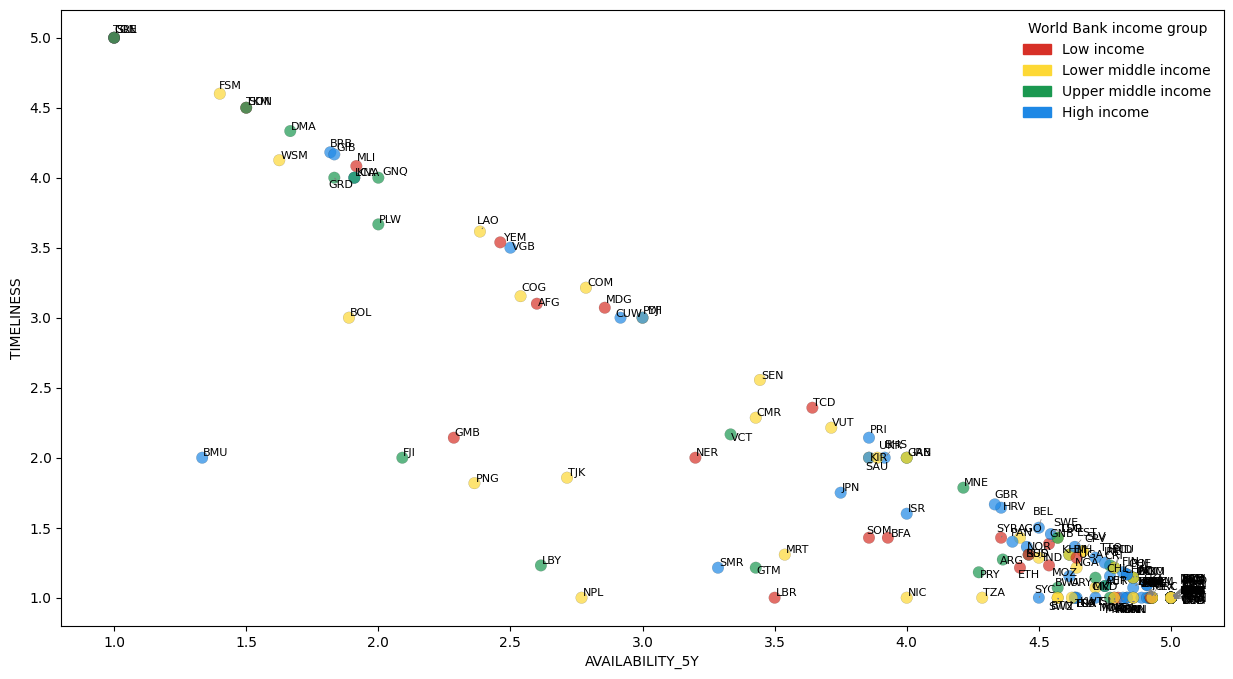

In [150]:
import matplotlib.patches as mpatches

# Start plotting
plt.figure(figsize=(15, 8))

# Assign a color to each income group
group_colors = {
    #'n.a.': '#999999',
    'Low income': '#d73027',
    'Lower middle income': '#fdd835',
    'Upper middle income': '#1a9850',
    'High income': '#1e88e5'
}
merged['group_color'] = merged['WB_Income'].map(group_colors)

# Define your columns
x_column = 'availability_5Y'
y_column = 'timeliness'
label_column='iso2'

# Scatter plot with manually assigned colors
plt.scatter(
    merged[x_column], merged[y_column],
    c=merged['group_color'],
    s=70, edgecolors='k', linewidths=0.1, alpha=0.7
)

# Add point labels
#for i, label in enumerate(merged[label_column]):
    #plt.text(merged[x_column].iloc[i]+0.01, merged[y_column].iloc[i]+0.01, label, fontsize=8)

# Create text objects
texts = []
for i, row in merged.iterrows():
    texts.append(
        plt.text(row['availability_5Y'],
                 row['timeliness'],
                 row['IsoCode'],
                 fontsize=8)
    )

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))


# Add axis labels and title
plt.xlabel(x_column.upper())
plt.ylabel(y_column.upper())


# Add legend
patches = [mpatches.Patch(color=color, label=label) for label, color in group_colors.items()]
plt.legend(handles=patches, title='World Bank income group', frameon=False)

plt.show()

Do this again, but for those with availability below 4

In [151]:
merged[merged.availability_5Y<4].sort_values(by='IsoCode', ascending=True)

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,availability_5Y,timeliness,group_color,iso2
0,Afghanistan,Asia & Pacific,AFG,SIDS + LDC,Developing,Low income,2.600000,3.100000,#d73027,AF
26,Burkina Faso,Africa,BFA,SIDS + LDC,Developing,Low income,3.928571,1.428571,#d73027,BF
10,Bahamas,The Americas,BHS,SIDS + LDC,Developing,High income,3.916667,2.000000,#1e88e5,BS
17,Bermuda,Other Economies,BMU,Other developing and transition,Developed,High income,1.333333,2.000000,#1e88e5,BM
19,Bolivia (Plurinational State of),The Americas,BOL,Other developing and transition,Developing,Lower middle income,1.888889,3.000000,#fdd835,BO
13,Barbados,The Americas,BRB,SIDS + LDC,Developing,High income,1.818182,4.181818,#1e88e5,BB
30,Cameroon,Africa,CMR,Other developing and transition,Developing,Lower middle income,3.428571,2.285714,#fdd835,CM
37,Congo (Rep. of the),Africa,COG,Other developing and transition,Developing,Lower middle income,2.538462,3.153846,#fdd835,CG
36,Comoros,Arab States,COM,SIDS + LDC,Developing,Lower middle income,2.785714,3.214286,#fdd835,KM
41,Curacao,Other Economies,CUW,Other developing and transition,Developing,High income,2.916667,3.000000,#1e88e5,CW


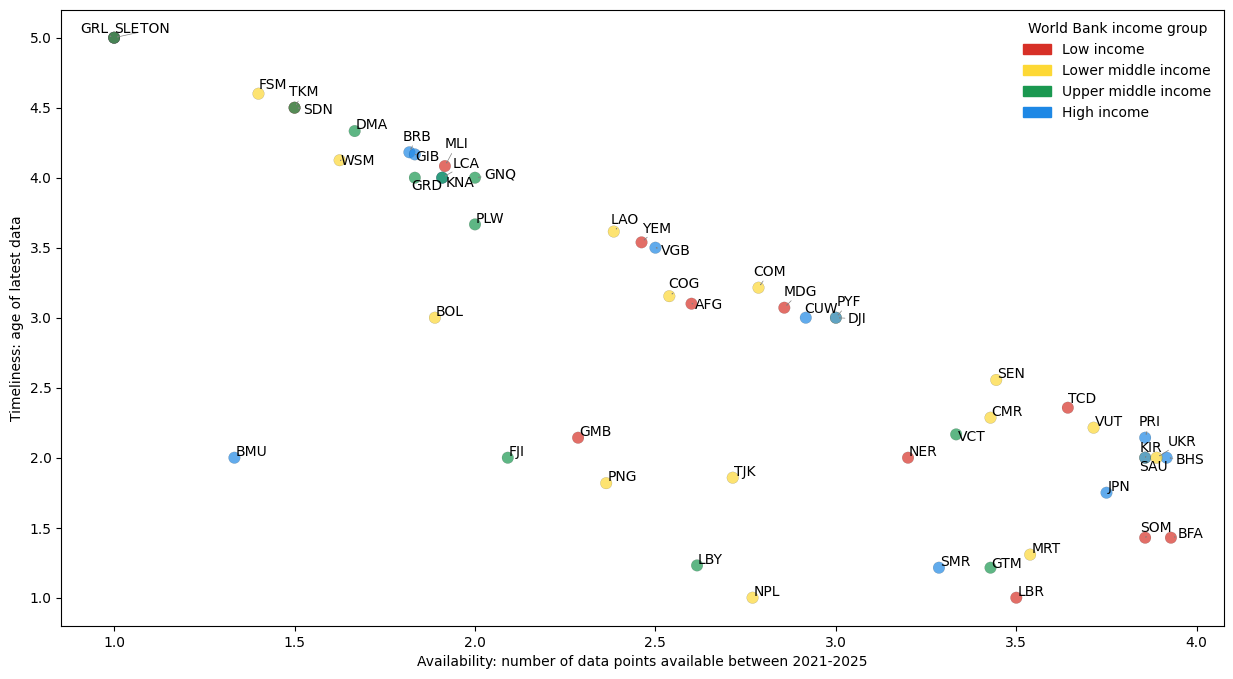

In [152]:
import matplotlib.patches as mpatches

# Start plotting
plt.figure(figsize=(15, 8))

# Assign a color to each income group
group_colors = {
    #'n.a.': '#999999',
    'Low income': '#d73027',
    'Lower middle income': '#fdd835',
    'Upper middle income': '#1a9850',
    'High income': '#1e88e5'
}
merged['group_color'] = merged['WB_Income'].map(group_colors)

# Define your columns
x_column = 'availability_5Y'
y_column = 'timeliness'
label_column='iso2'

# Scatter plot with manually assigned colors
plt.scatter(
    merged[merged.availability_5Y<4][x_column], merged[merged.availability_5Y<4][y_column],
    c=merged[merged.availability_5Y<4]['group_color'],
    s=70, edgecolors='k', linewidths=0.1, alpha=0.7
)

# Add point labels
#for i, label in enumerate(merged[label_column]):
    #plt.text(merged[x_column].iloc[i]+0.01, merged[y_column].iloc[i]+0.01, label, fontsize=8)

# Create text objects
texts = []
for i, row in merged[merged.availability_5Y<4].iterrows():
    texts.append(
        plt.text(row['availability_5Y'],
                 row['timeliness'],
                 row['IsoCode'],
                 fontsize=10)
    )

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))


# Add axis labels and title
plt.xlabel('Availability: number of data points available between 2021-2025')
plt.ylabel('Timeliness: age of latest data')


# Add legend
patches = [mpatches.Patch(color=color, label=label) for label, color in group_colors.items()]
plt.legend(handles=patches, title='World Bank income group', frameon=False)

plt.show()

## Group-wise find priority countries for assistance

By indicator group, find countries that have unsatisfactory timeliness and low availability by group of indicators

In [153]:
merged_group = pd.merge(pivoted_group[['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income', 'A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y',
       'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y',
       'E. Contracting_fixed_broadband_speed_5Y',]], pivoted_t_group[['IsoCode', 'A. Contracting_records_timeliness',
       'B. Cell_tower_coverage_timeliness', 'C. Operator_traffic_timeliness',
       'D. Operators_wholesale_timeliness',
       'E. Contracting_fixed_broadband_speed_timeliness']],
        on='IsoCode', how='left')

merged_group.ShortName.nunique()

188

In [154]:
merged_group[['A. Contracting_records_timeliness', 'B. Cell_tower_coverage_5Y', 'C. Operator_traffic_5Y','D. Operators_wholesale_5Y','E. Contracting_fixed_broadband_speed_5Y', ]].describe()

,A. Contracting_records_timeliness,B. Cell_tower_coverage_5Y,C. Operator_traffic_5Y,D. Operators_wholesale_5Y,E. Contracting_fixed_broadband_speed_5Y
count,188.000000,186.000000,163.000000,142.000000,172.000000
mean,1.420213,4.360215,4.496933,4.176056,4.296512
std,0.958506,1.126740,1.026646,1.317096,1.179449
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,4.000000,4.500000,4.000000,4.000000
50%,1.000000,5.000000,5.000000,5.000000,5.000000
75%,1.000000,5.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000


In [155]:
# now checking for cell tower coverage indicators

merged_group[['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income', 'B. Cell_tower_coverage_5Y', 'B. Cell_tower_coverage_timeliness']][(merged_group['B. Cell_tower_coverage_5Y']<3) & (merged_group['B. Cell_tower_coverage_timeliness']>1)].sort_values(by='ShortName', ascending=True)

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,B. Cell_tower_coverage_5Y,B. Cell_tower_coverage_timeliness
13,Barbados,The Americas,BRB,SIDS + LDC,Developing,High income,2.0,4.0
17,Bermuda,Other Economies,BMU,Other developing and transition,Developed,High income,1.0,2.0
19,Bolivia (Plurinational State of),The Americas,BOL,Other developing and transition,Developing,Lower middle income,2.0,2.0
23,British Virgin Islands,Other Economies,VGB,SIDS + LDC,Developing,High income,1.0,5.0
48,Dominica,The Americas,DMA,SIDS + LDC,Developing,Upper middle income,2.0,4.0
53,Equatorial Guinea,Africa,GNQ,Other developing and transition,Developing,Upper middle income,2.0,4.0
62,Gambia,Africa,GMB,SIDS + LDC,Developing,Low income,2.0,2.0
66,Gibraltar,Other Economies,GIB,Other developing and transition,Developed,High income,2.0,4.0
68,Greenland,Other Economies,GRL,Other developing and transition,Developed,High income,1.0,5.0
69,Grenada,The Americas,GRD,SIDS + LDC,Developing,Upper middle income,2.0,4.0


In [156]:
# now checking for Contracting_fixed_broadband_speed


merged_group[['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income', 'E. Contracting_fixed_broadband_speed_5Y', 'E. Contracting_fixed_broadband_speed_timeliness']][(merged_group['E. Contracting_fixed_broadband_speed_5Y']<3) & (merged_group['E. Contracting_fixed_broadband_speed_timeliness']>1)].sort_values(by='ShortName', ascending=True)

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,E. Contracting_fixed_broadband_speed_5Y,E. Contracting_fixed_broadband_speed_timeliness
13,Barbados,The Americas,BRB,SIDS + LDC,Developing,High income,2.0,4.0
17,Bermuda,Other Economies,BMU,Other developing and transition,Developed,High income,1.0,2.0
19,Bolivia (Plurinational State of),The Americas,BOL,Other developing and transition,Developing,Lower middle income,1.0,5.0
30,Cameroon,Africa,CMR,Other developing and transition,Developing,Lower middle income,2.0,4.0
37,Congo (Rep. of the),Africa,COG,Other developing and transition,Developing,Lower middle income,2.0,3.0
48,Dominica,The Americas,DMA,SIDS + LDC,Developing,Upper middle income,2.0,4.0
53,Equatorial Guinea,Africa,GNQ,Other developing and transition,Developing,Upper middle income,2.0,4.0
57,Fiji,Asia & Pacific,FJI,SIDS + LDC,Developing,Upper middle income,2.0,2.0
66,Gibraltar,Other Economies,GIB,Other developing and transition,Developed,High income,2.0,4.0
68,Greenland,Other Economies,GRL,Other developing and transition,Developed,High income,1.0,5.0


In [157]:
# now checking for Contracting_records



merged_group[['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income', 'A. Contracting_records_5Y', 'A. Contracting_records_timeliness']][(merged_group['A. Contracting_records_5Y']<3) & (merged_group['A. Contracting_records_timeliness']>1)].sort_values(by='ShortName', ascending=True)

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,A. Contracting_records_5Y,A. Contracting_records_timeliness
13,Barbados,The Americas,BRB,SIDS + LDC,Developing,High income,2.0,4.0
17,Bermuda,Other Economies,BMU,Other developing and transition,Developed,High income,2.0,2.0
48,Dominica,The Americas,DMA,SIDS + LDC,Developing,Upper middle income,2.0,4.0
53,Equatorial Guinea,Africa,GNQ,Other developing and transition,Developing,Upper middle income,2.0,4.0
57,Fiji,Asia & Pacific,FJI,SIDS + LDC,Developing,Upper middle income,2.0,2.0
66,Gibraltar,Other Economies,GIB,Other developing and transition,Developed,High income,2.0,4.0
68,Greenland,Other Economies,GRL,Other developing and transition,Developed,High income,1.0,5.0
69,Grenada,The Americas,GRD,SIDS + LDC,Developing,Upper middle income,2.0,4.0
105,Mali,Africa,MLI,SIDS + LDC,Developing,Low income,2.0,4.0
110,Micronesia,Asia & Pacific,FSM,SIDS + LDC,Developing,Lower middle income,1.0,5.0


In [158]:
# now checking for Operator_traffic



merged_group[['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income', 'C. Operator_traffic_5Y', 'C. Operator_traffic_timeliness']][(merged_group['C. Operator_traffic_5Y']<3) & (merged_group['C. Operator_traffic_timeliness']>1)].sort_values(by='ShortName', ascending=True)

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,C. Operator_traffic_5Y,C. Operator_traffic_timeliness
0,Afghanistan,Asia & Pacific,AFG,SIDS + LDC,Developing,Low income,2.0,3.0
13,Barbados,The Americas,BRB,SIDS + LDC,Developing,High income,1.0,5.0
32,Chad,Africa,TCD,SIDS + LDC,Developing,Low income,2.0,4.0
41,Curacao,Other Economies,CUW,Other developing and transition,Developing,High income,2.0,3.0
53,Equatorial Guinea,Africa,GNQ,Other developing and transition,Developing,Upper middle income,2.0,4.0
57,Fiji,Asia & Pacific,FJI,SIDS + LDC,Developing,Upper middle income,2.0,2.0
62,Gambia,Africa,GMB,SIDS + LDC,Developing,Low income,2.0,3.0
92,Lao P.D.R.,Asia & Pacific,LAO,SIDS + LDC,Developing,Lower middle income,1.0,5.0
144,Saint Vincent and the Grenadines,The Americas,VCT,SIDS + LDC,Developing,Upper middle income,1.0,2.0
171,Tonga,Asia & Pacific,TON,SIDS + LDC,Developing,Upper middle income,1.0,5.0


In [159]:
# now checking for Operators_wholesale


merged_group[['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income', 'D. Operators_wholesale_5Y', 'D. Operators_wholesale_timeliness']][(merged_group['D. Operators_wholesale_5Y']<3) & (merged_group['D. Operators_wholesale_timeliness']>1)].sort_values(by='ShortName', ascending=True)

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,D. Operators_wholesale_5Y,D. Operators_wholesale_timeliness
0,Afghanistan,Asia & Pacific,AFG,SIDS + LDC,Developing,Low income,2.0,3.0
13,Barbados,The Americas,BRB,SIDS + LDC,Developing,High income,1.0,5.0
17,Bermuda,Other Economies,BMU,Other developing and transition,Developed,High income,1.0,2.0
19,Bolivia (Plurinational State of),The Americas,BOL,Other developing and transition,Developing,Lower middle income,1.0,5.0
37,Congo (Rep. of the),Africa,COG,Other developing and transition,Developing,Lower middle income,2.0,3.0
39,Croatia,Europe countries,HRV,Other developing and transition,Developed,High income,2.0,4.0
53,Equatorial Guinea,Africa,GNQ,Other developing and transition,Developing,Upper middle income,2.0,4.0
57,Fiji,Asia & Pacific,FJI,SIDS + LDC,Developing,Upper middle income,2.0,2.0
66,Gibraltar,Other Economies,GIB,Other developing and transition,Developed,High income,2.0,4.0
69,Grenada,The Americas,GRD,SIDS + LDC,Developing,Upper middle income,2.0,4.0


# REDO the analysis but with missing data assumptions, so that we can see the countries with no data

In [160]:
pivoted = wti_counts.pivot(index=['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType', 'WB_Income'], columns='Code', values=['5Y'])
# Replace NaNs with 0
pivoted = pivoted.fillna(0)

# Flatten and rename the columns
pivoted.columns = [
    f"{indicator}_{suffix}"
    for suffix, indicator in pivoted.columns
]

pivoted.reset_index(inplace=True)

pivoted.head()

,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,i112_5Y,i135tfb_5Y,i136mwi_5Y,i271_5Y,i271G_5Y,i271G5_pop_5Y,i271GA_5Y,i271mw_5Y,i4213_256to2_5Y,i4213_2to10_5Y,i4213_G10_5Y,i4213tfbb_5Y,i4214l_5Y,i4214u_5Y
0,Afghanistan,Asia & Pacific,AFG,SIDS + LDC,Developing,Low income,3.0,0.0,2.0,4.0,3.0,1.0,3.0,3.0,0.0,0.0,0.0,3.0,2.0,2.0
1,Albania,Europe countries,ALB,Other developing and transition,Developed,Upper middle income,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,0.0
2,Algeria,Arab States,DZA,Other developing and transition,Developing,Lower middle income,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
3,Andorra,Europe countries,AND,Other developing and transition,Developed,High income,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
4,Angola,Africa,AGO,SIDS + LDC,Developing,Lower middle income,5.0,4.0,5.0,5.0,5.0,3.0,5.0,5.0,4.0,4.0,4.0,5.0,4.0,4.0


In [161]:
## this dataset contains imputed 0s as in 0 data points available
# we get countries with 0 data points in the last 5 years for every indicator
pivoted.describe()


,i112_5Y,i135tfb_5Y,i136mwi_5Y,i271_5Y,i271G_5Y,i271G5_pop_5Y,i271GA_5Y,i271mw_5Y,i4213_256to2_5Y,i4213_2to10_5Y,i4213_G10_5Y,i4213tfbb_5Y,i4214l_5Y,i4214u_5Y
count,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,4.297872,3.101064,3.835106,4.473404,4.255319,3.420213,4.207447,4.308511,3.585106,3.659574,3.867021,4.409574,3.090426,2.781915
std,1.252418,2.168170,1.852716,1.046683,1.240460,1.811731,1.289425,1.266826,1.840772,1.844507,1.705097,1.136330,2.158756,2.220539
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,4.000000,0.000000,3.000000,4.750000,4.000000,2.000000,4.000000,4.000000,2.000000,2.000000,3.000000,4.000000,0.000000,0.000000
50%,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000
75%,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [162]:
wti_counts_group = wti_counts.groupby(["ShortName", "region_name", "wti_group", "IsoCode", 'new_group', 'CountryType', 'WB_Income'], as_index=False)["5Y"].max()

# add percentage column

wti_counts_group['5Y_p'] = wti_counts_group['5Y'] / 5 *100

pivoted_group = wti_counts_group.pivot(index=['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType', 'WB_Income'], columns='wti_group', values=['5Y'])

# Replace NaNs with 0
pivoted_group = pivoted_group.fillna(0)

# Flatten and rename the columns
pivoted_group.columns = [
    f"{indicator}_{suffix}"
    for suffix, indicator in pivoted_group.columns
]

pivoted_group.reset_index(inplace=True)

pivoted_group.head()


,ShortName,region_name,IsoCode,new_group,CountryType,WB_Income,A. Contracting_records_5Y,B. Cell_tower_coverage_5Y,C. Operator_traffic_5Y,D. Operators_wholesale_5Y,E. Contracting_fixed_broadband_speed_5Y
0,Afghanistan,Asia & Pacific,AFG,SIDS + LDC,Developing,Low income,4.0,3.0,2.0,2.0,0.0
1,Albania,Europe countries,ALB,Other developing and transition,Developed,Upper middle income,5.0,5.0,5.0,5.0,5.0
2,Algeria,Arab States,DZA,Other developing and transition,Developing,Lower middle income,5.0,5.0,5.0,5.0,5.0
3,Andorra,Europe countries,AND,Other developing and transition,Developed,High income,5.0,5.0,5.0,5.0,5.0
4,Angola,Africa,AGO,SIDS + LDC,Developing,Lower middle income,5.0,5.0,5.0,4.0,4.0


In [163]:
# this shows countries with 0 records over the past 5 years by indicator group
pivoted_group.describe()

,A. Contracting_records_5Y,B. Cell_tower_coverage_5Y,C. Operator_traffic_5Y,D. Operators_wholesale_5Y,E. Contracting_fixed_broadband_speed_5Y
count,188.000000,188.000000,188.000000,188.000000,188.000000
mean,4.526596,4.313830,3.898936,3.154255,3.930851
std,0.999644,1.207118,1.804747,2.132667,1.648368
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,4.000000,3.750000,1.000000,3.000000
50%,5.000000,5.000000,5.000000,4.000000,5.000000
75%,5.000000,5.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000


In [164]:
pivoted_group[['ShortName', 'region_name', 'IsoCode', 'new_group', 'WB_Income', 'A. Contracting_records_5Y']][pivoted_group['A. Contracting_records_5Y']<=1].sort_values(by='region_name').reset_index(drop=True)

,ShortName,region_name,IsoCode,new_group,WB_Income,A. Contracting_records_5Y
0,Sierra Leone,Africa,SLE,SIDS + LDC,Low income,1.0
1,Micronesia,Asia & Pacific,FSM,SIDS + LDC,Lower middle income,1.0
2,Tonga,Asia & Pacific,TON,SIDS + LDC,Upper middle income,1.0
3,Greenland,Other Economies,GRL,Other developing and transition,High income,1.0


In [165]:
pivoted_group[
    ['ShortName', 'region_name', 'IsoCode', 'new_group', 'WB_Income',
     'B. Cell_tower_coverage_5Y']
][
    pivoted_group['B. Cell_tower_coverage_5Y'] <= 1
].sort_values(
    by=['region_name', 'ShortName']
).reset_index(
    drop=True
)

,ShortName,region_name,IsoCode,new_group,WB_Income,B. Cell_tower_coverage_5Y
0,Niger,Africa,NER,SIDS + LDC,Low income,0.0
1,Sierra Leone,Africa,SLE,SIDS + LDC,Low income,1.0
2,Tonga,Asia & Pacific,TON,SIDS + LDC,Upper middle income,1.0
3,Turkmenistan,CIS countries,TKM,Other developing and transition,Upper middle income,0.0
4,Bermuda,Other Economies,BMU,Other developing and transition,High income,1.0
5,British Virgin Islands,Other Economies,VGB,SIDS + LDC,High income,1.0
6,Greenland,Other Economies,GRL,Other developing and transition,High income,1.0


In [166]:
pivoted_group[
    ['ShortName', 'region_name', 'IsoCode', 'new_group', 'WB_Income',
     'C. Operator_traffic_5Y']
][
    pivoted_group['C. Operator_traffic_5Y'] < 1
].sort_values(
    by=['region_name', 'ShortName']
).reset_index(
    drop=True
)

,ShortName,region_name,IsoCode,new_group,WB_Income,C. Operator_traffic_5Y
0,Gabon,Africa,GAB,Other developing and transition,Upper middle income,0.0
1,Mali,Africa,MLI,SIDS + LDC,Low income,0.0
2,Niger,Africa,NER,SIDS + LDC,Low income,0.0
3,Sierra Leone,Africa,SLE,SIDS + LDC,Low income,0.0
4,Sudan,Arab States,SDN,SIDS + LDC,Low income,0.0
5,Micronesia,Asia & Pacific,FSM,SIDS + LDC,Lower middle income,0.0
6,Palau,Asia & Pacific,PLW,SIDS + LDC,Upper middle income,0.0
7,Samoa,Asia & Pacific,WSM,SIDS + LDC,Lower middle income,0.0
8,Timor-Leste,Asia & Pacific,TLS,SIDS + LDC,Lower middle income,0.0
9,Tajikistan,CIS countries,TJK,Other developing and transition,Lower middle income,0.0


In [167]:
pivoted_group[
    ['ShortName', 'region_name', 'IsoCode', 'new_group', 'WB_Income',
     'D. Operators_wholesale_5Y']
][
    (pivoted_group['D. Operators_wholesale_5Y'] < 1) &
    (pivoted_group['new_group'] != 'Developed-OECD')
].sort_values(
    by=['region_name', 'ShortName']
).reset_index(
    drop=True
)

,ShortName,region_name,IsoCode,new_group,WB_Income,D. Operators_wholesale_5Y
0,Gambia,Africa,GMB,SIDS + LDC,Low income,0.0
1,Liberia,Africa,LBR,SIDS + LDC,Low income,0.0
2,Senegal,Africa,SEN,SIDS + LDC,Lower middle income,0.0
3,Micronesia,Asia & Pacific,FSM,SIDS + LDC,Lower middle income,0.0
4,Palau,Asia & Pacific,PLW,SIDS + LDC,Upper middle income,0.0
5,Philippines,Asia & Pacific,PHL,Other developing and transition,Lower middle income,0.0
6,Tajikistan,CIS countries,TJK,Other developing and transition,Lower middle income,0.0
7,Liechtenstein,Europe countries,LIE,Other developing and transition,High income,0.0
8,Malta,Europe countries,MLT,Other developing and transition,High income,0.0
9,Ukraine,Europe countries,UKR,Other developing and transition,Lower middle income,0.0


In [168]:
pivoted_group[
    ['ShortName', 'region_name', 'IsoCode', 'new_group', 'WB_Income',
     'E. Contracting_fixed_broadband_speed_5Y']
][
    (pivoted_group['E. Contracting_fixed_broadband_speed_5Y'] < 1) &
    (pivoted_group['new_group'] != 'Developed-OECD')
].sort_values(
    by=['region_name', 'ShortName']
).reset_index(
    drop=True,
)

,ShortName,region_name,IsoCode,new_group,WB_Income,E. Contracting_fixed_broadband_speed_5Y
0,Gambia,Africa,GMB,SIDS + LDC,Low income,0.0
1,Liberia,Africa,LBR,SIDS + LDC,Low income,0.0
2,Niger,Africa,NER,SIDS + LDC,Low income,0.0
3,Senegal,Africa,SEN,SIDS + LDC,Lower middle income,0.0
4,Afghanistan,Asia & Pacific,AFG,SIDS + LDC,Low income,0.0
5,Maldives,Asia & Pacific,MDV,SIDS + LDC,Upper middle income,0.0
6,Micronesia,Asia & Pacific,FSM,SIDS + LDC,Lower middle income,0.0
7,Papua New Guinea,Asia & Pacific,PNG,SIDS + LDC,Lower middle income,0.0
8,Philippines,Asia & Pacific,PHL,Other developing and transition,Lower middle income,0.0
9,Samoa,Asia & Pacific,WSM,SIDS + LDC,Lower middle income,0.0


now do for all the countries with plenty of conditions

In [169]:
pivoted_group.columns

Index(['ShortName', 'region_name', 'IsoCode', 'new_group', 'CountryType',
       'WB_Income', 'A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y',
       'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y',
       'E. Contracting_fixed_broadband_speed_5Y'],
      dtype='object')

In [170]:
pivoted_group[
    ['ShortName', 'region_name', 'IsoCode', 'new_group', 'WB_Income',
     'A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y',
     'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y',
     'E. Contracting_fixed_broadband_speed_5Y']
][
    (pivoted_group['new_group'] != 'Developed-OECD') &
    (
        (pivoted_group['A. Contracting_records_5Y'] < 1) |
        (pivoted_group['B. Cell_tower_coverage_5Y'] < 1) |
        (pivoted_group['C. Operator_traffic_5Y'] < 1) |
        (pivoted_group['D. Operators_wholesale_5Y'] < 1) |
        (pivoted_group['E. Contracting_fixed_broadband_speed_5Y'] < 1)
    )
].sort_values(
    by=['region_name', 'ShortName']
).reset_index(
    drop=True
)

,ShortName,region_name,IsoCode,new_group,WB_Income,A. Contracting_records_5Y,B. Cell_tower_coverage_5Y,C. Operator_traffic_5Y,D. Operators_wholesale_5Y,E. Contracting_fixed_broadband_speed_5Y
0,Gabon,Africa,GAB,Other developing and transition,Upper middle income,4.0,4.0,0.0,4.0,4.0
1,Gambia,Africa,GMB,SIDS + LDC,Low income,3.0,2.0,2.0,0.0,0.0
2,Liberia,Africa,LBR,SIDS + LDC,Low income,5.0,2.0,2.0,0.0,0.0
3,Mali,Africa,MLI,SIDS + LDC,Low income,2.0,2.0,0.0,2.0,2.0
4,Niger,Africa,NER,SIDS + LDC,Low income,4.0,0.0,0.0,4.0,0.0
5,Senegal,Africa,SEN,SIDS + LDC,Lower middle income,4.0,3.0,4.0,0.0,0.0
6,Sierra Leone,Africa,SLE,SIDS + LDC,Low income,1.0,1.0,0.0,1.0,1.0
7,Sudan,Arab States,SDN,SIDS + LDC,Low income,2.0,2.0,0.0,1.0,1.0
8,Afghanistan,Asia & Pacific,AFG,SIDS + LDC,Low income,4.0,3.0,2.0,2.0,0.0
9,Maldives,Asia & Pacific,MDV,SIDS + LDC,Upper middle income,5.0,5.0,5.0,5.0,0.0


# Hierarchical clustering

In [171]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

In [172]:
# this is my dataset
pivoted_group[
    ['ShortName', 'region_name', 'IsoCode', 'new_group', 'WB_Income',
     'A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y',
     'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y',
     'E. Contracting_fixed_broadband_speed_5Y']
]

# extracting the features

X= pivoted_group[['A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y',
     'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y',
     'E. Contracting_fixed_broadband_speed_5Y']].values

country_names = pivoted_group['ShortName'].values

# Step 2: Perform hierarchical clustering
# 'ward' minimizes variance within clusters (usually works well)
# Other options: 'complete', 'average', 'single'
linkage_matrix = linkage(X, method='ward')

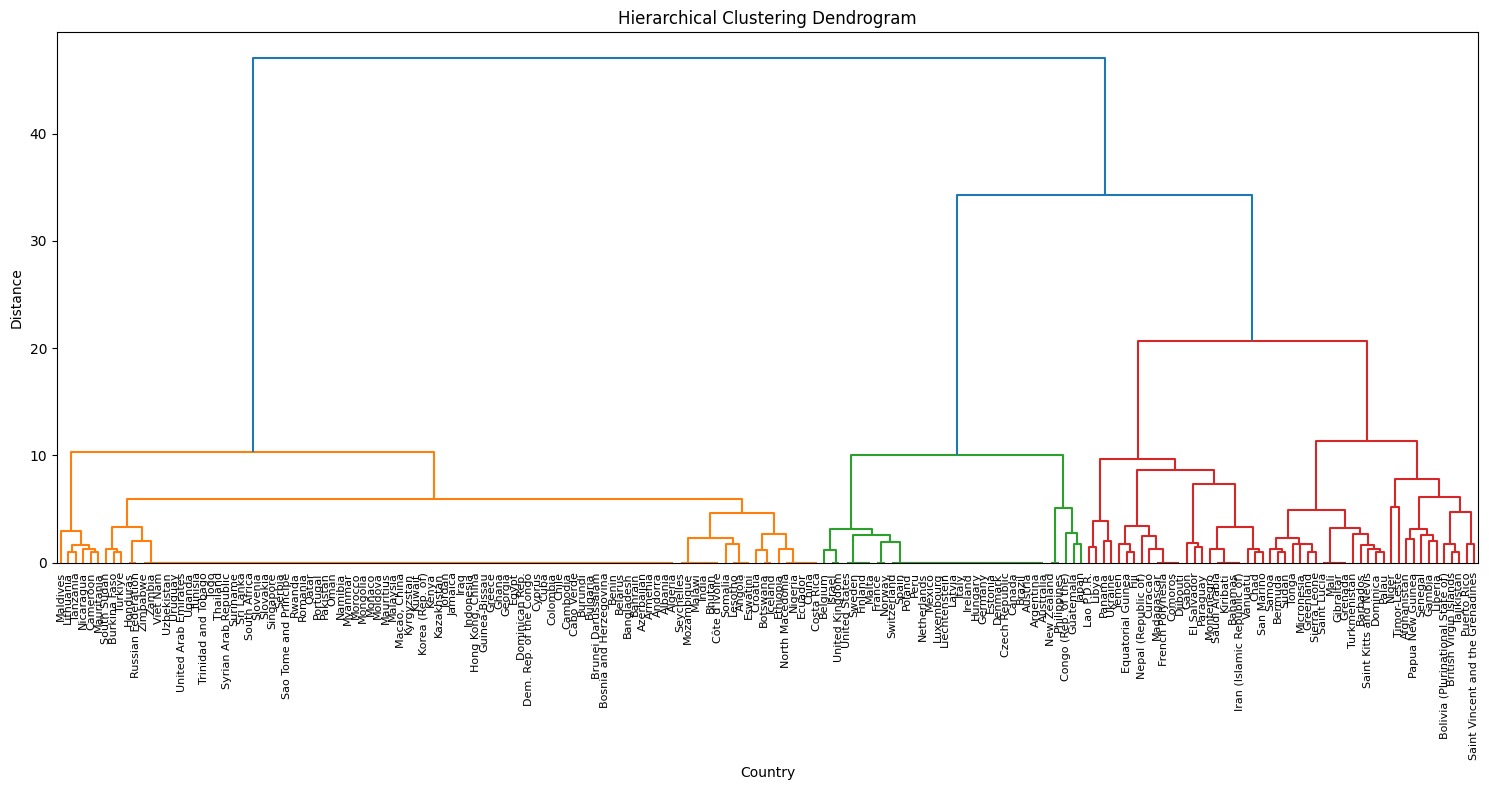

In [173]:
# Step 3: Create a dendrogram to visualize
plt.figure(figsize=(15, 8))
dendrogram(
    linkage_matrix,
    labels=country_names,
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Country')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [174]:
# Step 4: Cut the dendrogram to create clusters
# Choose number of clusters (try different values)
n_clusters = 4  # Adjust this based on what you see in the dendrogram

clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

# Add cluster labels to your dataframe
pivoted_group['Cluster'] = clusters

# Step 5: Analyze the clusters
print(f"\nNumber of countries per cluster:")
print(pivoted_group['Cluster'].value_counts().sort_index())

print(f"\nCluster characteristics (mean values):")
cluster_summary = pivoted_group.groupby('Cluster')[['A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y',
     'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y',
     'E. Contracting_fixed_broadband_speed_5Y']].mean()
print(cluster_summary.round(2))


Number of countries per cluster:
Cluster
1    101
2     35
3     24
4     28
Name: count, dtype: int64

Cluster characteristics (mean values):
         A. Contracting_records_5Y  B. Cell_tower_coverage_5Y  \
Cluster                                                         
1                             5.00                       4.95   
2                             5.00                       4.86   
3                             3.75                       3.50   
4                             2.89                       2.04   

         C. Operator_traffic_5Y  D. Operators_wholesale_5Y  \
Cluster                                                      
1                          4.92                       4.83   
2                          4.77                       0.09   
3                          2.17                       3.00   
4                          0.61                       1.07   

         E. Contracting_fixed_broadband_speed_5Y  
Cluster                                  

In [175]:
# Step 6: See which countries are in each cluster
for i in range(1, n_clusters + 1):
    print(f"\n--- Cluster {i} ---")
    countries_in_cluster = pivoted_group[pivoted_group['Cluster'] == i]['ShortName'].tolist()
    print(f"Countries ({len(countries_in_cluster)}): {', '.join(countries_in_cluster)}")



--- Cluster 1 ---
Countries (101): Albania, Algeria, Andorra, Angola, Armenia, Azerbaijan, Bahrain, Bangladesh, Belarus, Benin, Bhutan, Bosnia and Herzegovina, Botswana, Brunei Darussalam, Bulgaria, Burkina Faso, Burundi, Cabo Verde, Cambodia, Cameroon, Chile, China, Colombia, Costa Rica, Croatia, Cuba, Cyprus, Côte d'Ivoire, Dem. Rep. of the Congo, Dominican Rep., Ecuador, Egypt, Eswatini, Ethiopia, Georgia, Ghana, Greece, Guinea-Bissau, Honduras, Hong Kong, China, Iceland, India, Indonesia, Iraq, Jamaica, Jordan, Kazakhstan, Kenya, Korea (Rep. of), Kuwait, Kyrgyzstan, Lesotho, Lithuania, Macao, China, Malawi, Malaysia, Maldives, Mauritania, Mauritius, Moldova, Monaco, Mongolia, Morocco, Mozambique, Myanmar, Namibia, Nicaragua, Nigeria, North Macedonia, Oman, Pakistan, Portugal, Qatar, Romania, Russian Federation, Rwanda, Sao Tome and Principe, Serbia, Seychelles, Singapore, Slovakia, Slovenia, Somalia, South Africa, South Sudan, Sri Lanka, Suriname, Syrian Arab Republic, Tanzania, T

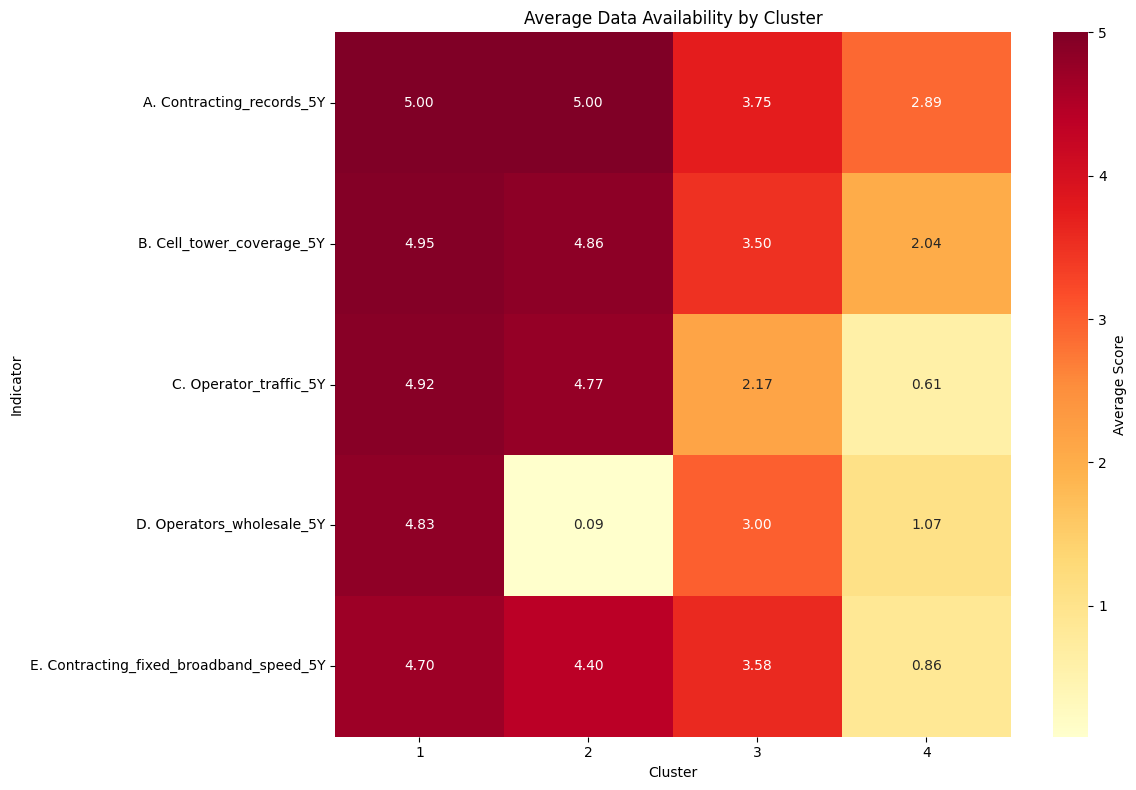

In [176]:
# Step 7: Create a heatmap to visualize cluster patterns
plt.figure(figsize=(12, 8))
cluster_means = pivoted_group.groupby('Cluster')[['A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y',
     'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y',
     'E. Contracting_fixed_broadband_speed_5Y']].mean()
sns.heatmap(
    cluster_means.T,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Average Score'}
)
plt.title('Average Data Availability by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Indicator')
plt.tight_layout()
plt.show()

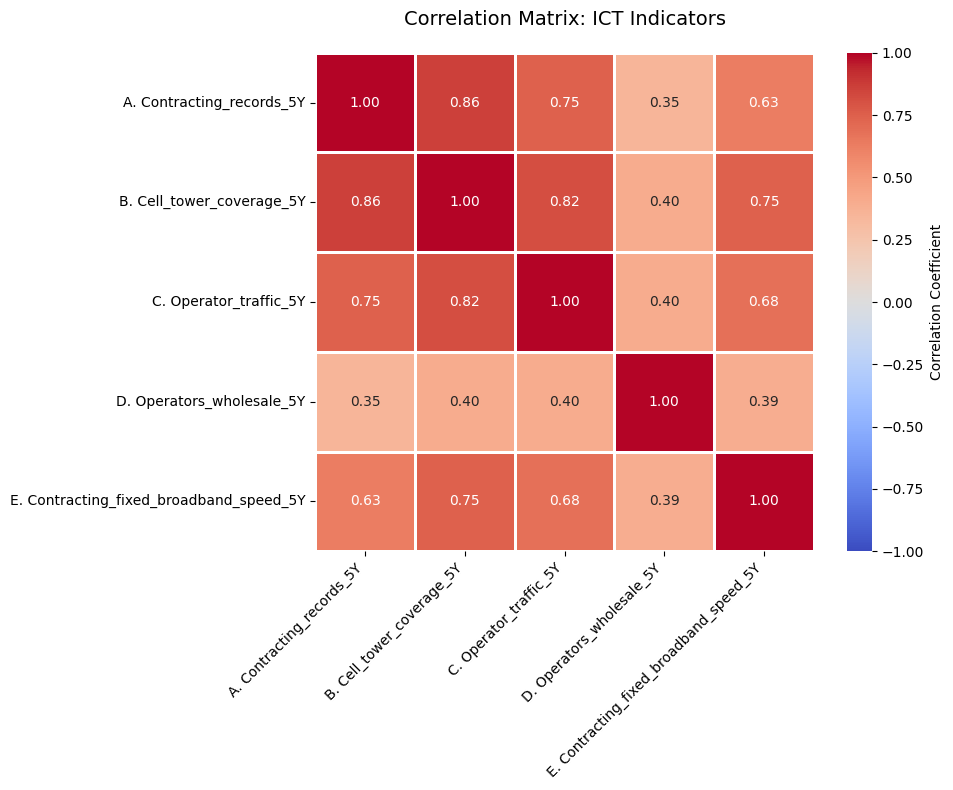

In [177]:

# Calculate correlation matrix
correlation_matrix = pivoted_group[[ 'A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y', 'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y', 'E. Contracting_fixed_broadband_speed_5Y']].corr()

# Create the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,  # Show correlation values
            fmt='.2f',   # 2 decimal places
            cmap='coolwarm',  # Blue (negative) to Red (positive)
            center=0,    # Center the colormap at 0
            square=True,  # Make cells square
            linewidths=1,
            linecolor='white',
            cbar_kws={'label': 'Correlation Coefficient'},
            vmin=-1,     # Correlations range from -1 to 1
            vmax=1)

plt.title('Correlation Matrix: ICT Indicators', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Country profile charts

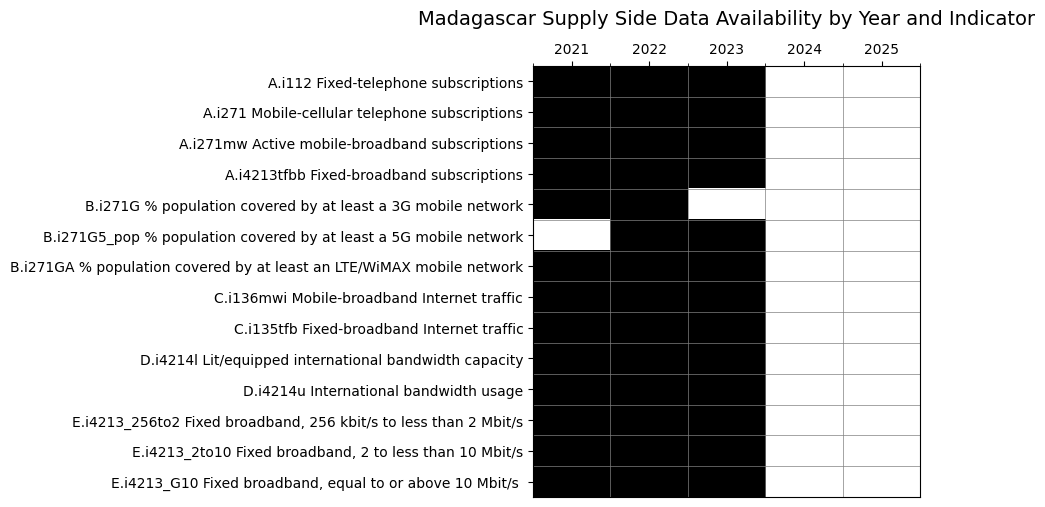

In [178]:
# prepping my data to draw a barcode plot

country_name = 'Madagascar'

years = [2021, 2022, 2023, 2024, 2025]

codes = ['i112', 'i271', 'i271mw', 'i4213tfbb', 'i271G' , 'i271G5_pop', 'i271GA', 'i136mwi',  'i135tfb','i4214l',
       'i4214u', 'i4213_256to2', 'i4213_2to10', 'i4213_G10']

new_names = ['A.i112 Fixed-telephone subscriptions', 'A.i271 Mobile-cellular telephone subscriptions',
             'A.i271mw Active mobile-broadband subscriptions', 'A.i4213tfbb Fixed-broadband subscriptions',
             'B.i271G % population covered by at least a 3G mobile network' , 'B.i271G5_pop % population covered by at least a 5G mobile network',
             'B.i271GA % population covered by at least an LTE/WiMAX mobile network',
             'C.i136mwi Mobile-broadband Internet traffic',  'C.i135tfb Fixed-broadband Internet traffic','D.i4214l Lit/equipped international bandwidth capacity',
             'D.i4214u International bandwidth usage', 'E.i4213_256to2 Fixed broadband, 256 kbit/s to less than 2 Mbit/s',
             'E.i4213_2to10 Fixed broadband, 2 to less than 10 Mbit/s', 'E.i4213_G10 Fixed broadband, equal to or above 10 Mbit/s ']

wti_country = wti[(wti.ShortName == country_name)].pivot(index='Code', columns='DataYear', values = 'ShortName').reindex(columns=years, index=codes).notna().astype(int).reset_index()

wti_country.Code=new_names

# Convert DataFrame to numpy array
code_array = wti_country.set_index( 'Code').to_numpy()

fig, ax = plt.subplots(figsize=(code_array.shape[1] * 1, code_array.shape[0] * 0.4))

# Show barcode
ax.imshow(code_array, cmap='binary', aspect='auto', interpolation='nearest')

ax.set_title(f'{country_name} Supply Side Data Availability by Year and Indicator', fontsize=14, pad=30)

# Set row labels (y-axis)
ax.set_yticks(np.arange(code_array.shape[0]))
ax.set_yticklabels(wti_country.set_index( 'Code').index)

# Set column labels (x-axis)
ax.set_xticks(np.arange(code_array.shape[1]))
ax.set_xticklabels(wti_country.set_index( 'Code').columns, rotation=0)
ax.xaxis.tick_top() # put year lables on top

# Optional: remove grid / frame
ax.set_xticks(np.arange(-.5, code_array.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, code_array.shape[0], 1), minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
ax.tick_params(which='minor', bottom=False, left=False)

plt.show()


In [179]:
year_columns = [2021, 2022, 2023, 2024, 2025]
wti_country[year_columns].sum().sum()/(14*5)*100

np.float64(57.14285714285714)

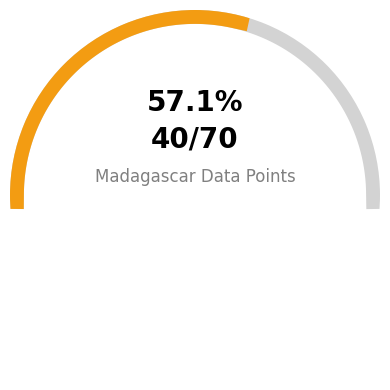

In [180]:
year_columns = [2021, 2022, 2023, 2024, 2025]

# Calculate your percentage
completeness = wti_country[year_columns].sum().sum()/(14*5)*100

# Create gauge chart
fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={'projection': 'polar'})

# Set up the gauge (semicircle)
theta = np.linspace(0, np.pi, 100)

# Background arc (gray)
ax.plot(theta, [1]*100, color='lightgray', linewidth=20)

# Colored arc based on percentage
# Define color zones
if completeness >= 75:
    color = '#2ecc71'  # Green
elif completeness >= 50:
    color = '#f39c12'  # Orange
else:
    color = '#e74c3c'  # Red

# Calculate how much of the arc to fill
theta_fill = np.linspace(0, np.pi * (completeness/100), 100)
ax.plot(theta_fill, [1]*100, color=color, linewidth=20)

# Add percentage text in center
ax.text(np.pi/2, 0.5, f'{completeness:.1f}%',
        ha='center', va='center', fontsize=20, fontweight='bold')
# Add calculation text in center
ax.text(np.pi/2, 0.3, f'{completeness*0.70:.0f}/70',
        ha='center', va='center', fontsize=20, fontweight='bold')
ax.text(np.pi/2, 0.1, f'{country_name} Data Points',
        ha='center', va='center', fontsize=12, color='gray')

# Customize appearance
ax.set_ylim(0, 1)
ax.set_theta_offset(np.pi)
ax.set_theta_direction(-1)
ax.set_xticks([])
ax.set_yticks([])
ax.spines['polar'].set_visible(False)
ax.grid(False)
plt.subplots_adjust(bottom=0.1, top=0.9)

plt.tight_layout()
plt.show()

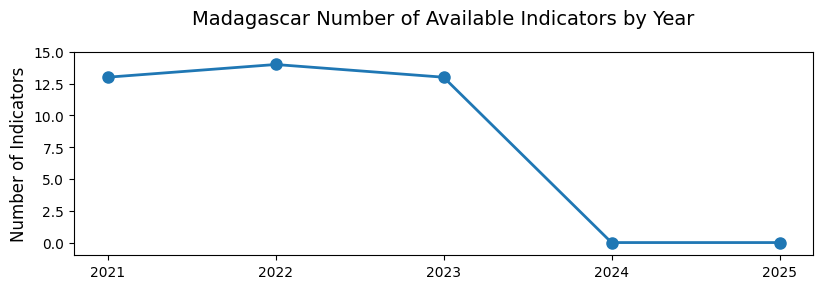

In [181]:


# Calculate sum for each year (excluding the 'Indicator' column)
year_columns = [2021, 2022, 2023, 2024, 2025]
year_sums = wti_country[year_columns].sum()

# Create line chart
plt.figure(figsize=(8.2, 3))
plt.plot(year_sums.index, year_sums.values, marker='o', linewidth=2, markersize=8)

plt.title(f'{country_name} Number of Available Indicators by Year', fontsize=14, pad=20)
# Set x-ticks to integers only
plt.xticks(year_columns)  # This ensures only your year values appear as ticks
#plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Indicators', fontsize=12)
#plt.grid(True, alpha=0.3)
plt.ylim(0, max(year_sums.values) + 1)  # Add some space at the top
plt.ylim(-1, max(year_sums.values) + 1)  # Starts at -1 instead of 0

plt.tight_layout()
plt.show()

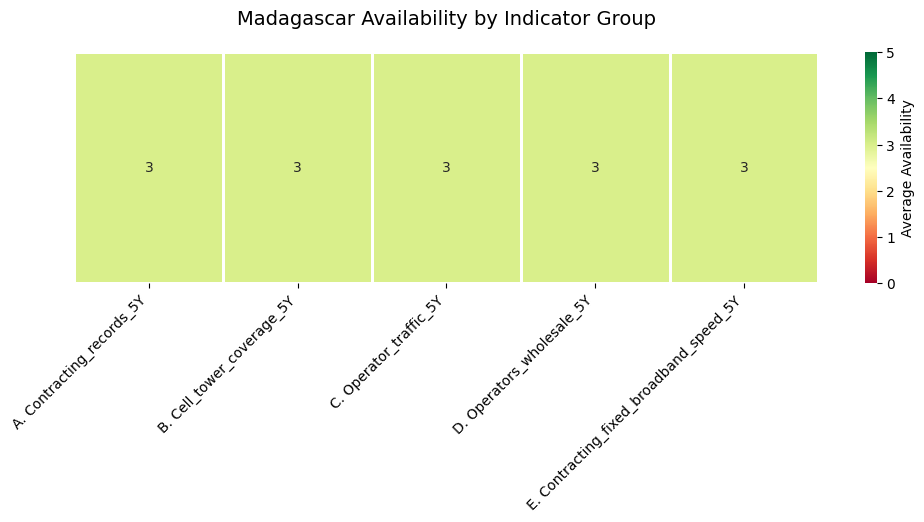

In [182]:
# Select the row for that country
country_name = 'Madagascar'
country_data = pivoted_group[pivoted_group['ShortName'] == country_name].drop('ShortName', axis=1)

plt.figure(figsize=(12, 3))
sns.heatmap(country_data[['A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y', 'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y', 'E. Contracting_fixed_broadband_speed_5Y']],
            annot=True,
            fmt='.0f',
            cmap='RdYlGn',  # Red-Yellow-Green
            cbar_kws={'label': 'Average Availability'},
            linewidths=1,
            linecolor='white',
            vmin=0,
            vmax=5)

plt.title(f'{country_name} Availability by Indicator Group', fontsize=14, pad=20)
#plt.xlabel('Indicator', fontsize=12)
#plt.ylabel('')
plt.yticks([])
plt.xticks(rotation=45, ha='right')
#plt.tight_layout()
plt.show()

And ALL IN ONE

In [183]:
# List of countries
countries = ['Madagascar', 'Sierra Leone', 'Mali']

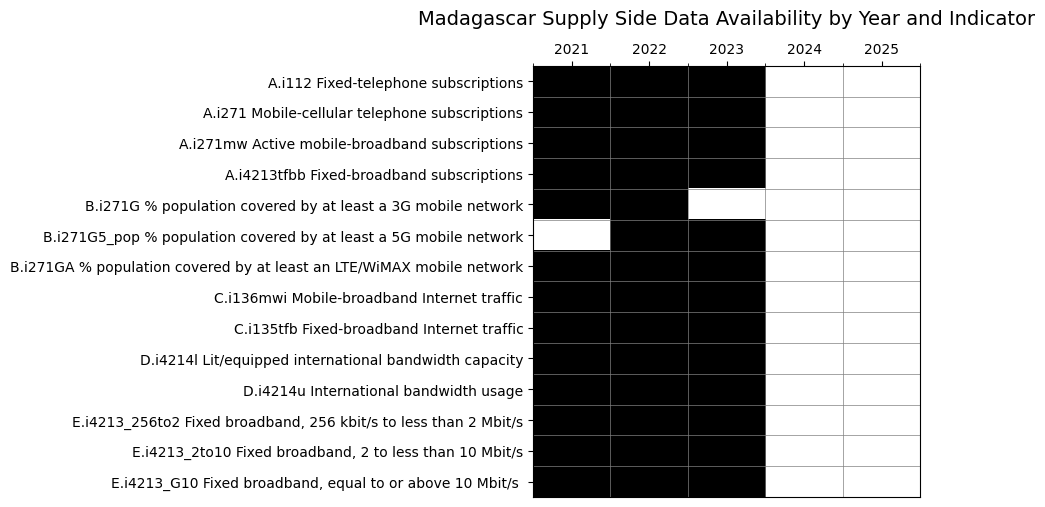

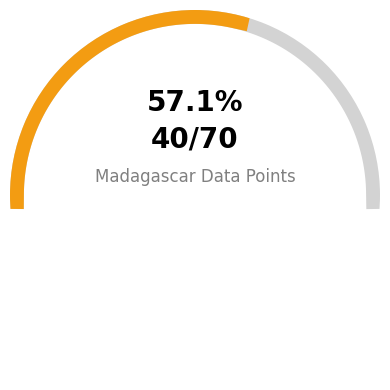

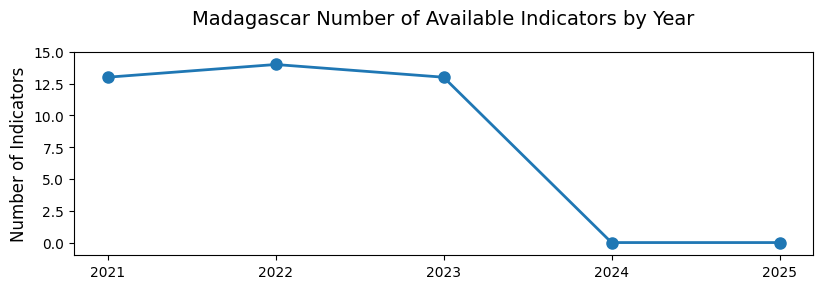

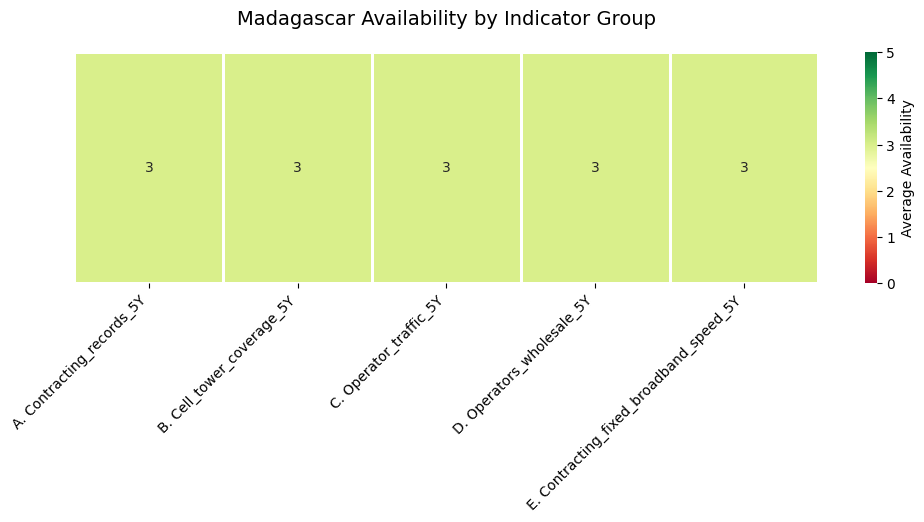

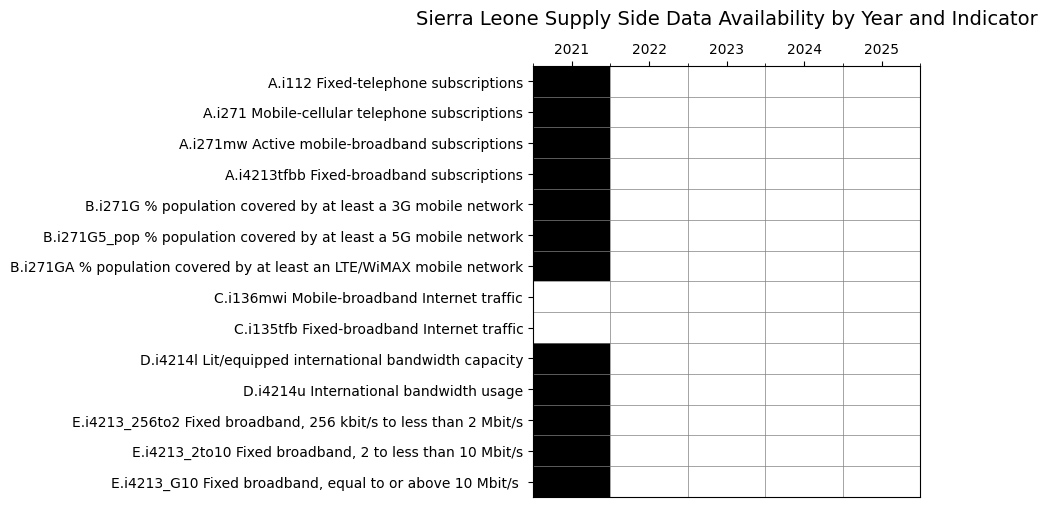

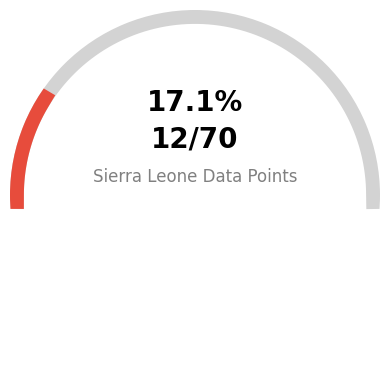

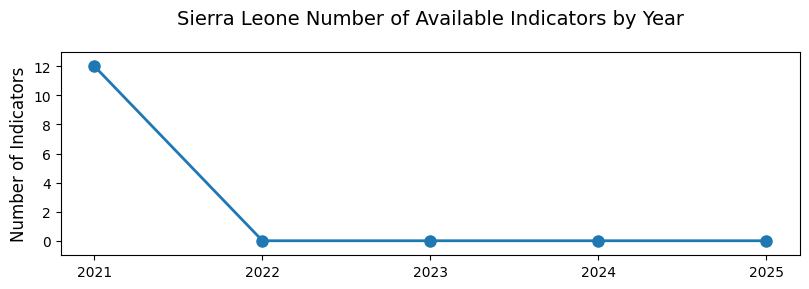

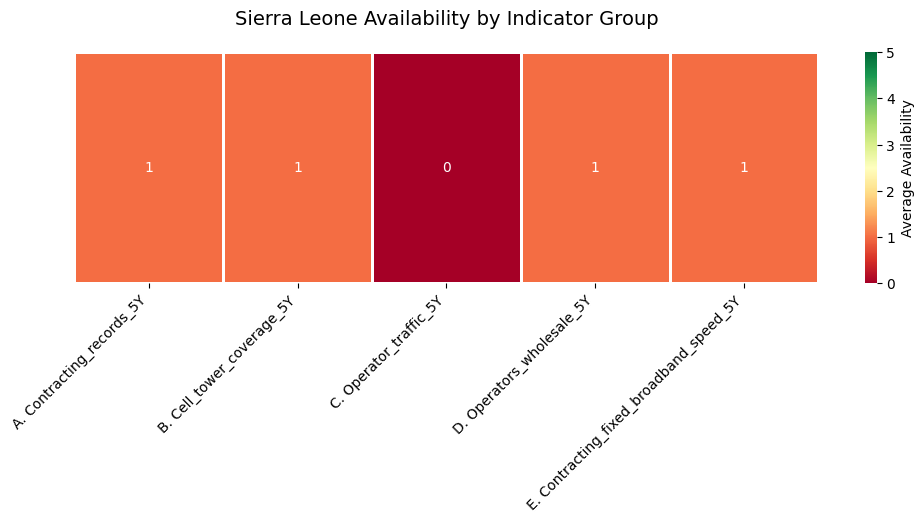

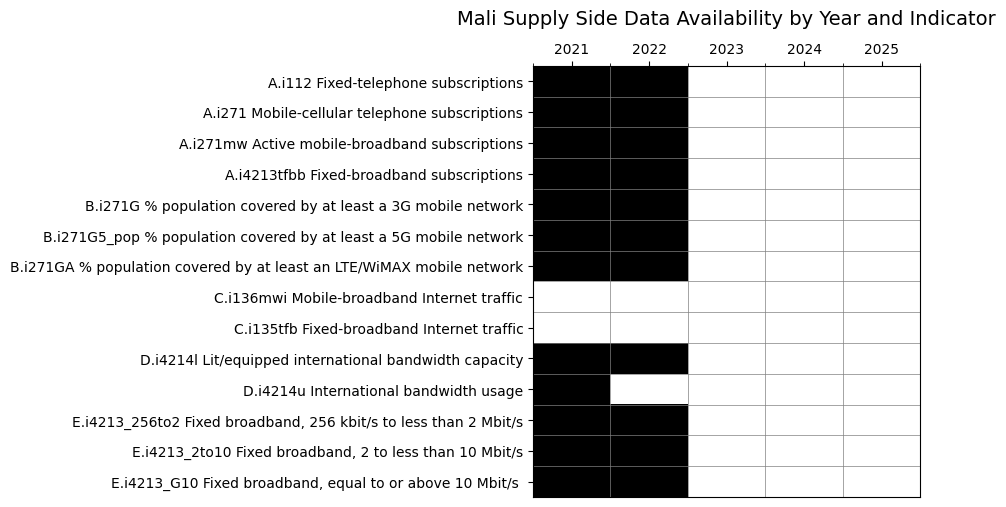

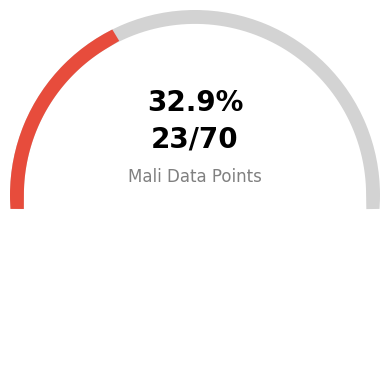

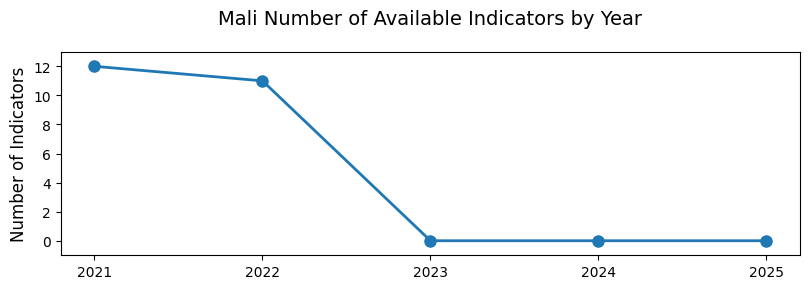

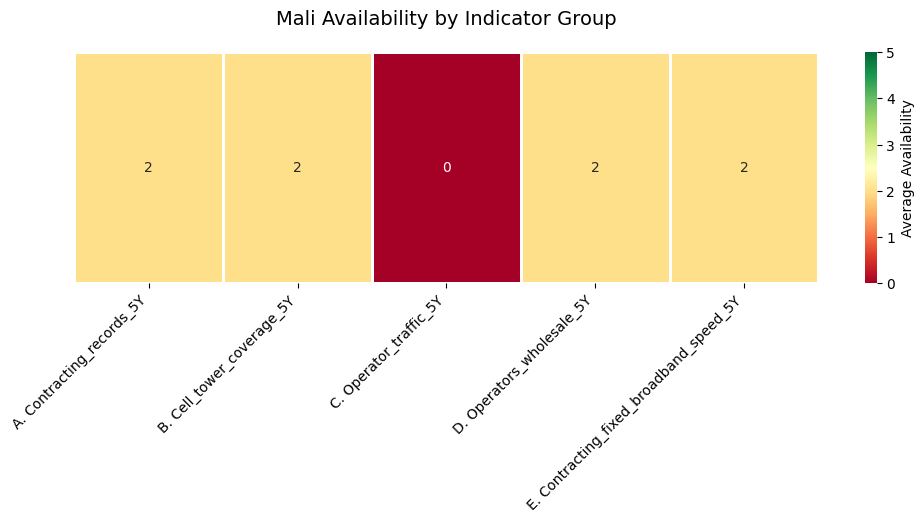

In [184]:
# Loop through each country
for country_name in countries:

    # prepping my data to draw a barcode plot


    years = [2021, 2022, 2023, 2024, 2025]

    codes = ['i112', 'i271', 'i271mw', 'i4213tfbb', 'i271G' , 'i271G5_pop', 'i271GA', 'i136mwi',  'i135tfb','i4214l',
       'i4214u', 'i4213_256to2', 'i4213_2to10', 'i4213_G10']

    new_names = ['A.i112 Fixed-telephone subscriptions', 'A.i271 Mobile-cellular telephone subscriptions',
             'A.i271mw Active mobile-broadband subscriptions', 'A.i4213tfbb Fixed-broadband subscriptions',
             'B.i271G % population covered by at least a 3G mobile network' , 'B.i271G5_pop % population covered by at least a 5G mobile network',
             'B.i271GA % population covered by at least an LTE/WiMAX mobile network',
             'C.i136mwi Mobile-broadband Internet traffic',  'C.i135tfb Fixed-broadband Internet traffic','D.i4214l Lit/equipped international bandwidth capacity',
             'D.i4214u International bandwidth usage', 'E.i4213_256to2 Fixed broadband, 256 kbit/s to less than 2 Mbit/s',
             'E.i4213_2to10 Fixed broadband, 2 to less than 10 Mbit/s', 'E.i4213_G10 Fixed broadband, equal to or above 10 Mbit/s ']

    wti_country = wti[(wti.ShortName == country_name)].pivot(index='Code', columns='DataYear', values = 'ShortName').reindex(columns=years, index=codes).notna().astype(int).reset_index()

    wti_country.Code=new_names

# Convert DataFrame to numpy array
    code_array = wti_country.set_index( 'Code').to_numpy()

    fig, ax = plt.subplots(figsize=(code_array.shape[1] * 1, code_array.shape[0] * 0.4))

# Show barcode
    ax.imshow(code_array, cmap='binary', aspect='auto', interpolation='nearest')

    ax.set_title(f'{country_name} Supply Side Data Availability by Year and Indicator', fontsize=14, pad=30)

# Set row labels (y-axis)
    ax.set_yticks(np.arange(code_array.shape[0]))
    ax.set_yticklabels(wti_country.set_index( 'Code').index)

# Set column labels (x-axis)
    ax.set_xticks(np.arange(code_array.shape[1]))
    ax.set_xticklabels(wti_country.set_index( 'Code').columns, rotation=0)
    ax.xaxis.tick_top() # put year lables on top

# Optional: remove grid / frame
    ax.set_xticks(np.arange(-.5, code_array.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, code_array.shape[0], 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    plt.show()


    ## gauge
    year_columns = [2021, 2022, 2023, 2024, 2025]

    # Calculate your percentage
    completeness = wti_country[year_columns].sum().sum()/(14*5)*100

    # Create gauge chart
    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={'projection': 'polar'})

    # Set up the gauge (semicircle)
    theta = np.linspace(0, np.pi, 100)

    # Background arc (gray)
    ax.plot(theta, [1]*100, color='lightgray', linewidth=20)

    # Colored arc based on percentage
    # Define color zones
    if completeness >= 75:
        color = '#2ecc71'  # Green
    elif completeness >= 50:
        color = '#f39c12'  # Orange
    else:
        color = '#e74c3c'  # Red

    # Calculate how much of the arc to fill
    theta_fill = np.linspace(0, np.pi * (completeness/100), 100)
    ax.plot(theta_fill, [1]*100, color=color, linewidth=20)

    # Add percentage text in center
    ax.text(np.pi/2, 0.5, f'{completeness:.1f}%',
        ha='center', va='center', fontsize=20, fontweight='bold')
    # Add calculation text in center
    ax.text(np.pi/2, 0.3, f'{completeness*0.70:.0f}/70',
        ha='center', va='center', fontsize=20, fontweight='bold')
    ax.text(np.pi/2, 0.1, f'{country_name} Data Points',
        ha='center', va='center', fontsize=12, color='gray')

    # Customize appearance
    ax.set_ylim(0, 1)
    ax.set_theta_offset(np.pi)
    ax.set_theta_direction(-1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['polar'].set_visible(False)
    ax.grid(False)
    plt.subplots_adjust(bottom=0.1, top=0.9)

    plt.tight_layout()
    plt.show()


    ## line chart


    # Calculate sum for each year (excluding the 'Indicator' column)
    year_sums = wti_country[year_columns].sum()

    # Create line chart
    plt.figure(figsize=(8.2, 3))
    plt.plot(year_sums.index, year_sums.values, marker='o', linewidth=2, markersize=8)

    plt.title(f'{country_name} Number of Available Indicators by Year', fontsize=14, pad=20)
    # Set x-ticks to integers only
    plt.xticks(year_columns)  # This ensures only your year values appear as ticks
    #plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of Indicators', fontsize=12)
    #plt.grid(True, alpha=0.3)
    plt.ylim(0, max(year_sums.values) + 1)  # Add some space at the top
    plt.ylim(-1, max(year_sums.values) + 1)  # Starts at -1 instead of 0

    plt.tight_layout()
    plt.show()

    # Heatmap for the indicator group
    country_data = pivoted_group[pivoted_group['ShortName'] == country_name].drop('ShortName', axis=1)

    plt.figure(figsize=(12, 3))
    sns.heatmap(country_data[['A. Contracting_records_5Y', 'B. Cell_tower_coverage_5Y', 'C. Operator_traffic_5Y', 'D. Operators_wholesale_5Y', 'E. Contracting_fixed_broadband_speed_5Y']],
            annot=True,
            fmt='.0f',
            cmap='RdYlGn',  # Red-Yellow-Green
            cbar_kws={'label': 'Average Availability'},
            linewidths=1,
            linecolor='white',
            vmin=0,
            vmax=5)

    plt.title(f'{country_name} Availability by Indicator Group', fontsize=14, pad=20)
    #plt.xlabel('Indicator', fontsize=12)
    #plt.ylabel('')
    plt.yticks([])
    plt.xticks(rotation=45, ha='right')
    #plt.tight_layout()
    plt.show()
